# Clinical lab data analysis of ALTRA
- related to Figure S5B

# Setup

In [1]:
quiet_library <- function(...) {
    suppressPackageStartupMessages(library(...))
}
quiet_library('Seurat')
quiet_library('tidyverse')
quiet_library('ggplot2')
quiet_library('dplyr')
quiet_library('rstatix')
quiet_library('viridis')
quiet_library('lmerTest')
quiet_library('broom.mixed')

Warning message:
“package ‘dplyr’ was built under R version 4.3.3”


In [2]:
# define file path
# define working path
data_path = '/home/jupyter/github/ra-longitudinal/metadata'
fig_path = '/home/jupyter/data/ra_longitudinal/figures/labs'
meta_path = '/home/jupyter/github/ra-longitudinal/metadata'
output_path = '/home/jupyter/data/ra_longitudinal/output_results/labs'

if(!dir.exists(fig_path)) (dir.create(fig_path, recursive = TRUE))
if(!dir.exists(output_path)) (dir.create(output_path, recursive = TRUE))


In [3]:
# define the color palette to be used
npg_color <- c("#E64B35FF", "#4DBBD5FF", "#00A087FF", "#3C5488FF", "#F39B7FFF", 
               "#8491B4FF", "#91D1C2FF", "#DC0000FF", "#7E6148FF", "#B09C85FF")
nejm_color <- c("#BC3C29FF", "#0072B5FF", "#E18727FF", "#20854EFF", "#7876B1FF", "#6F99ADFF", "#FFDC91FF", "#EE4C97FF")
jama_color <- c("#374E55FF", "#DF8F44FF", "#00A1D5FF", "#B24745FF", "#79AF97FF", "#6A6599FF", "#80796BFF")
jco_color <- c("#0073C2FF", "#EFC000FF", "#868686FF", "#CD534CFF", "#7AA6DCFF", "#003C67FF", "#8F7700FF")
cluster_colors <- c("#DC050C", "#FB8072", "#1965B0", "#7BAFDE", "#882E72", "#B17BA6", "#FF7F00", "#FDB462", "#E7298A", 
    "#E78AC3", "#33A02C", "#B2DF8A", "#55A1B1", "#8DD3C7", "#A6761D", "#E6AB02", "#7570B3", "#BEAED4", "#666666", "#999999", 
    "#aa8282", "#d4b7b7", "#8600bf", "#ba5ce3", "#808000", "#aeae5c", "#1e90ff", "#00bfff", "#56ff0d", "#ffff00")
cluster_colors_ext <- colorRampPalette(cluster_colors)(36)
options(repr.plot.width = 20, repr.plot.height = 15)

In [4]:
source('/home/workspace/github/ALTRA-manuscript/Analysis/scRNA/ALTRA_scRNA_R_helper_functions.r')

# Clinical lab data analysis 

In [14]:
# load lab data
lab_data = read_csv(file.path(data_path, '2023-11-22_ALTRA_Metadata_labs.csv'), 
                   show_col_types = FALSE)
lab_data <- lab_data %>%mutate(
    status=case_when(Status_Long=='pre' ~ 'pre-converion',
                    Status_Long=='conversion' ~ 'conversion', 
                     Status_Xsec == 'at_risk' & is.na(Status_Long) ~ 'at-risk_nonconvert',              
                    TRUE ~ Status_Xsec),
    rfigm_result=if_else(rfigm_result==999, NA, rfigm_result))
lab_data%>%head()
lab_data%>%distinct(Status_Xsec, Status_Long, status)

New names:
• `record_id...112` -> `record_id...128`
• `record_id...120` -> `record_id...136`
• `record_id...114` -> `record_id...140`
• `record_id...123` -> `record_id...141`


Status_Xsec,Status_Long,sample.sampleKitGuid,sample.visitName,sample.visitDetails,sample.drawDate,sample.daysSinceFirstVisit,subject.subjectGuid,subject.biologicalSex,subject.birthYear,⋯,record_id...140,record_id...141,BMI,CMV_Status_Subj,CMV_Value_Subj,anti_ccp3_finalCombined,days_to_conversion,age_conv,bmi_conv,status
<chr>,<chr>,<chr>,<chr>,<chr>,<date>,<dbl>,<chr>,<chr>,<dbl>,⋯,<lgl>,<lgl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
at_risk,pre,KT00052,Flu Year 1 Stand-Alone,N/A - Flu-Series Timepoint Only,2019-11-01,0,CU1009,Female,1963,⋯,NA,NA,24.65716,Negative,0.081,88,-714,58,25.64892,pre-converion
early_RA,NA,KT00055,Flu Year 1 Day 0,N/A - Flu-Series Timepoint Only,2019-11-01,0,CU1008,Female,1966,⋯,NA,NA,43.24286,Positive,1.974,23,NA,NA,NA,early_RA
at_risk,pre,KT00056,Flu Year 1 Day 0,N/A - Flu-Series Timepoint Only,2019-11-01,0,CU1007,Female,1977,⋯,NA,NA,25.94834,Negative,0.145,2544,-632,44,26.19498,pre-converion
at_risk,pre,KT00057,Flu Year 1 Day 0,N/A - Flu-Series Timepoint Only,2019-10-01,0,CU1003,Female,1998,⋯,NA,NA,21.12653,Positive,3.171,262,-615,23,23.14306,pre-converion
at_risk,NA,KT00058,Flu Year 1 Day 0,N/A - Flu-Series Timepoint Only,2019-10-01,0,CU1002,Female,1941,⋯,NA,NA,27.67950,Positive,2.852,22,NA,NA,NA,at-risk_nonconvert
at_risk,NA,KT00060,Flu Year 1 Day 0,N/A - Flu-Series Timepoint Only,2019-11-01,0,CU1005,Female,1979,⋯,NA,NA,31.80398,Negative,0.061,195,NA,NA,NA,at-risk_nonconvert


Status_Xsec,Status_Long,status
<chr>,<chr>,<chr>
at_risk,pre,pre-converion
early_RA,NA,early_RA
at_risk,NA,at-risk_nonconvert
NA,pre,pre-converion
early_RA,conversion,conversion
ALTRA_healthy,NA,ALTRA_healthy
early_RA,pre,pre-converion


In [15]:
# calcualte the averagtion duration in the study for the longitudinal subjects
long_duration = lab_data%>%filter(!is.na(Status_Long))%>%group_by(subject.subjectGuid)%>%
    #filter(days_to_conversion> (-750))%>%
    summarise(study_duration = max(days_to_conversion)-min(days_to_conversion), 
             Sex = unique(subject.biologicalSex))
long_duration$study_duration%>%summary()
long_duration%>%filter(Sex=='Female')%>%pull(study_duration)%>%summary()

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  106.0   257.5   591.5   530.5   714.8  1144.0 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  163.0   264.0   614.0   543.5   714.0  1144.0 

In [16]:
# comparing the first and last visit
first_last_long = lab_data%>%filter(!is.na(Status_Long))%>%group_by(subject.subjectGuid)%>%
    filter(days_to_conversion==min(days_to_conversion)|days_to_conversion==max(days_to_conversion))%>%
    mutate(timpoint = if_else(days_to_conversion==min(days_to_conversion), 'first', 'last'))
first_last_long%>%group_by(timpoint)%>%tally()

timpoint,n
<chr>,<int>
first,16
last,16


In [17]:
first_last_long%>%colnames()%>%str_subset('age|ccp|BMI|crp')

[1] "ageAtDraw"                                 
 [2] "anti_ccp3"                                 
 [3] "anti_ccp31"                                
 [4] "c_reactive_protein_crp"                    
 [5] "serum_ccp3_finallevel"                     
 [6] "c_reactive_protein_high_sensitivity_hs_crp"
 [7] "ccp3_interpretation"                       
 [8] "ccp31_interpretation"                      
 [9] "BMI"                                       
[10] "anti_ccp3_finalCombined"                   
[11] "age_conv"

In [18]:
lab_data%>%group_by(status)%>%tally()

status,n
<chr>,<int>
ALTRA_healthy,38
at-risk_nonconvert,31
conversion,14
early_RA,13
pre-converion,61


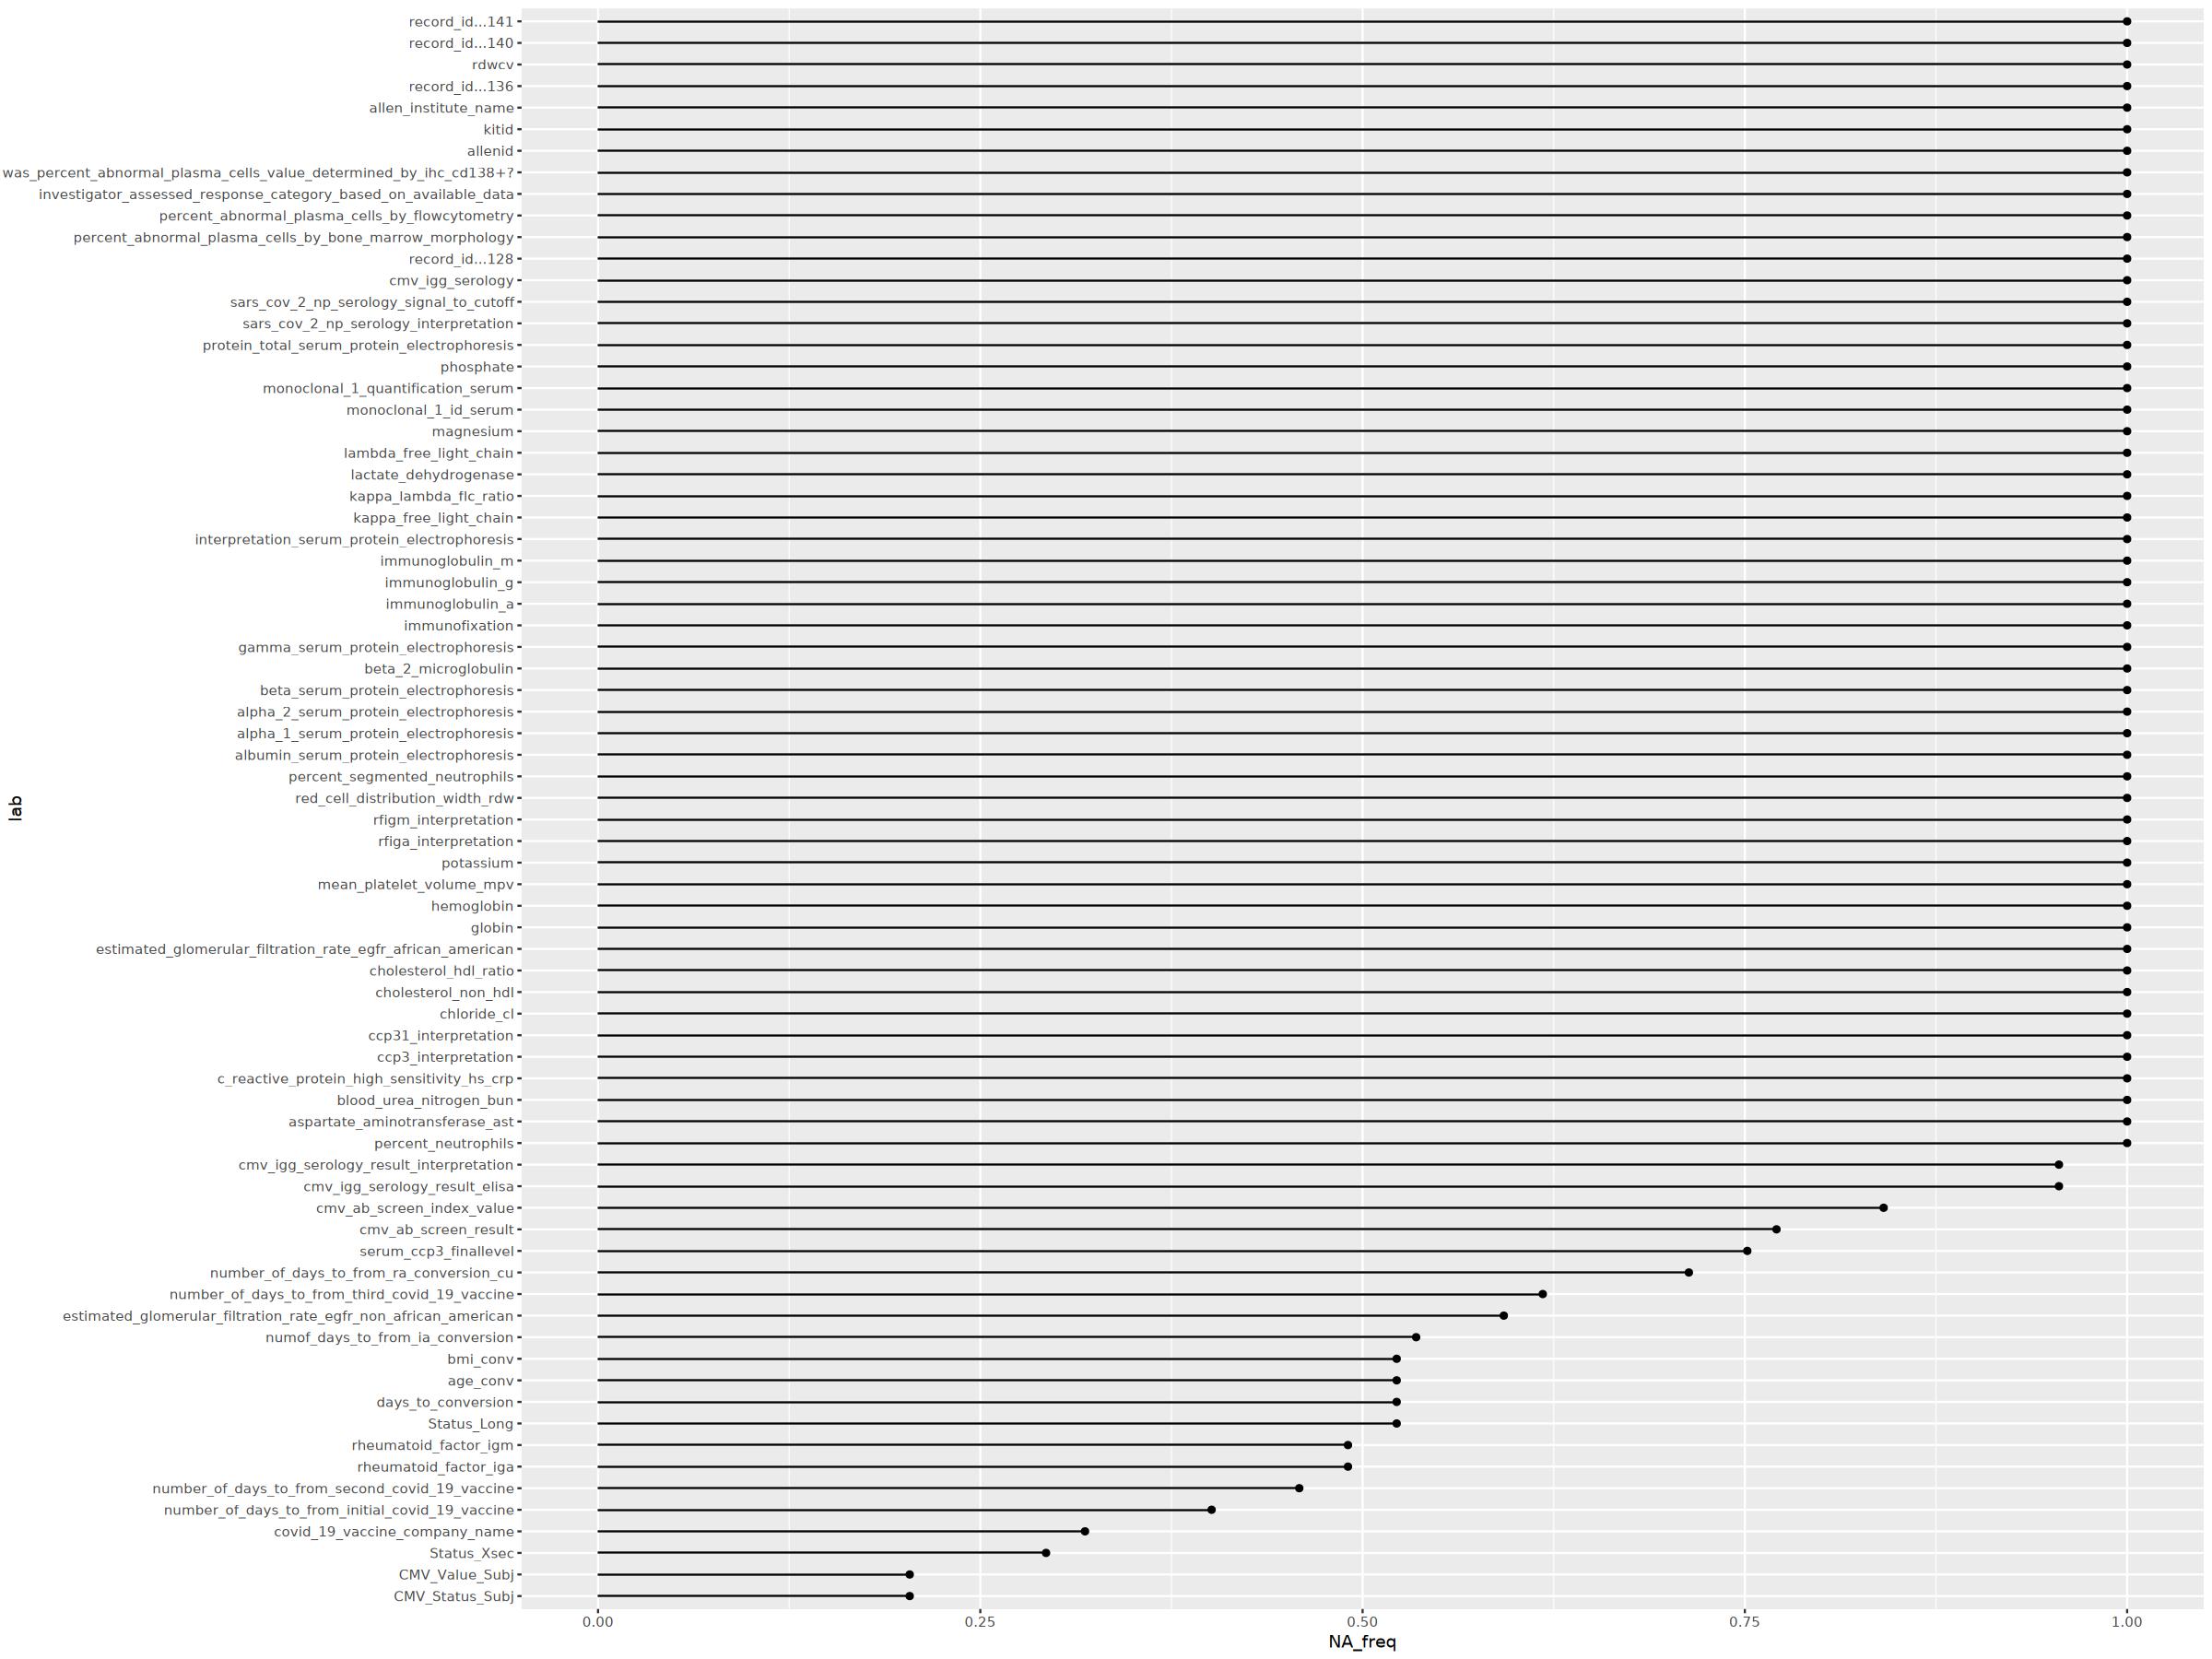

In [23]:
# check the na values
na_count <-sapply(lab_data, function(y) sum(length(which(is.na(y)))))%>%sort()
na_freq = tibble('lab'=names(na_count), 'NA_freq'=na_count/nrow(lab_data))%>%
    arrange(desc(NA_freq))%>%mutate(lab=factor(lab, levels = c(names(na_count))))
na_freq%>% filter(NA_freq>0.2)%>%ggplot(aes(x=lab, y=NA_freq))+geom_point() + 
  geom_segment( aes(x=lab, xend=lab, y=0, yend=NA_freq)) + coord_flip()
ggsave(file.path(fig_path, 'ALTRA_clinical_lab_NA.png'), width=8, height=6)

In [24]:
lab_data%>%glimpse()

Rows: 157
Columns: 149
$ Status_Xsec                                                         <chr> "a…
$ Status_Long                                                         <chr> "p…
$ sample.sampleKitGuid                                                <chr> "K…
$ sample.visitName                                                    <chr> "F…
$ sample.visitDetails                                                 <chr> "N…
$ sample.drawDate                                                     <date> 2…
$ sample.daysSinceFirstVisit                                          <dbl> 0,…
$ subject.subjectGuid                                                 <chr> "C…
$ subject.biologicalSex                                               <chr> "F…
$ subject.birthYear                                                   <dbl> 19…
$ subject.ethnicity                                                   <chr> "N…
$ subject.race                                                        <chr> "C…
$ cohort.cohortGu

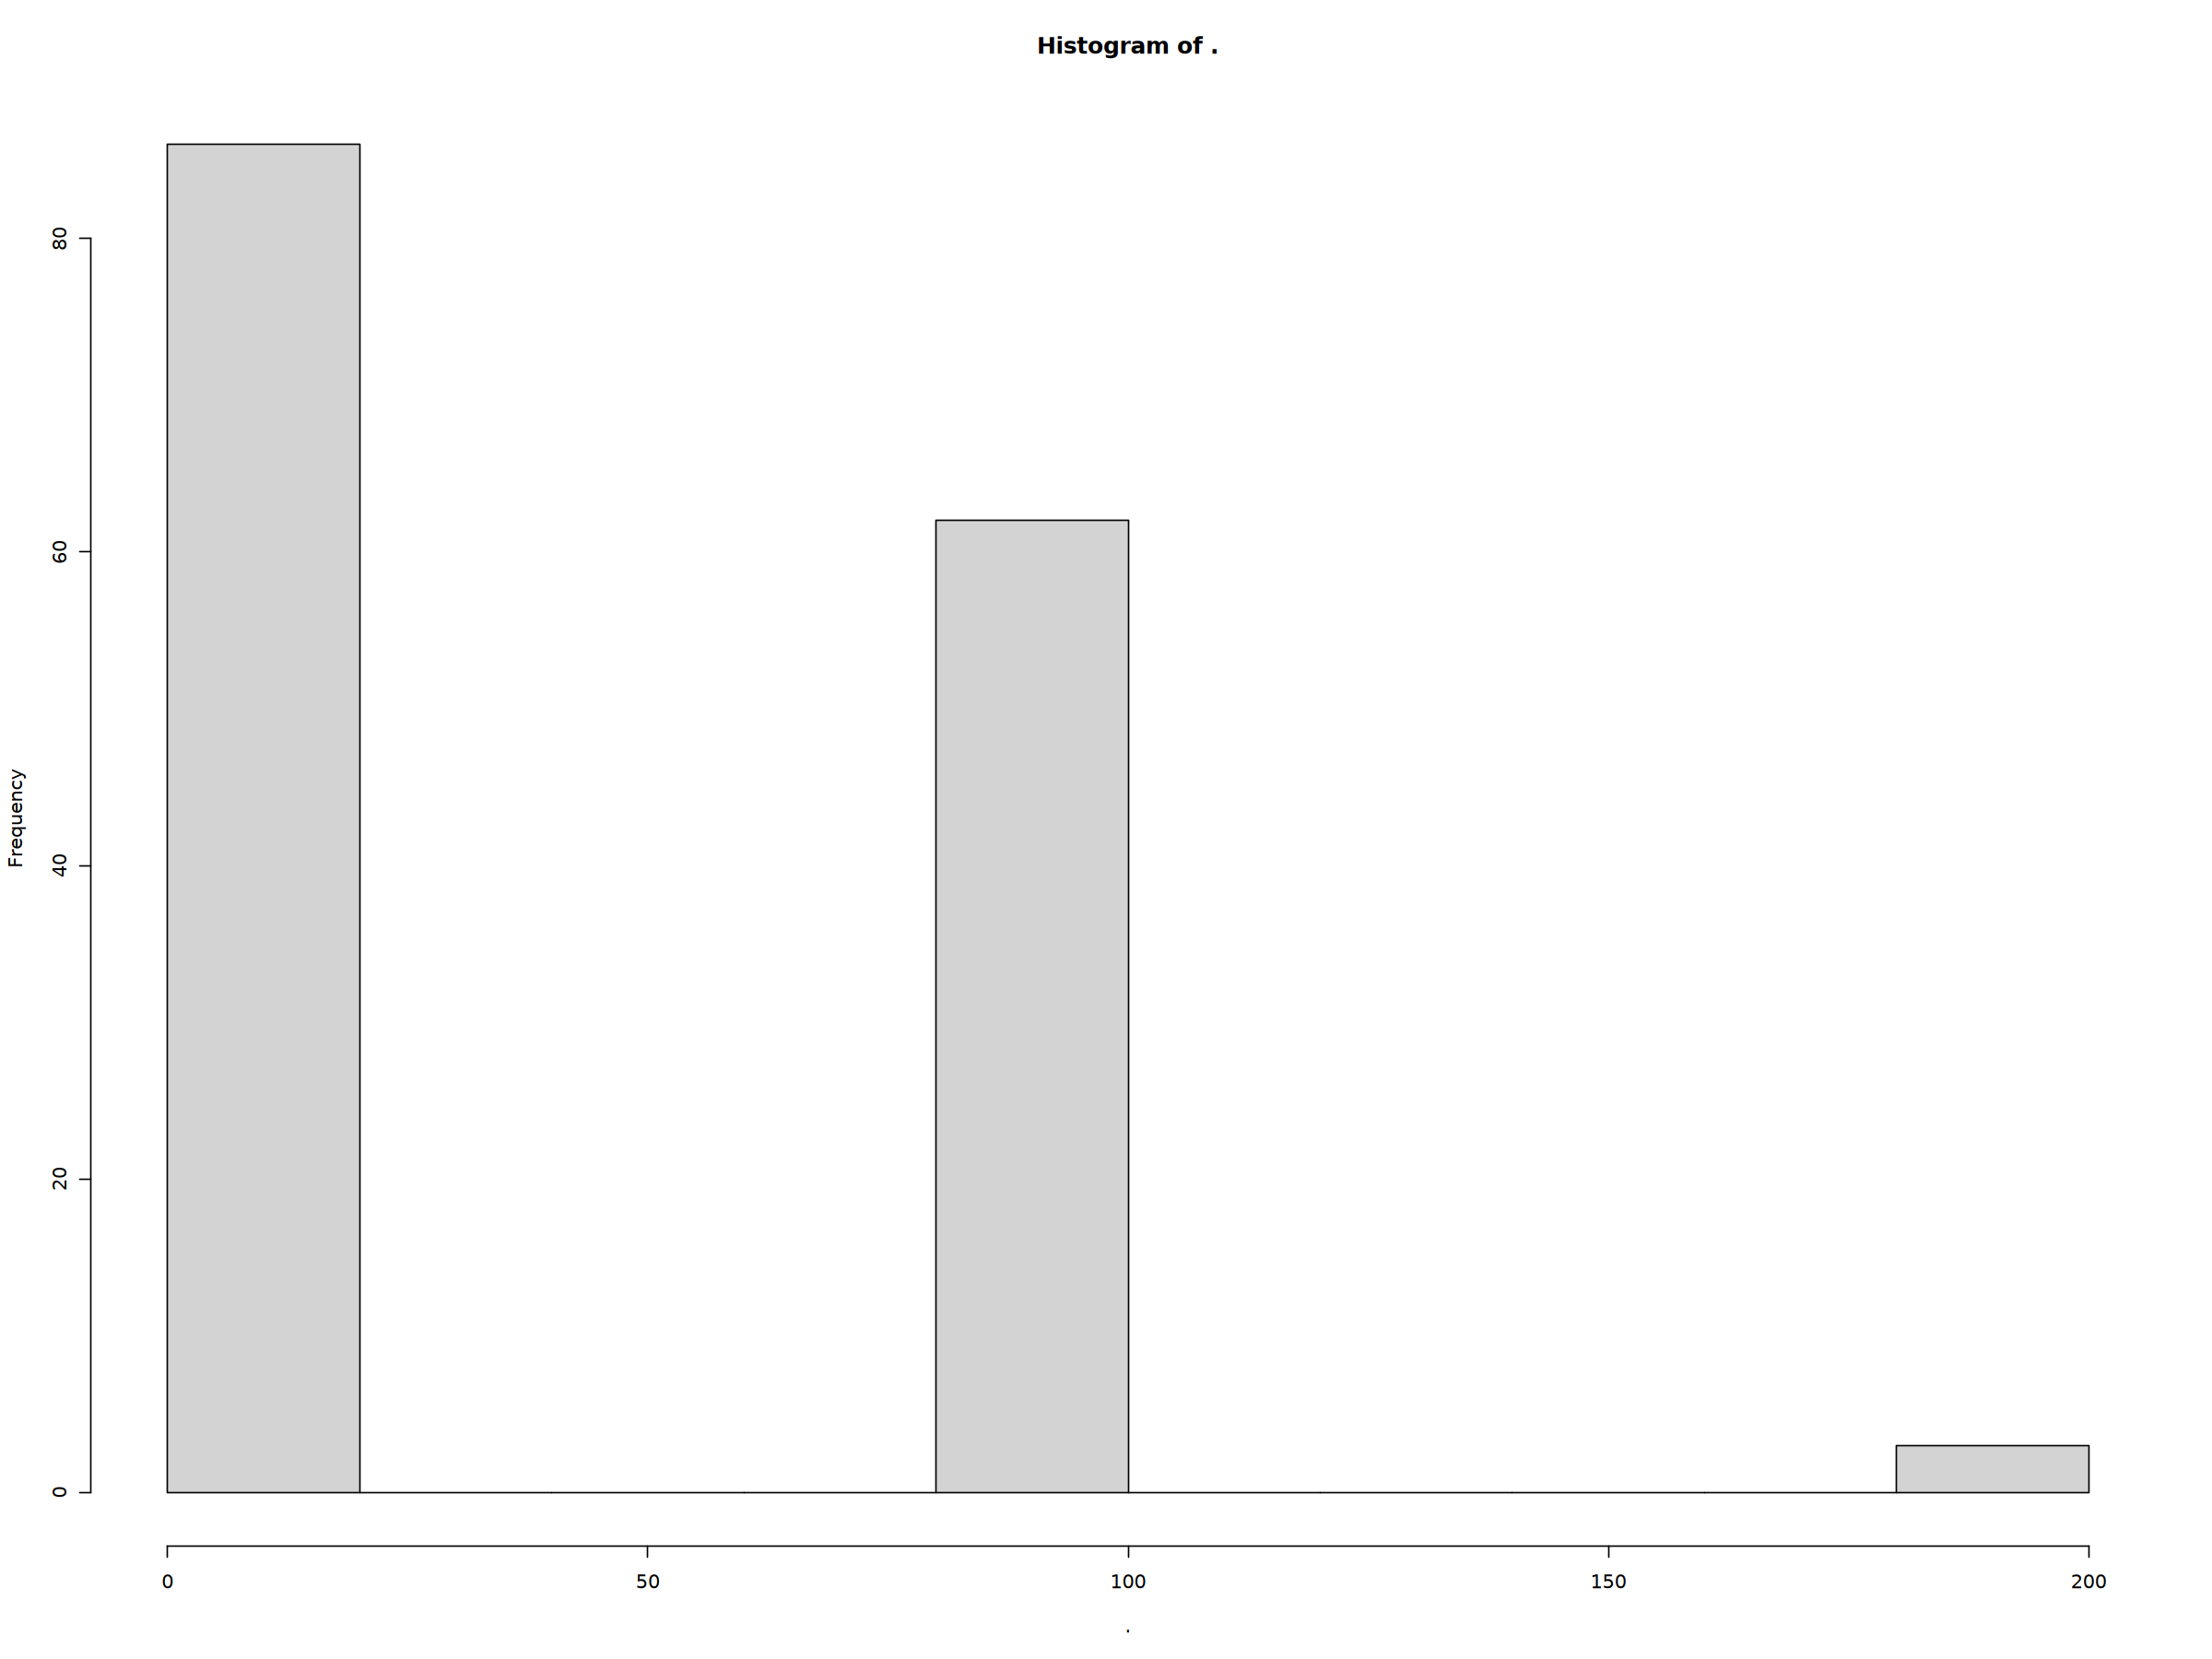

In [25]:
lab_data$absolute_basophil_count%>%hist()

In [26]:
lab_data%>%group_by(status,shared_epitope)%>%tally()

status,shared_epitope,n
<chr>,<chr>,<int>
ALTRA_healthy,Neg,21
ALTRA_healthy,Pos,13
ALTRA_healthy,NA,4
at-risk_nonconvert,Neg,18
at-risk_nonconvert,Pos,13
conversion,Neg,6
conversion,Pos,6
conversion,NA,2
early_RA,Neg,6


In [27]:
# check non-number columns
lab_data%>%select_if(~sum(!is.na(.)) > 0) %>%select(!is.numeric)%>%colnames()

Warning message:
“Use of bare predicate functions was deprecated in tidyselect 1.1.0.
ℹ Please use wrap predicates in `where()` instead.
  # Was:
  data %>% select(is.numeric)

  # Now:
  data %>% select(where(is.numeric))”


[1] "Status_Xsec"                           
 [2] "Status_Long"                           
 [3] "sample.sampleKitGuid"                  
 [4] "sample.visitName"                      
 [5] "sample.visitDetails"                   
 [6] "sample.drawDate"                       
 [7] "subject.subjectGuid"                   
 [8] "subject.biologicalSex"                 
 [9] "subject.ethnicity"                     
[10] "subject.race"                          
[11] "cohort.cohortGuid"                     
[12] "timeOnStudyAsOf"                       
[13] "converted_to_ia_during_course_of_study"
[14] "converted_to_ra_during_study"          
[15] "covid_19_vaccine_company_name"         
[16] "covid_19_vaccine_ever_received"        
[17] "has_the_patient_been_fasting?"         
[18] "shared_epitope"                        
[19] "sputum_collected?"                     
[20] "stool_collection_kit_given?"           
[21] "cmv_igg_serology_result_interpretation"
[22] "cmv_ab_screen_result"                  
[23] "CMV_Status_Subj"                       
[24] "status"

Warning message:
“package ‘GGally’ was built under R version 4.3.3”
Registered S3 method overwritten by 'GGally':
  method from   
  +.gg   ggplot2

Warning message in ggcorr(lab_values, method = c("pairwise", "spearman"), label = TRUE, :
“data in column(s) 'status' are not numeric and were ignored”


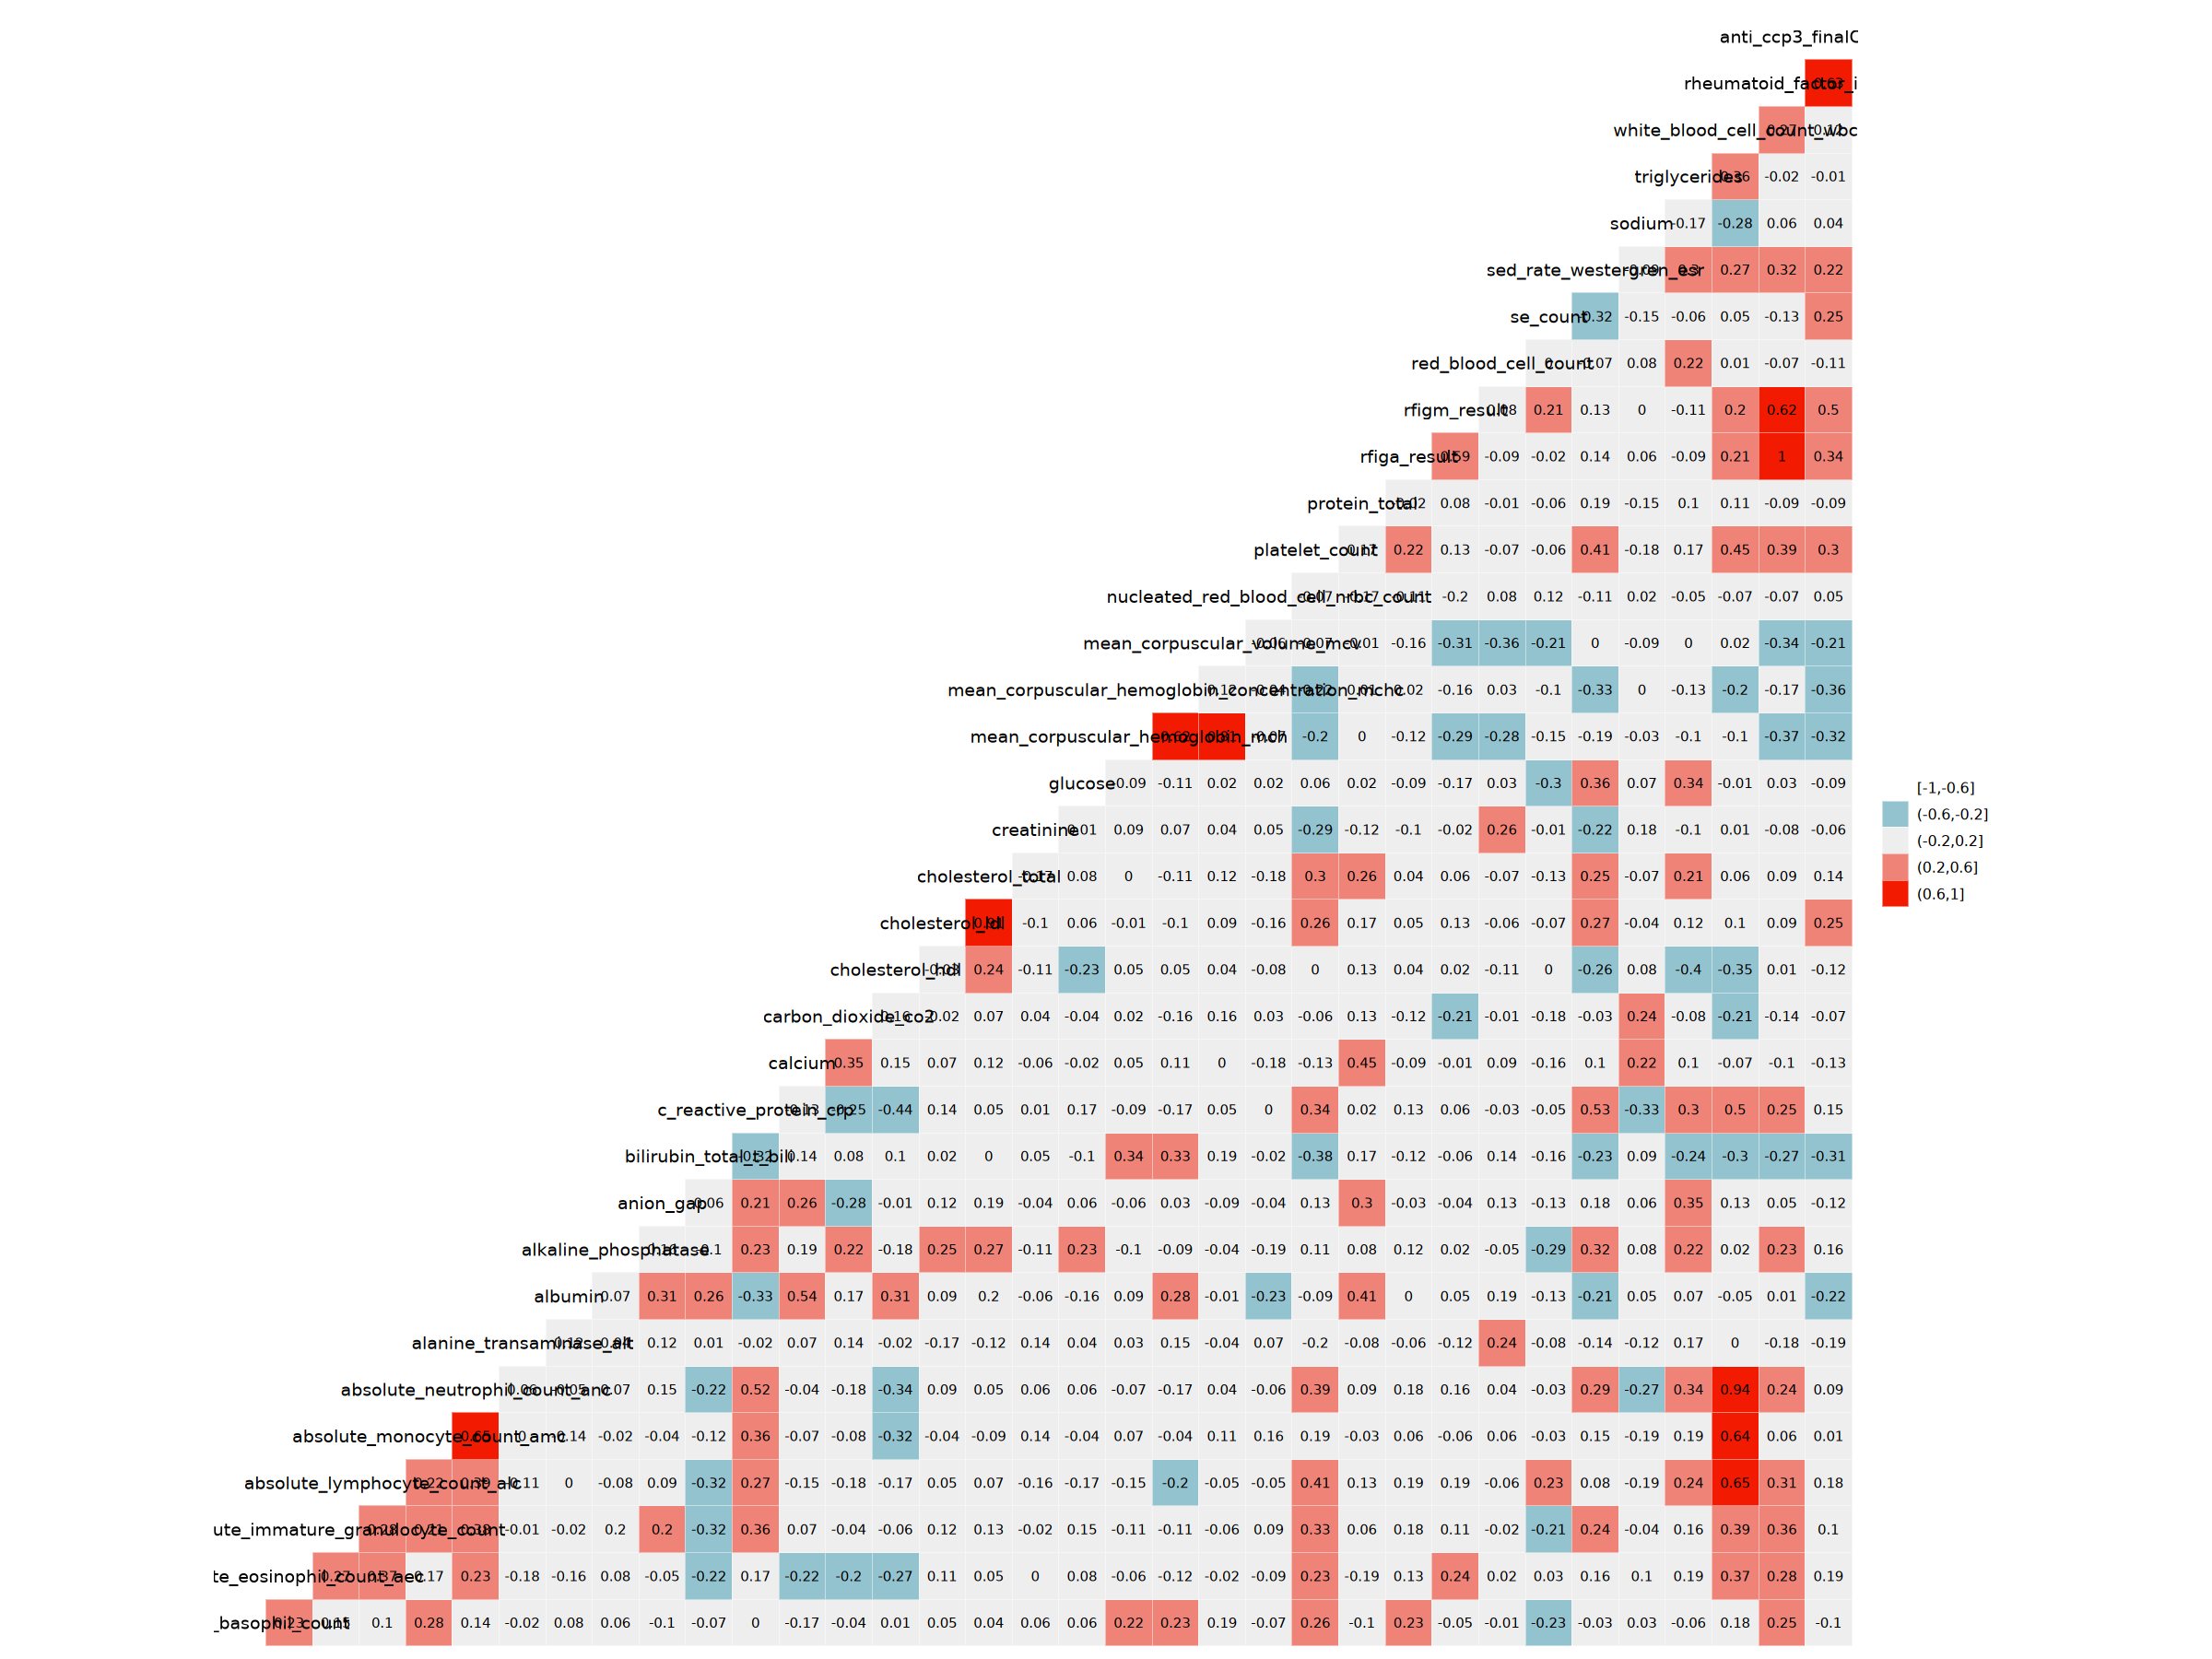

In [28]:
# select lab to test
lab_to_test = c('absolute_basophil_count','absolute_eosinophil_count_aec',
                'absolute_immature_granulocyte_count','absolute_lymphocyte_count_alc',
                'absolute_monocyte_count_amc','absolute_neutrophil_count_anc','alanine_transaminase_alt',
                'albumin','alkaline_phosphatase','anion_gap','bilirubin_total_t_bili',
                'c_reactive_protein_crp','calcium','carbon_dioxide_co2','cholesterol_hdl',
                'cholesterol_ldl','cholesterol_total','creatinine','glucose','mean_corpuscular_hemoglobin_mch',
                'mean_corpuscular_hemoglobin_concentration_mchc','mean_corpuscular_volume_mcv','nucleated_red_blood_cell_nrbc_count',
                'platelet_count','protein_total','rfiga_result','rfigm_result','red_blood_cell_count','se_count',
                'sed_rate_westergren_esr','sodium','triglycerides','white_blood_cell_count_wbc','rheumatoid_factor_iga',
                'anti_ccp3_finalCombined')
# select lab to remove
lab_remove = c('anti_ccp3','anti_ccp31','sample.daysSinceFirstVisit','0401_count','0404_count',
               '0405_count','0408_count', 'subject.birthYear',
               'Age2023','ageAtDraw','timeOnStudy', 'days_to_conversion','age_conv','bmi_conv', 
               'number_of_days_to_from_initial_covid_19_vaccine',
               'number_of_days_to_from_second_covid_19_vaccine', 'waist_size','weight',
               'number_of_days_to_from_third_covid_19_vaccine', 'numof_days_to_from_ia_conversion',
               'number_of_days_to_from_ra_conversion_cu','serum_ccp3_finallevel','cmv_igg_serology_result_elisa', 
              'cmv_ab_screen_index_value', 'status')
lab_values = lab_data %>% select(where(is.numeric))%>%
    select(all_of(lab_to_test))%>%mutate(status=lab_data$status)

library(GGally)
ggcorr(lab_values,#%>%filter(status!='ALTRA_healthy'), 
       method = c("pairwise", "spearman"),label = TRUE,
       label_size = 3, label_round = 2, nbreaks = 5) 

In [29]:
lab_values%>%filter(rfigm_result>600)%>%select(rfigm_result)

rfigm_result
<dbl>


Warning message:
“Removed 4 rows containing non-finite values (`stat_density()`).”
Warning message in ggally_statistic(data = data, mapping = mapping, na.rm = na.rm, :
“Removed 5 rows containing missing values”
Warning message in cor.test.default(x, y, method = method, use = use):
“Cannot compute exact p-value with ties”
Warning message in ggally_statistic(data = data, mapping = mapping, na.rm = na.rm, :
“Removed 5 rows containing missing values”
Warning message in cor.test.default(x, y, method = method, use = use):
“Cannot compute exact p-value with ties”
Warning message in ggally_statistic(data = data, mapping = mapping, na.rm = na.rm, :
“Removed 6 rows containing missing values”
Warning message in cor.test.default(x, y, method = method, use = use):
“Cannot compute exact p-value with ties”
Warning message:
“Removed 4 rows containing non-finite values (`stat_boxplot()`).”
Warning message:
“Removed 5 rows containing missing values (`geom_point()`).”
Warning message:
“Removed 2 rows con

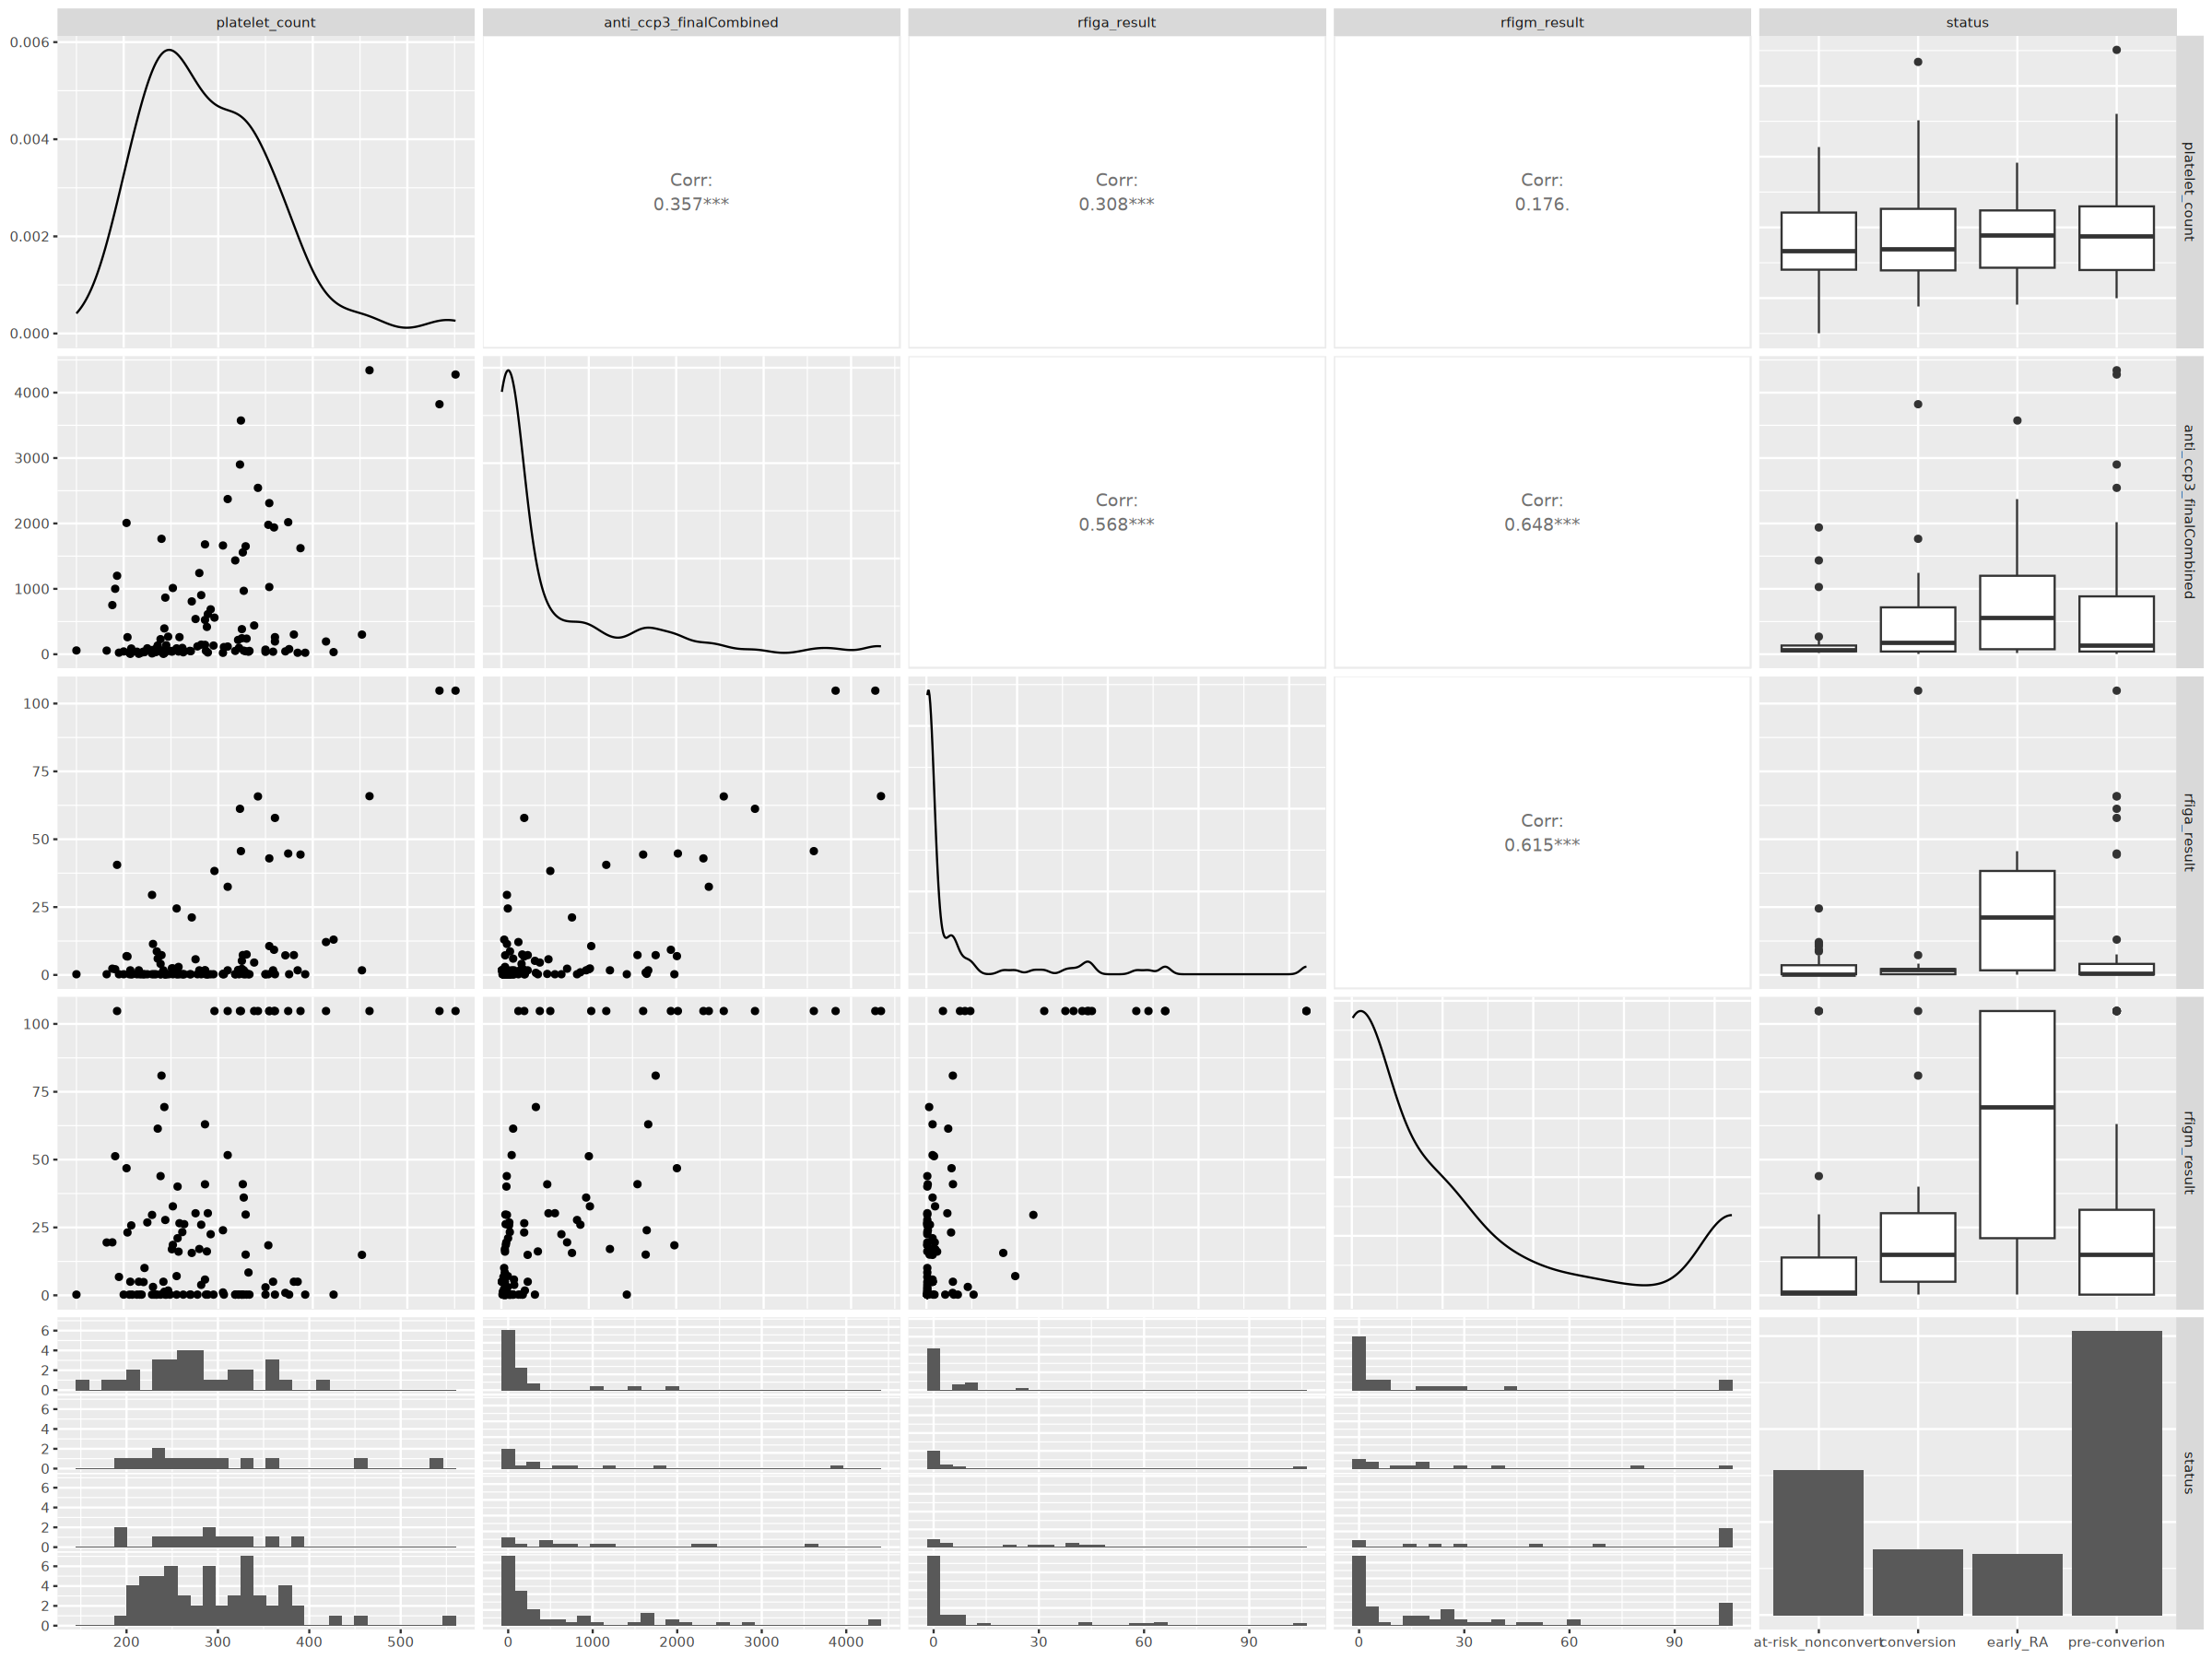

In [15]:
ggpairs(pla_abs_cor,upper = list(continuous = wrap(ggally_cor, method = "spearman")))

In [16]:
# Chiq test for share epitope
cros_shared_epitope = lab_data %>% filter(!is.na(Status_Xsec))%>%
    distinct(subject.subjectGuid, .keep_all = TRUE)%>%
    mutate(status=if_else(status%in%c('pre-converion', 'conversion'), 'conveters', status))%>%
    group_by(status,shared_epitope)%>%tally()%>%
    filter(!is.na(shared_epitope))%>%
    pivot_wider(id_cols ='shared_epitope',names_from =  'status',  values_from = 'n')%>%ungroup()
cros_shared_epitope%>%as.data.frame()%>%select(-shared_epitope)%>%pairwise_prop_test()
cros_shared_epitope

Warning message in prop.test(x[c(i, j)], n[c(i, j)], ...):
“Chi-squared approximation may be incorrect”
Warning message in prop.test(x[c(i, j)], n[c(i, j)], ...):
“Chi-squared approximation may be incorrect”


,group1,group2,p,p.adj,p.adj.signif
,<chr>,<chr>,<dbl>,<dbl>,<chr>
1,ALTRA_healthy,at-risk_nonconvert,0.960,1,ns
2,ALTRA_healthy,conveters,1.000,1,ns
3,at-risk_nonconvert,conveters,1.000,1,ns
4,ALTRA_healthy,early_RA,0.548,1,ns
5,at-risk_nonconvert,early_RA,0.712,1,ns
6,conveters,early_RA,0.736,1,ns


shared_epitope,ALTRA_healthy,at-risk_nonconvert,conveters,early_RA
<chr>,<int>,<int>,<int>,<int>
Neg,21,18,9,5
Pos,13,13,6,6


# ARI vs CON1

In [85]:
# load metadata for aim1
aim1_filedesc_fl <- read_csv(file.path(data_path, 'ALTRA_RA_Aim1_ALTRA_at_risk_vs_HCs_scrna_metadata.csv'),
                            show_col_types = FALSE)
# load the lab data from aim3
aim1_lab<- lab_data %>% filter(sample.sampleKitGuid%in%aim1_filedesc_fl$sample.sampleKitGuid)
aim1_lab <- aim1_lab%>%select_if(~sum(!is.na(.)) > 0)%>% arrange(ageAtDraw)%>%
    group_by(subject.subjectGuid)%>%
    mutate(age_baseline = first(ageAtDraw))%>% ungroup()%>% 
    mutate(age_bin=factor(if_else(age_baseline>55, 'above_55', 'below_55'), levels = c( 'below_55', 'above_55')),
          anti_ccp3_level = cut(anti_ccp3_finalCombined, breaks = c(0, 500, 1000, +Inf)))

aim1_lab%>%group_by(Status_Xsec)%>%tally()

Status_Xsec,n
<chr>,<int>
ALTRA_healthy,31
at_risk,45


In [90]:
# select clinical lab to test
aim1_lab_test <- aim1_lab %>% 
    select(all_of(c(lab_to_test, 
                    'status', 'Status_Xsec', 'ageAtDraw', 'shared_epitope',
                    'subject.biologicalSex', 'sample.sampleKitGuid')))

In [91]:
# run test in all labs
aim1_lab_long<- aim1_lab_test%>%pivot_longer(cols = all_of(lab_to_test), names_to = 'lab', values_to = 'value')

In [93]:
 # run wilcox test for frequency pretreatment vs healthy 
aim1_lab_stats_wilcox <- aim1_lab_long %>% #filter(!is.na(value))%>% 
    mutate(Status_Xsec=factor(Status_Xsec, levels = c('ALTRA_healthy', 'at_risk'))) %>%
    group_by(lab) %>% 
    rstatix::wilcox_test(data =., value ~ Status_Xsec ) %>%
      rstatix::adjust_pvalue(method = "BH") %>%
      rstatix::add_significance("p.adj") 
aim1_lab_stats_wilcox %>% filter(p<0.05) %>% arrange(p)

lab,.y.,group1,group2,n1,n2,statistic,p,p.adj,p.adj.signif
<chr>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>
anti_ccp3_finalCombined,value,ALTRA_healthy,at_risk,30,45,0.0,1.77e-13,6.018000e-12,****
mean_corpuscular_hemoglobin_concentration_mchc,value,ALTRA_healthy,at_risk,30,42,887.0,3.37e-03,5.729000e-02,ns
alkaline_phosphatase,value,ALTRA_healthy,at_risk,30,43,416.5,1.06e-02,1.201333e-01,ns
absolute_basophil_count,value,ALTRA_healthy,at_risk,30,42,789.0,3.65e-02,2.432889e-01,ns
mean_corpuscular_volume_mcv,value,ALTRA_healthy,at_risk,30,42,452.5,4.32e-02,2.432889e-01,ns
carbon_dioxide_co2,value,ALTRA_healthy,at_risk,30,43,468.5,4.48e-02,2.432889e-01,ns


In [288]:
# run glm pretreatment vs healthy 
model_glm <- function(freq_table, formula, cell_type){
    glm_res <- broom::tidy(stats::glm(as.formula(formula), data=freq_table)) %>%
        mutate(cell_type)
    return(glm_res)
}
lab_stats_glm <- aim1_lab_long %>% #filter(!is.na(value))%>% 
    mutate(Status_Xsec=factor(Status_Xsec, levels = c('ALTRA_healthy', 'at_risk'))) %>%
    group_by(lab) %>% 
    group_modify(~model_glm(.x, formula='value ~ Status_Xsec + subject.biologicalSex + ageAtDraw', 
                           cell_type=.y$lab)) 

In [290]:
lab_stats_glm %>%write_csv(file.path(output_path, 'AIM1_clinical_lab_glm_test.csv'))

In [137]:
lab_stats_glm_sig <- lab_stats_glm %>% filter(term=='Status_Xsecat_risk') %>%
    rstatix::adjust_pvalue(p.col = 'p.value', method = "BH") %>% filter(p.value.adj<0.05) %>% 
    arrange(p.value.adj)%>%select(-cell_type)
lab_stats_glm_sig

lab,term,estimate,std.error,statistic,p.value,p.value.adj
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
mean_corpuscular_hemoglobin_concentration_mchc,Status_Xsecat_risk,-0.9552411,0.2383753,-4.007299,0.0001548269,0.0001548269
alkaline_phosphatase,Status_Xsecat_risk,10.1865462,3.8444532,2.649674,0.0099813374,0.0099813374
anti_ccp3_finalCombined,Status_Xsecat_risk,376.5962035,147.6598891,2.550430,0.0129172517,0.0129172517
absolute_basophil_count,Status_Xsecat_risk,-27.8404448,11.5573306,-2.408899,0.0187152121,0.0187152121
carbon_dioxide_co2,Status_Xsecat_risk,0.9767471,0.4495933,2.172513,0.0332548478,0.0332548478
cholesterol_hdl,Status_Xsecat_risk,-6.4211970,3.0869878,-2.080085,0.0412340988,0.0412340988
mean_corpuscular_volume_mcv,Status_Xsecat_risk,1.8092395,0.8701702,2.079179,0.0413750654,0.0413750654


Warning message:
“Removed 22 rows containing non-finite values (`stat_ydensity()`).”
Warning message:
“Removed 22 rows containing missing values (`position_quasirandom()`).”
Warning message:
“Removed 22 rows containing non-finite values (`stat_ydensity()`).”
Warning message:
“Removed 22 rows containing missing values (`position_quasirandom()`).”


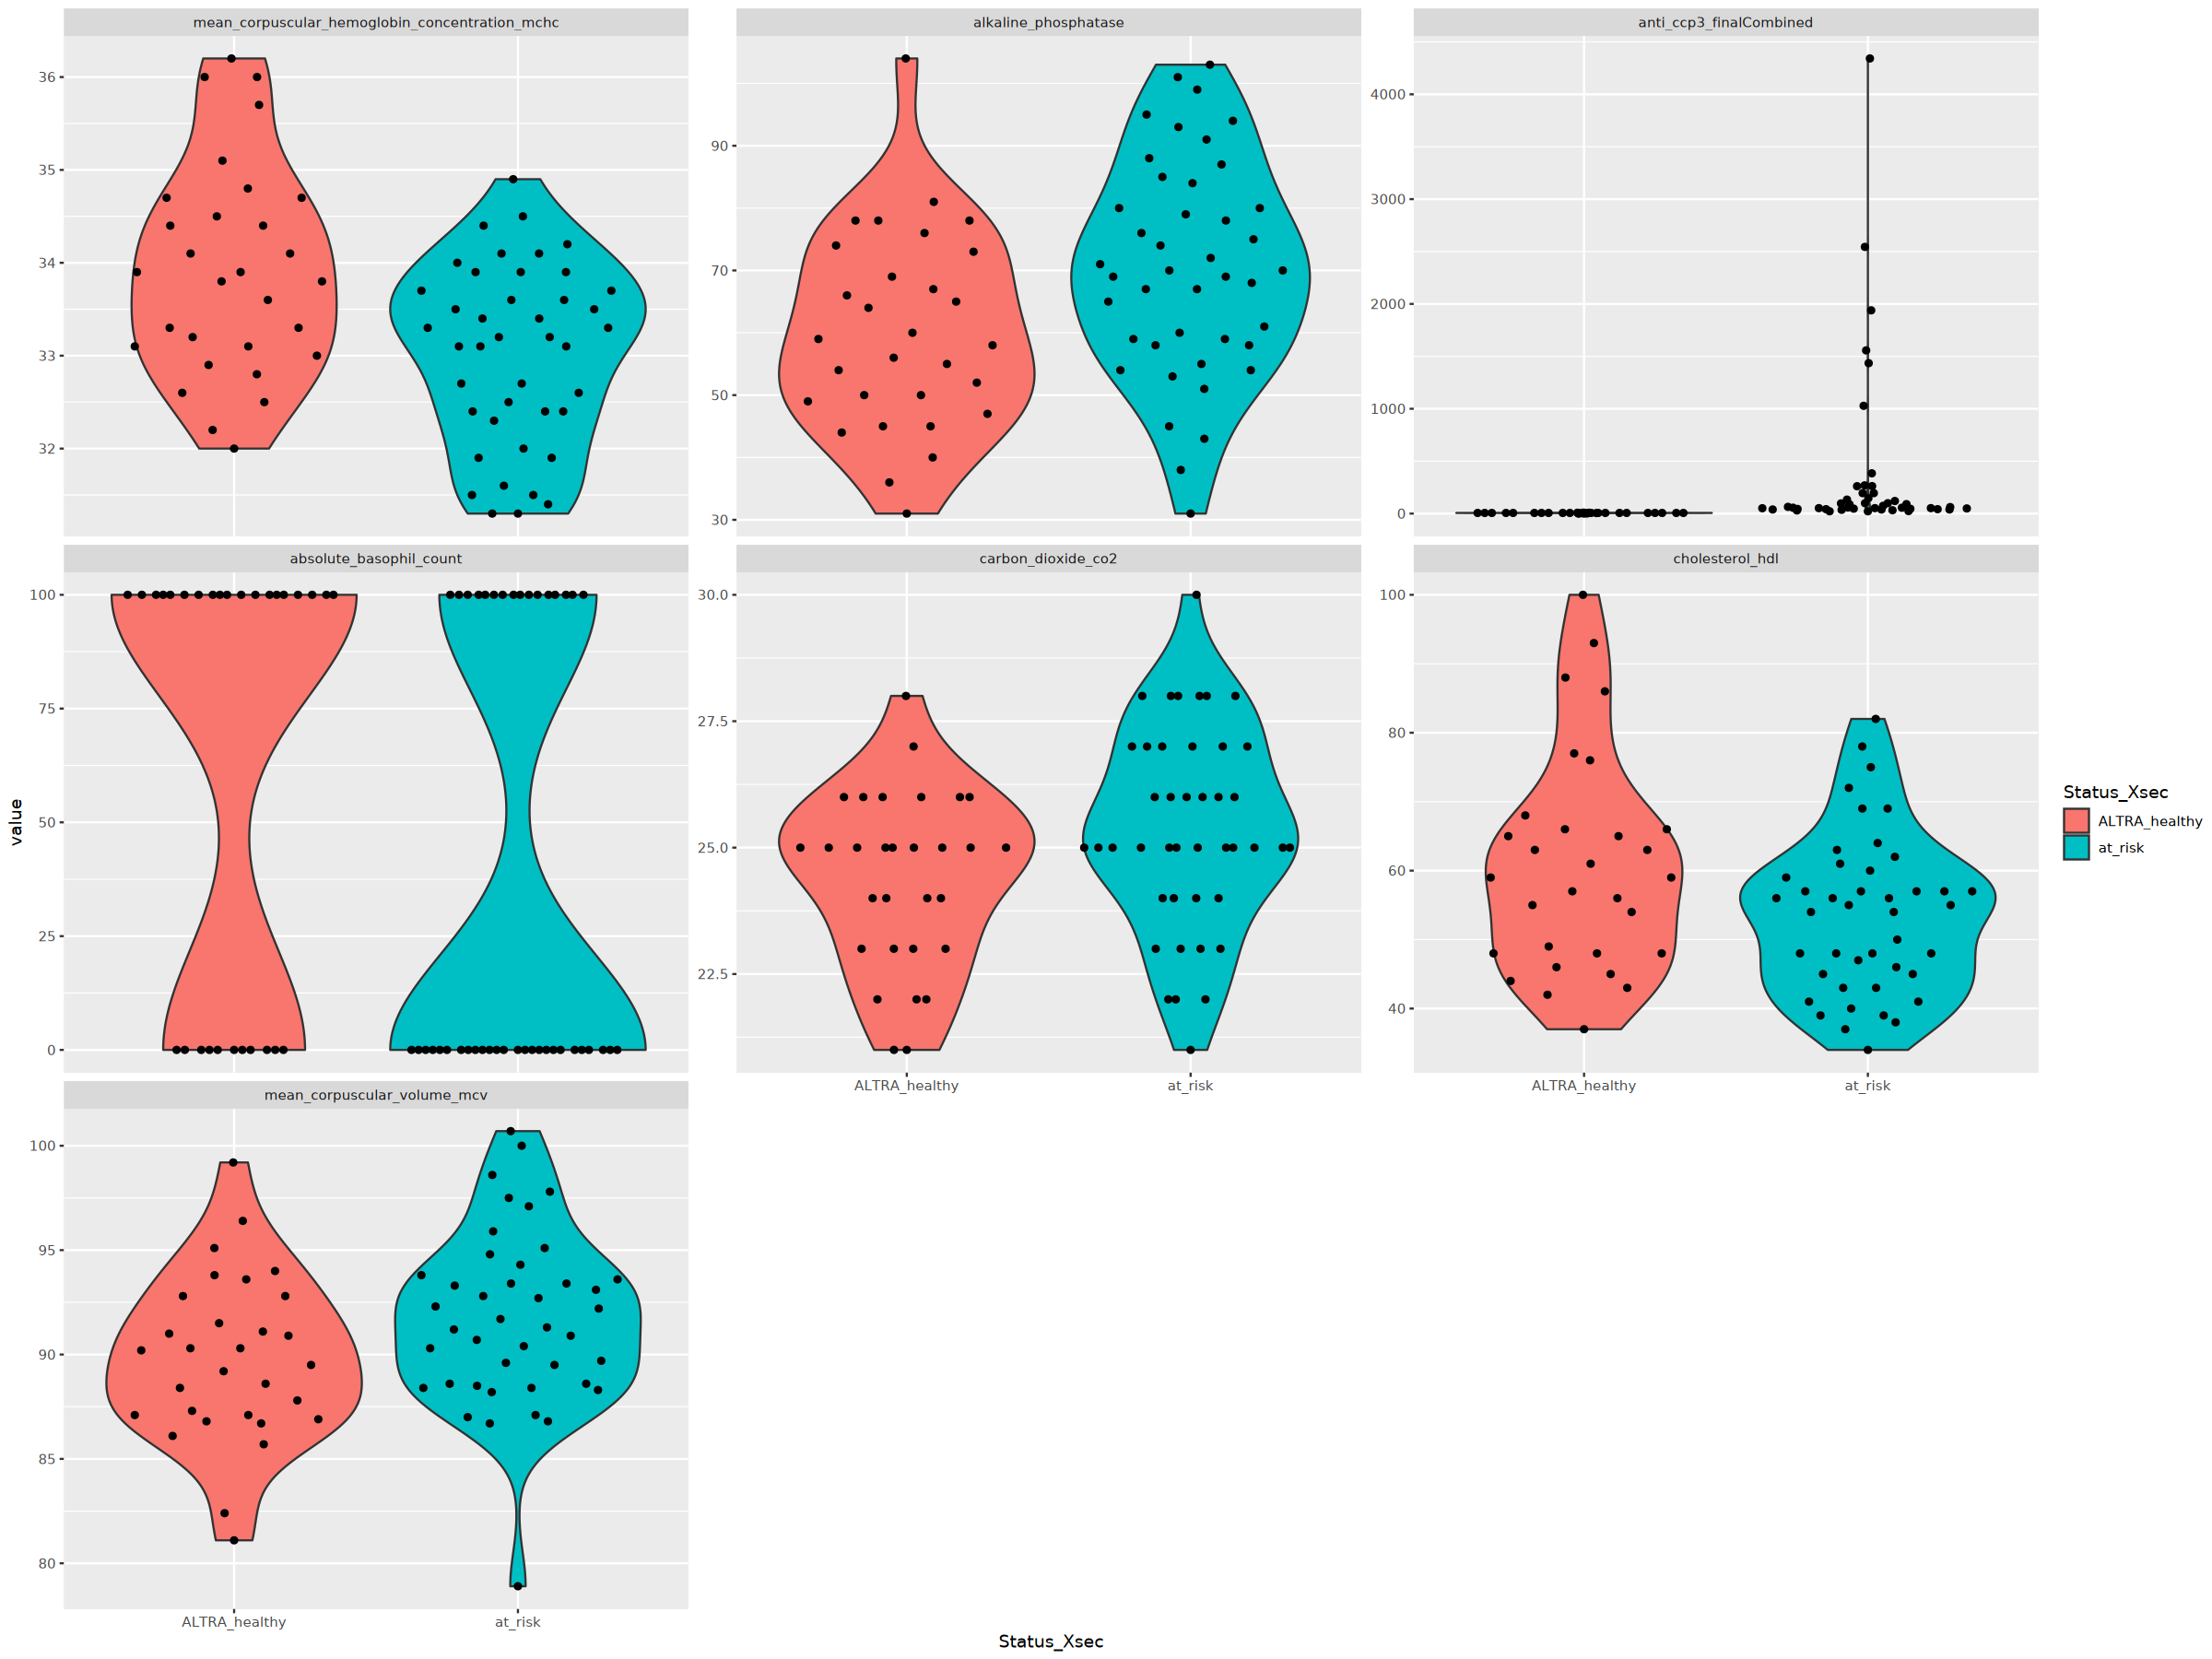

In [139]:
# plot the 
aim1_lab_long %>% filter(lab %in% lab_stats_glm_sig$`lab`) %>%
    mutate(lab=factor(lab, levels=lab_stats_glm_sig$lab))%>%
    ggplot(aes(x=Status_Xsec, y=value))+
   geom_violin(aes(fill=Status_Xsec)) + 
   ggbeeswarm::geom_quasirandom() +
   facet_wrap(vars(lab),  scales = 'free_y')
ggsave(file.path(fig_path, 'AIM1_clinical_lab_comparison_sig.png'), width=12, height=8)

In [175]:
 # run wilcox test for frequency pretreatment vs healthy 
aim1_lab_stats_anova <- aim1_lab_long %>% #filter(!is.na(value))%>% 
    mutate(status=factor(status, levels = c('ALTRA_healthy', 'at-risk_nonconvert', 'pre-converion'))) %>%
    group_by(lab) %>% 
    rstatix::anova_test(data =., value ~ status) %>% 
      rstatix::adjust_pvalue(method = "BH") %>%
      rstatix::add_significance("p.adj") 
# aim1_lab_stats_anova %>% as_tibble()%>%arrange(p)%>%head()
aim1_lab_stats_anova_sig <- aim1_lab_stats_anova%>% as_tibble() %>% filter(p.adj<0.2)
aim1_lab_stats_anova_sig

Warning message:
“There were 34 warnings in `mutate()`.
The first warning was:
ℹ In argument: `data = map(.data$data, .f, ...)`.
Caused by warning:
! NA detected in rows: 7,10,13,21.
Removing this rows before the analysis.
ℹ Run `dplyr::last_dplyr_warnings()` to see the 33 remaining warnings.”


lab,Effect,DFn,DFd,F,p,p<.05,ges,p.adj,p.adj.signif
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>
anti_ccp3_finalCombined,status,2,72,5.947,0.004,*,0.142,0.0425,*
carbon_dioxide_co2,status,2,70,6.881,0.002,*,0.164,0.0340,*
mean_corpuscular_hemoglobin_concentration_mchc,status,2,69,7.144,0.002,*,0.172,0.0340,*
mean_corpuscular_volume_mcv,status,2,69,5.701,0.005,*,0.142,0.0425,*
nucleated_red_blood_cell_nrbc_count,status,2,59,4.814,0.012,*,0.140,0.0816,ns


In [176]:
# aim1_lab %>% filter(nucleated_red_blood_cell_nrbc_count<=0) %>% select(nucleated_red_blood_cell_nrbc_count)

Warning message:
“Removed 26 rows containing non-finite values (`stat_ydensity()`).”
Warning message:
“Removed 26 rows containing missing values (`geom_point()`).”
Warning message:
“Removed 26 rows containing non-finite values (`stat_ydensity()`).”
Warning message:
“Removed 26 rows containing missing values (`geom_point()`).”


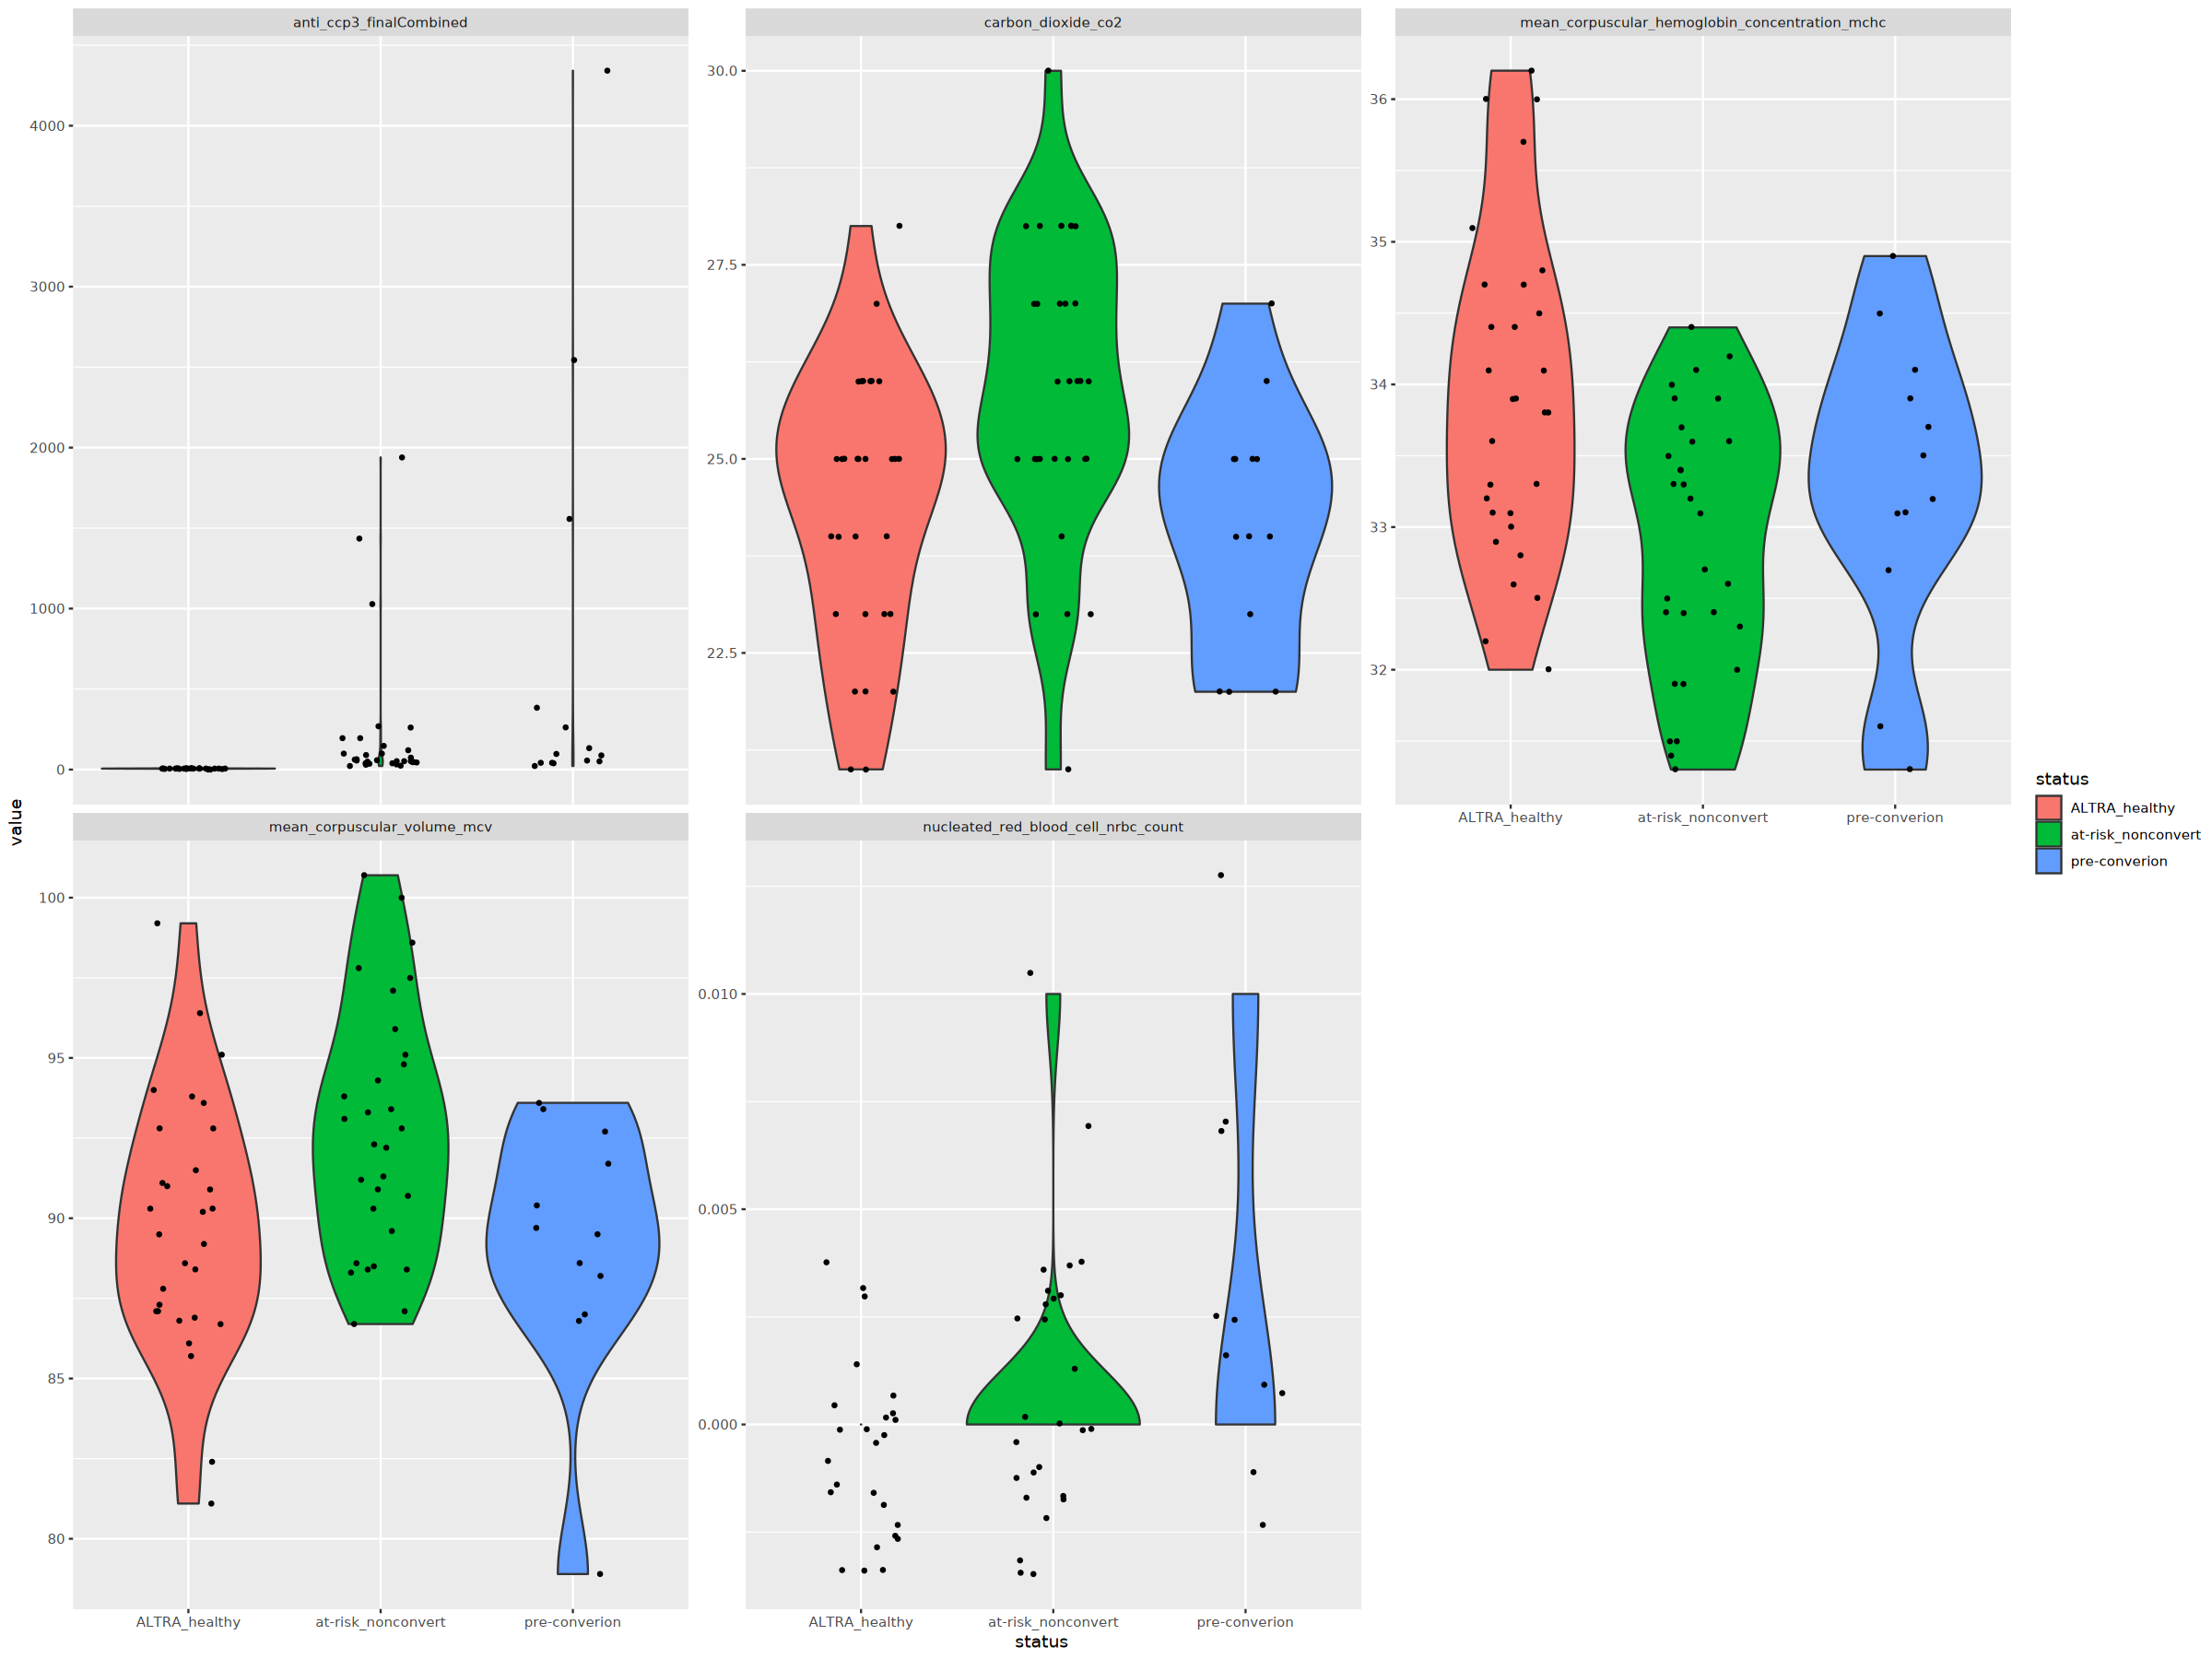

In [177]:
# plot the 
aim1_lab_long %>% filter(lab %in% aim1_lab_stats_anova_sig$`lab`) %>%
    ggplot(aes(x=status, y=value))+
   geom_violin(aes(fill=status)) + 
   geom_jitter(width = 0.2, size=0.8) +
   facet_wrap(vars(lab),  scales = 'free_y')
ggsave(file.path(fig_path, 'AIM1_clinical_lab_comparison_sig.png'), width=12, height=8)

# Early RA vs CON1

In [140]:
# load metadata for aim2
aim2_filedesc_fl <- read_csv(file.path(data_path, 'ALTRA_RA_Aim2_ALTRA_early_RA_vs_HCs_scrna_metadata.csv'),
                            show_col_types = FALSE)
# load the lab data from aim3
aim2_lab<- lab_data %>% filter(sample.sampleKitGuid%in%aim2_filedesc_fl$sample.sampleKitGuid)
aim2_lab <- aim2_lab%>%select_if(~sum(!is.na(.)) > 0)%>% arrange(ageAtDraw)%>%
    group_by(subject.subjectGuid)%>%
    mutate(age_baseline = first(ageAtDraw))%>% ungroup()%>% 
    mutate(age_bin=factor(if_else(age_baseline>55, 'above_55', 'below_55'), levels = c( 'below_55', 'above_55')),
          anti_ccp3_level = cut(anti_ccp3_finalCombined, breaks = c(0, 500, 1000, +Inf)))

aim2_lab%>%group_by(Status_Xsec)%>%tally()

Status_Xsec,n
<chr>,<int>
ALTRA_healthy,31
early_RA,25


In [143]:
# select clinical lab to test
aim2_lab_test <- aim2_lab %>% 
    select(all_of(c(lab_to_test, 
                    'status', 'Status_Xsec', 'ageAtDraw', 'shared_epitope',
                    'subject.biologicalSex', 'sample.sampleKitGuid')))

In [144]:
# run test in all labs
aim2_lab_long<- aim2_lab_test%>%pivot_longer(cols = all_of(lab_to_test), names_to = 'lab', values_to = 'value')

In [155]:
aim2_lab_long%>%distinct(Status_Xsec)

Status_Xsec
<chr>
early_RA
ALTRA_healthy


In [156]:
 # run wilcox test for frequency pretreatment vs healthy 
aim2_lab_stats_wilcox <- aim2_lab_long %>% #filter(!is.na(value))%>% 
    mutate(Status_Xsec=factor(Status_Xsec, levels = c('ALTRA_healthy', 'early_RA'))) %>%
    group_by(lab) %>% 
    rstatix::wilcox_test(data =., value ~ Status_Xsec ) %>%
      rstatix::adjust_pvalue(method = "BH") %>%
      rstatix::add_significance("p.adj") 
aim2_lab_stats_wilcox %>% filter(p<0.05) %>% arrange(p)

lab,.y.,group1,group2,n1,n2,statistic,p,p.adj,p.adj.signif
<chr>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>
anti_ccp3_finalCombined,value,ALTRA_healthy,early_RA,30,25,13.0,3.22e-10,1.094800e-08,****
albumin,value,ALTRA_healthy,early_RA,30,25,553.5,2.46e-03,4.182000e-02,*
absolute_basophil_count,value,ALTRA_healthy,early_RA,30,25,498.0,1.75e-02,1.983333e-01,ns
bilirubin_total_t_bili,value,ALTRA_healthy,early_RA,30,25,502.0,3.11e-02,2.643500e-01,ns
sed_rate_westergren_esr,value,ALTRA_healthy,early_RA,30,25,255.5,4.40e-02,2.680333e-01,ns
rfigm_result,value,ALTRA_healthy,early_RA,24,24,192.5,4.73e-02,2.680333e-01,ns


In [291]:
# run glm pretreatment vs healthy 
model_glm <- function(freq_table, formula, cell_type){
    glm_res <- broom::tidy(stats::glm(as.formula(formula), data=freq_table)) %>%
        mutate(cell_type)
    return(glm_res)
}
lab_stats_glm <- aim2_lab_long %>% #filter(!is.na(value))%>% 
    mutate(Status_Xsec=factor(Status_Xsec, levels = c('ALTRA_healthy', 'early_RA'))) %>%
    group_by(lab) %>% 
    group_modify(~model_glm(.x, formula='value ~ Status_Xsec + subject.biologicalSex + ageAtDraw', 
                           cell_type=.y$lab)) 

In [294]:
lab_stats_glm %>%write_csv(file.path(output_path, 'AIM2_clinical_lab_glm_test.csv'))

In [293]:
lab_stats_glm_sig <- lab_stats_glm %>% filter(term=='Status_Xsecearly_RA') %>%
    rstatix::adjust_pvalue(p.col = 'p.value', method = "BH") %>% filter(p.value.adj<0.05) %>% 
    arrange(p.value.adj)%>%select(-cell_type)
lab_stats_glm_sig

lab,term,estimate,std.error,statistic,p.value,p.value.adj
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
albumin,Status_Xsecearly_RA,-0.3014983,0.07624326,-3.954426,0.0002373663,0.0002373663
anti_ccp3_finalCombined,Status_Xsecearly_RA,725.5972526,204.23303953,3.552791,0.0008312659,0.0008312659
sed_rate_westergren_esr,Status_Xsecearly_RA,11.8338932,4.48382879,2.639238,0.0109945468,0.0109945468
bilirubin_total_t_bili,Status_Xsecearly_RA,-0.1852500,0.07057326,-2.624932,0.0114086625,0.0114086625
rfiga_result,Status_Xsecearly_RA,11.9167394,4.73724820,2.515540,0.0151435023,0.0151435023
mean_corpuscular_hemoglobin_concentration_mchc,Status_Xsecearly_RA,-0.7859658,0.32643009,-2.407761,0.0197060126,0.0197060126
absolute_basophil_count,Status_Xsecearly_RA,-29.4096788,14.61031512,-2.012939,0.0494144399,0.0494144399


Warning message:
“Removed 8 rows containing non-finite values (`stat_ydensity()`).”
Warning message:
“Removed 8 rows containing missing values (`position_quasirandom()`).”
Warning message:
“Removed 8 rows containing non-finite values (`stat_ydensity()`).”
Warning message:
“Removed 8 rows containing missing values (`position_quasirandom()`).”


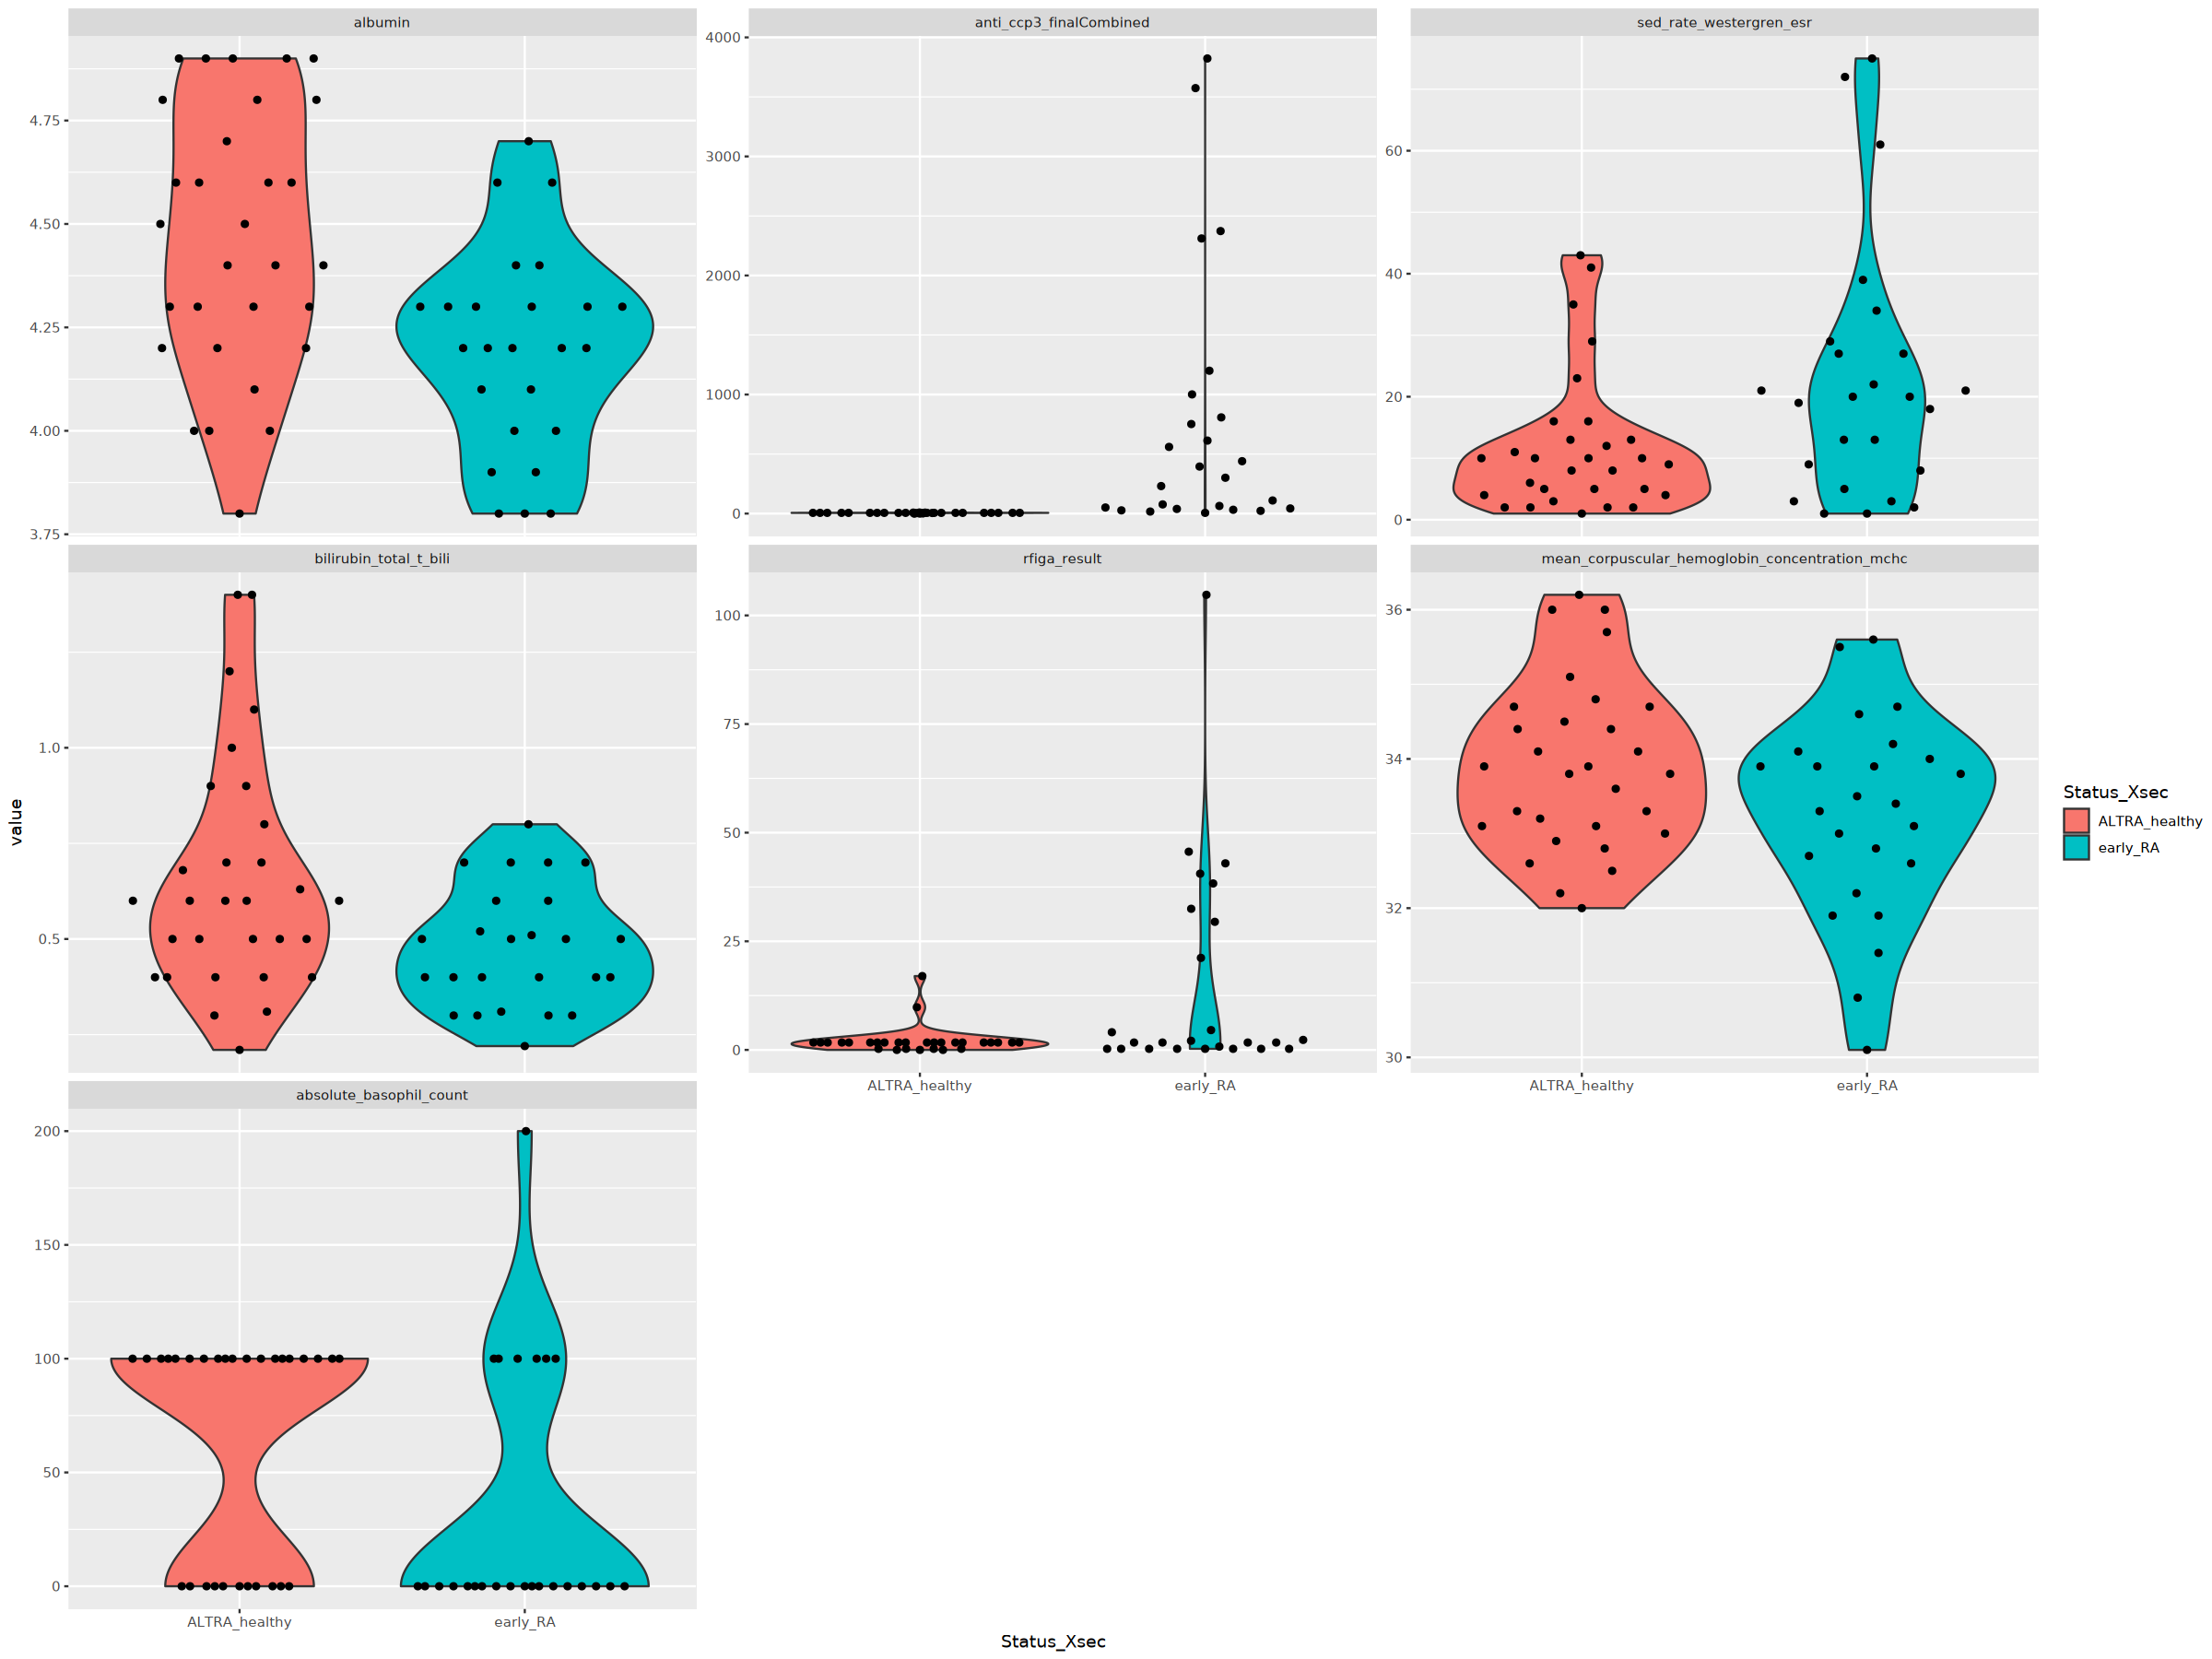

In [161]:
# plot  
aim2_lab_long %>% filter(lab %in% lab_stats_glm_sig$`lab`) %>%
    mutate(lab=factor(lab, levels=lab_stats_glm_sig$lab))%>%
    ggplot(aes(x=Status_Xsec, y=value))+
   geom_violin(aes(fill=Status_Xsec)) + 
   ggbeeswarm::geom_quasirandom() +
   facet_wrap(vars(lab),  scales = 'free_y')
ggsave(file.path(fig_path, 'aim2_clinical_lab_comparison_sig.png'), width=12, height=8)

In [164]:
aim2_lab_long%>%mutate(status=if_else(status%in%c('pre-converion', 'conversion'), 'conveters', status))%>%distinct(status)

status
<chr>
conveters
ALTRA_healthy
early_RA


In [172]:
 # run wilcox test for frequency pretreatment vs healthy 
aim2_lab_stats_anova <- aim2_lab_long %>% 
    mutate(status=if_else(status%in%c('pre-converion', 'conversion'), 'conveters', status))%>%
    mutate(status=factor(status, levels = c('ALTRA_healthy', 'conveters', 'early_RA'))) %>%
    group_by(lab) %>% 
    rstatix::anova_test(data =., value ~ status) %>% 
      rstatix::adjust_pvalue(method = "BH") %>%
      rstatix::add_significance("p.adj") 
# aim1_lab_stats_anova %>% as_tibble()%>%arrange(p)%>%head()
aim2_lab_stats_anova <- aim2_lab_stats_anova%>% as_tibble() %>% filter(p.adj<0.1)
aim2_lab_stats_anova

Warning message:
“There were 34 warnings in `mutate()`.
The first warning was:
ℹ In argument: `data = map(.data$data, .f, ...)`.
Caused by warning:
! NA detected in rows: 9.
Removing this rows before the analysis.
ℹ Run `dplyr::last_dplyr_warnings()` to see the 33 remaining warnings.”


lab,Effect,DFn,DFd,F,p,p<.05,ges,p.adj,p.adj.signif
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>
albumin,status,2,52,7.303,0.002000,*,0.219,0.03400000,*
anti_ccp3_finalCombined,status,2,52,8.638,0.000577,*,0.249,0.01961800,*
rfiga_result,status,2,51,5.162,0.009000,*,0.168,0.07650000,ns
rfigm_result,status,2,45,5.898,0.005000,*,0.208,0.05666667,ns


Warning message:
“Removed 12 rows containing non-finite values (`stat_ydensity()`).”
Warning message:
“Removed 12 rows containing missing values (`geom_point()`).”
Warning message:
“Removed 12 rows containing non-finite values (`stat_ydensity()`).”
Warning message:
“Removed 12 rows containing missing values (`geom_point()`).”


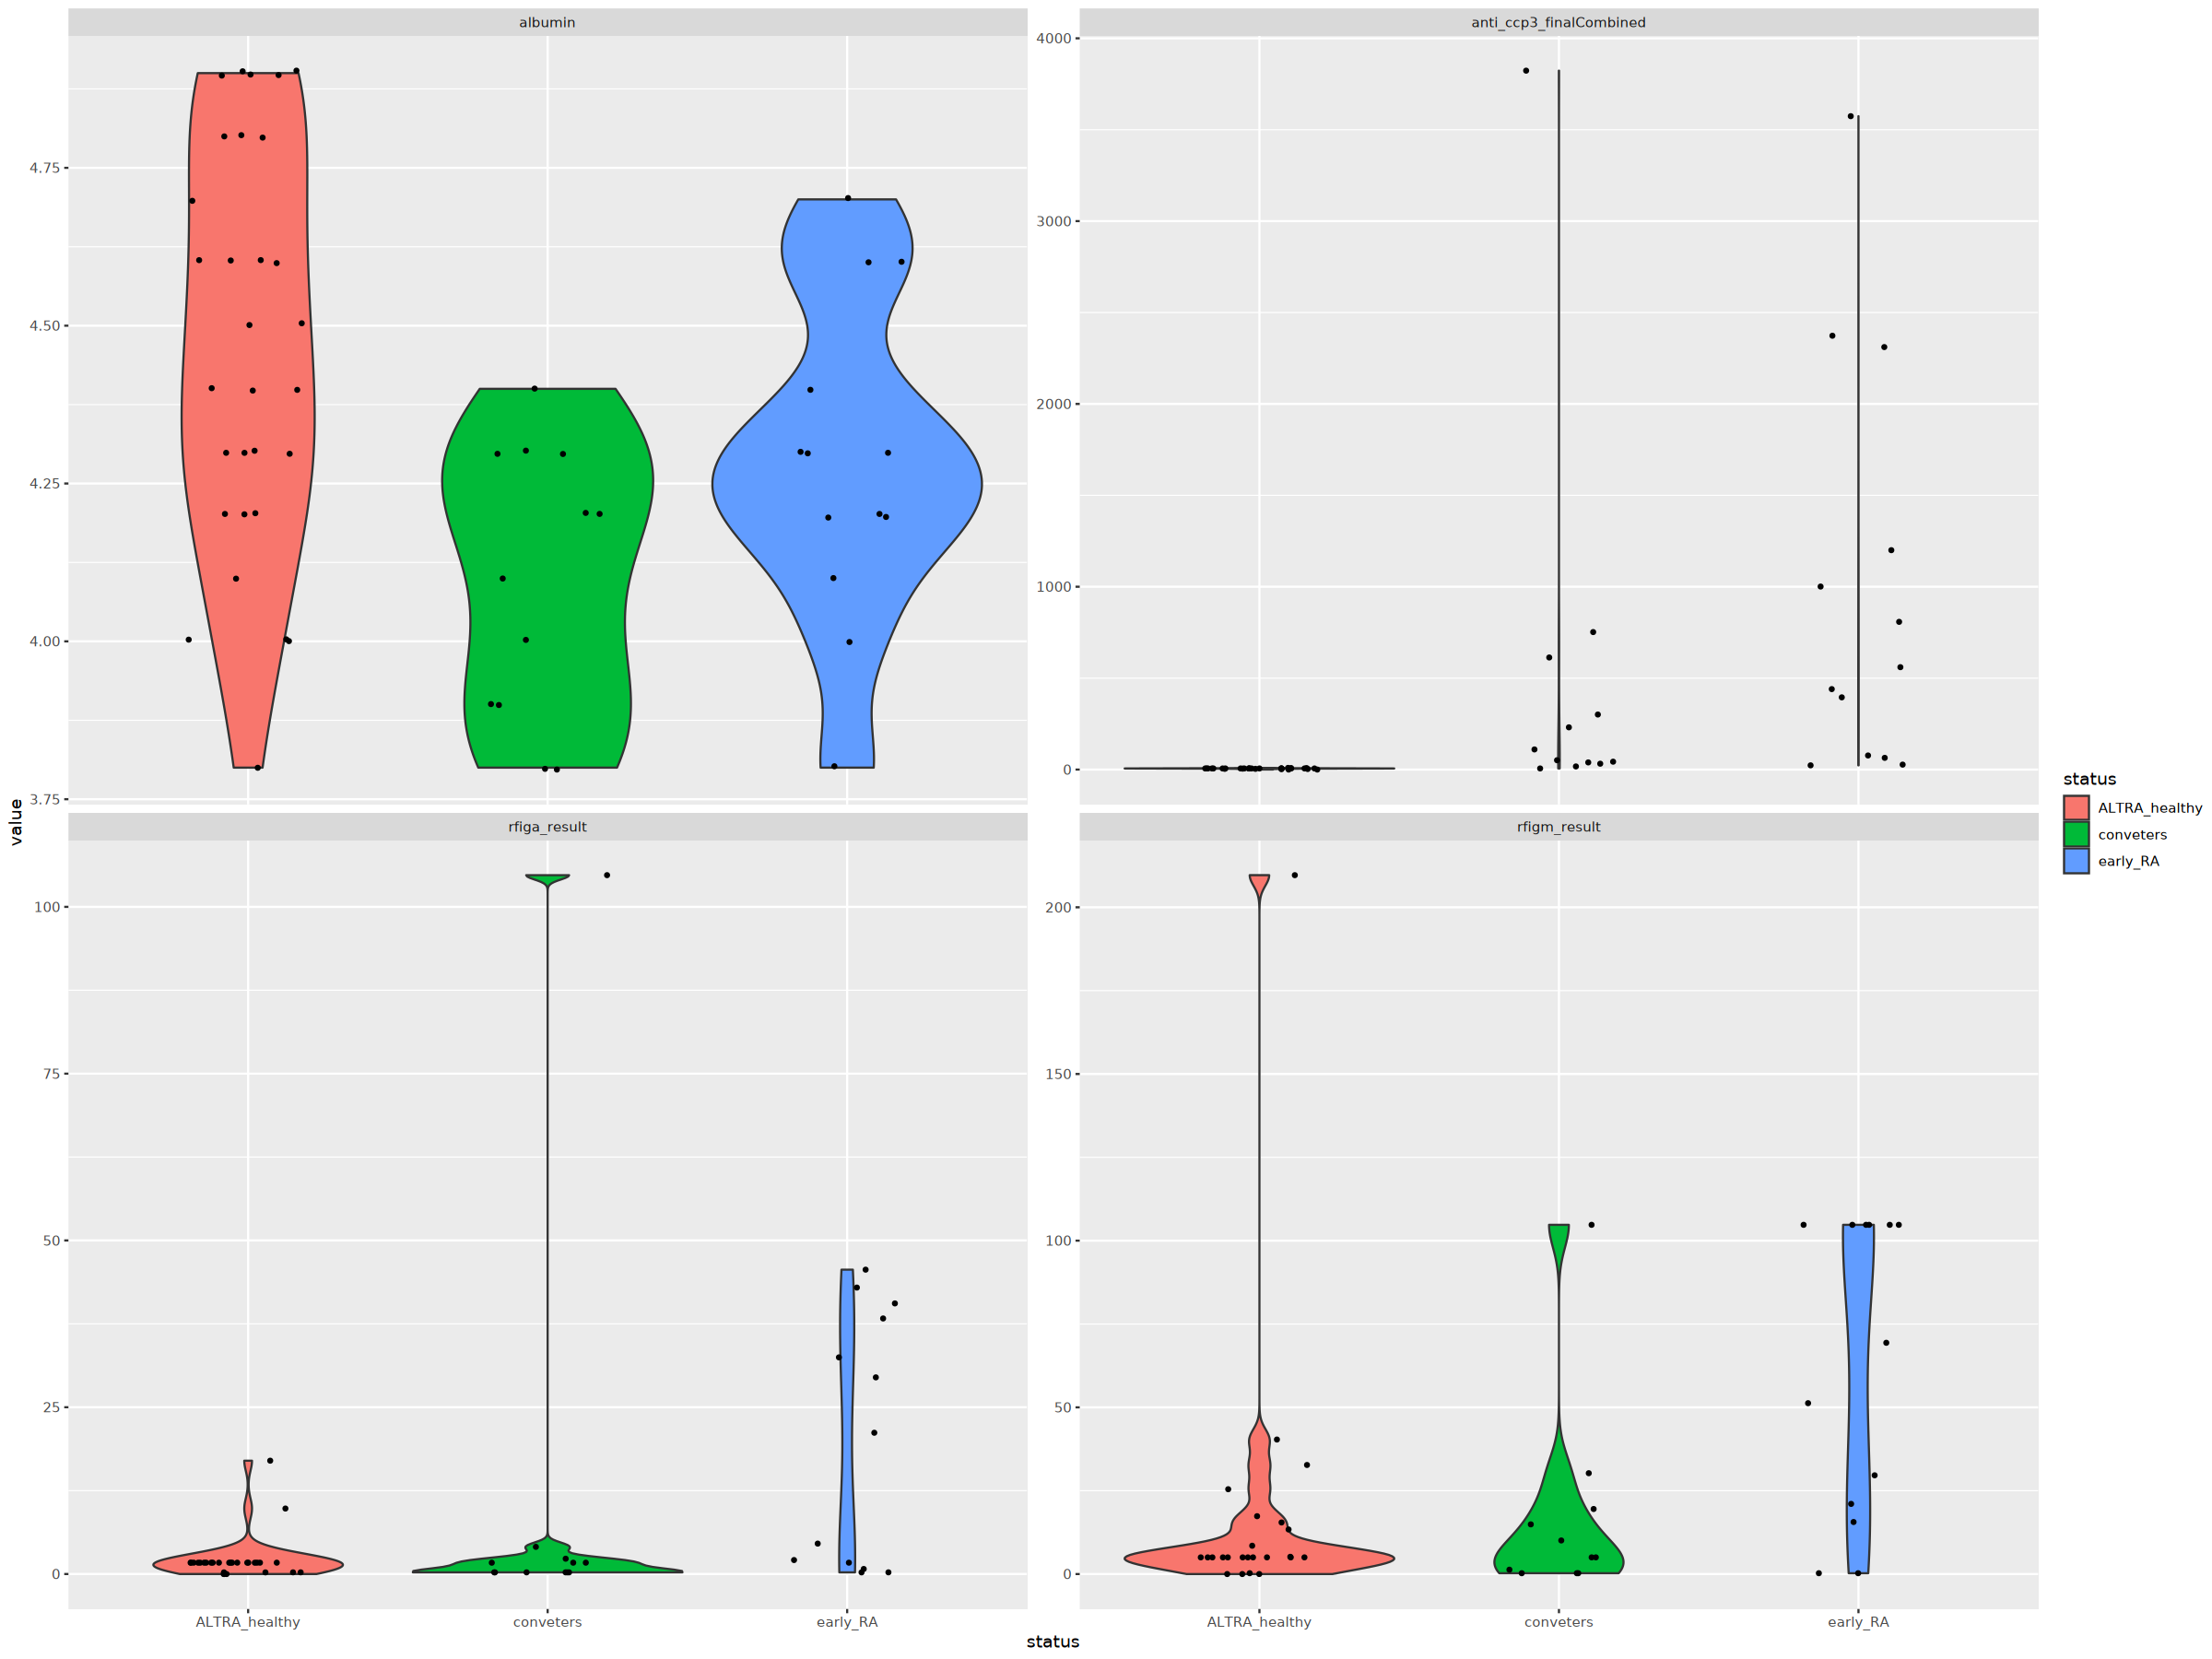

In [174]:
# plot the 
aim2_lab_long %>% 
    mutate(status=if_else(status%in%c('pre-converion', 'conversion'), 'conveters', status))%>%
    filter(lab %in% aim2_lab_stats_anova$`lab`) %>%
    ggplot(aes(x=status, y=value))+
   geom_violin(aes(fill=status)) + 
   geom_jitter(width = 0.2, size=0.8) +
   facet_wrap(vars(lab),  scales = 'free_y')
ggsave(file.path(fig_path, 'AIM2_clinical_lab_comparison_sig.png'), width=12, height=8)

# longitudinal clinical lab analysis in RA converters

In [30]:
# load metadata for aim3
aim3_filedesc_fl <- read_csv(file.path(data_path, 
                                       'ALTRA_RA_Aim3_ALTRA_converters_longitudinal_scrna_metadata.csv'), 
                            show_col_types = FALSE)
aim3_filedesc_fl %>% colnames()

[1] "lastUpdated"                         "sample.id"                          
 [3] "sample.bridgingControl"              "sample.sampleKitGuid"               
 [5] "sample.visitName"                    "sample.visitDetails"                
 [7] "sample.drawDate"                     "sample.daysSinceFirstVisit"         
 [9] "sample.diseaseStatesRecordedAtVisit" "file.id"                            
[11] "file.name"                           "file.batchID"                       
[13] "file.panel"                          "file.pool"                          
[15] "file.fileType"                       "file.majorVersion"                  
[17] "subject.id"                          "subject.biologicalSex"              
[19] "subject.birthYear"                   "subject.ethnicity"                  
[21] "subject.partnerCode"                 "subject.race"                       
[23] "subject.subjectGuid"                 "cohort.cohortGuid"                  
[25] "file.userTags.details"               "file.userTags.group"                
[27] "file.userTags.name"                  "file.userTags.origin"               
[29] "file.userTags.other"                 "file.userTags.version"              
[31] "days_to_conversion"                  "status"                             
[33] "age"

In [32]:
# load the lab data from aim3
aim3_lab<- lab_data %>% filter(sample.sampleKitGuid%in%aim3_filedesc_fl$sample.sampleKitGuid)
aim3_lab <- aim3_lab[,colSums(is.na(aim3_lab))<nrow(aim3_lab)]%>% arrange(ageAtDraw)%>%
    group_by(subject.subjectGuid)%>%
    mutate(age_baseline = first(ageAtDraw))%>% ungroup()%>% 
    mutate(age_bin=factor(if_else(age_baseline>55, 'above_55', 'below_55'), levels = c( 'below_55', 'above_55')),
          anti_ccp3_level = cut(anti_ccp3_finalCombined, breaks = c(0, 500, 1000, +Inf)))
aim3_lab%>%head()

Status_Xsec,Status_Long,sample.sampleKitGuid,sample.visitName,sample.visitDetails,sample.drawDate,sample.daysSinceFirstVisit,subject.subjectGuid,subject.biologicalSex,subject.birthYear,⋯,CMV_Status_Subj,CMV_Value_Subj,anti_ccp3_finalCombined,days_to_conversion,age_conv,bmi_conv,status,age_baseline,age_bin,anti_ccp3_level
<chr>,<chr>,<chr>,<chr>,<chr>,<date>,<dbl>,<chr>,<chr>,<dbl>,⋯,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<fct>,<fct>
at_risk,pre,KT00057,Flu Year 1 Day 0,N/A - Flu-Series Timepoint Only,2019-10-01,0,CU1003,Female,1998,⋯,Positive,3.171,262,-615,23,23.14306,pre-converion,21,below_55,"(0,500]"
NA,pre,KT00099,Flu Year 1 Day 90,N/A - Flu-Series Timepoint Only,2020-01-01,99,CU1003,Female,1998,⋯,Positive,3.171,866,-516,23,23.14306,pre-converion,21,below_55,"(500,1e+03]"
NA,pre,KT00227,Flu Year 2 Stand-Alone,N/A - Flu-Series Timepoint Only,2020-07-01,271,CU1003,Female,1998,⋯,Positive,3.171,904,-344,23,23.14306,pre-converion,21,below_55,"(500,1e+03]"
NA,pre,KT00440,Flu Year 2 Day 0,N/A - Flu-Series Timepoint Only,2020-10-01,355,CU1003,Female,1998,⋯,Positive,3.171,418,-260,23,23.14306,pre-converion,21,below_55,"(0,500]"
NA,pre,KT00493,Flu Year 2 Day 90,N/A - Flu-Series Timepoint Only,2021-02-01,488,CU1003,Female,1998,⋯,Positive,3.171,687,-127,23,23.14306,pre-converion,21,below_55,"(500,1e+03]"
early_RA,conversion,KT02135,Flu Year 3 Stand-Alone,RA Conversion,2021-06-01,615,CU1003,Female,1998,⋯,Positive,3.171,613,0,23,23.14306,conversion,21,below_55,"(500,1e+03]"


In [33]:
aim3_lab%>%colnames()
# get BMI at conversion from the metadata
bmi_data <- aim3_lab %>% group_by(subject.subjectGuid)%>%
    slice_max(order_by = days_to_conversion, n=1)%>% 
    select(BMI)%>%rename('BMI_conv'='BMI')
bmi_data%>%write_csv(file.path(output_path, 'ALTRA_RA_AIM3_BMI_data.csv'))

[1] "Status_Xsec"                                                   
 [2] "Status_Long"                                                   
 [3] "sample.sampleKitGuid"                                          
 [4] "sample.visitName"                                              
 [5] "sample.visitDetails"                                           
 [6] "sample.drawDate"                                               
 [7] "sample.daysSinceFirstVisit"                                    
 [8] "subject.subjectGuid"                                           
 [9] "subject.biologicalSex"                                         
[10] "subject.birthYear"                                             
[11] "subject.ethnicity"                                             
[12] "subject.race"                                                  
[13] "cohort.cohortGuid"                                             
[14] "Age2023"                                                       
[15] "ageAtDraw"                                                     
[16] "timeOnStudy"                                                   
[17] "timeOnStudyAsOf"                                               
[18] "percent_basophils"                                             
[19] "percent_eosinophils"                                           
[20] "percent_immature_granulocytes"                                 
[21] "percent_lymphocytes"                                           
[22] "percent_monocytes"                                             
[23] "percent_nucleated_red_blood_cells_nrbc"                        
[24] "0401_count"                                                    
[25] "0404_count"                                                    
[26] "0405_count"                                                    
[27] "0408_count"                                                    
[28] "absolute_basophil_count"                                       
[29] "absolute_eosinophil_count_aec"                                 
[30] "absolute_immature_granulocyte_count"                           
[31] "absolute_lymphocyte_count_alc"                                 
[32] "absolute_monocyte_count_amc"                                   
[33] "absolute_neutrophil_count_anc"                                 
[34] "alanine_transaminase_alt"                                      
[35] "albumin"                                                       
[36] "alkaline_phosphatase"                                          
[37] "anion_gap"                                                     
[38] "anti_ccp3"                                                     
[39] "anti_ccp31"                                                    
[40] "bilirubin_total_t_bili"                                        
[41] "c_reactive_protein_crp"                                        
[42] "calcium"                                                       
[43] "carbon_dioxide_co2"                                            
[44] "cholesterol_hdl"                                               
[45] "cholesterol_ldl"                                               
[46] "cholesterol_total"                                             
[47] "converted_to_ia_during_course_of_study"                        
[48] "converted_to_ra_during_study"                                  
[49] "covid_19_vaccine_company_name"                                 
[50] "covid_19_vaccine_ever_received"                                
[51] "creatinine"                                                    
[52] "estimated_glomerular_filtration_rate_egfr_non_african_american"
[53] "glucose"                                                       
[54] "has_the_patient_been_fasting?"                                 
[55] "height"                                                        
[56] "hematocrit"                                                    
[57] "hip_size"                                                      
[58] "mean_

Adding missing grouping variables: `subject.subjectGuid`


## examine autoantibodies levels

In [38]:
aim3_lab%>%filter(is.na(anti_ccp3_finalCombined))
aim3_lab%>%filter(is.na(rfigm_result))
aim3_lab%>%filter(is.na(rfiga_result))

Status_Xsec,Status_Long,sample.sampleKitGuid,sample.visitName,sample.visitDetails,sample.drawDate,sample.daysSinceFirstVisit,subject.subjectGuid,subject.biologicalSex,subject.birthYear,⋯,CMV_Status_Subj,CMV_Value_Subj,anti_ccp3_finalCombined,days_to_conversion,age_conv,bmi_conv,status,age_baseline,age_bin,anti_ccp3_level
<chr>,<chr>,<chr>,<chr>,<chr>,<date>,<dbl>,<chr>,<chr>,<dbl>,⋯,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<fct>,<fct>
NA,pre,KT00105,Flu Year 1 Day 0,N/A - Flu-Series Timepoint Only,2020-12-01,112,SD1007,Female,1989,⋯,Positive,3.220,NA,-92,32,26.02500,pre-converion,31,below_55,NA
NA,pre,KT02968,Flu Year 1 Day 90,N/A - Flu-Series Timepoint Only,2022-02-01,276,CU1052,Female,1988,⋯,Negative,0.197,NA,-441,35,29.18762,pre-converion,33,below_55,NA


Status_Xsec,Status_Long,sample.sampleKitGuid,sample.visitName,sample.visitDetails,sample.drawDate,sample.daysSinceFirstVisit,subject.subjectGuid,subject.biologicalSex,subject.birthYear,⋯,CMV_Status_Subj,CMV_Value_Subj,anti_ccp3_finalCombined,days_to_conversion,age_conv,bmi_conv,status,age_baseline,age_bin,anti_ccp3_level
<chr>,<chr>,<chr>,<chr>,<chr>,<date>,<dbl>,<chr>,<chr>,<dbl>,⋯,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<fct>,<fct>
NA,pre,KT00105,Flu Year 1 Day 0,N/A - Flu-Series Timepoint Only,2020-12-01,112,SD1007,Female,1989,⋯,Positive,3.220,NA,-92,32,26.02500,pre-converion,31,below_55,NA
NA,pre,KT02968,Flu Year 1 Day 90,N/A - Flu-Series Timepoint Only,2022-02-01,276,CU1052,Female,1988,⋯,Negative,0.197,NA,-441,35,29.18762,pre-converion,33,below_55,NA
early_RA,conversion,KT04924,RA Year 4 Visit 3,N/A - on-going collection,2023-04-01,717,CU1052,Female,1988,⋯,Negative,0.197,231,0,35,29.18762,conversion,33,below_55,"(0,500]"


Status_Xsec,Status_Long,sample.sampleKitGuid,sample.visitName,sample.visitDetails,sample.drawDate,sample.daysSinceFirstVisit,subject.subjectGuid,subject.biologicalSex,subject.birthYear,⋯,CMV_Status_Subj,CMV_Value_Subj,anti_ccp3_finalCombined,days_to_conversion,age_conv,bmi_conv,status,age_baseline,age_bin,anti_ccp3_level
<chr>,<chr>,<chr>,<chr>,<chr>,<date>,<dbl>,<chr>,<chr>,<dbl>,⋯,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<fct>,<fct>
NA,pre,KT00105,Flu Year 1 Day 0,N/A - Flu-Series Timepoint Only,2020-12-01,112,SD1007,Female,1989,⋯,Positive,3.220,NA,-92,32,26.02500,pre-converion,31,below_55,NA
NA,pre,KT02968,Flu Year 1 Day 90,N/A - Flu-Series Timepoint Only,2022-02-01,276,CU1052,Female,1988,⋯,Negative,0.197,NA,-441,35,29.18762,pre-converion,33,below_55,NA


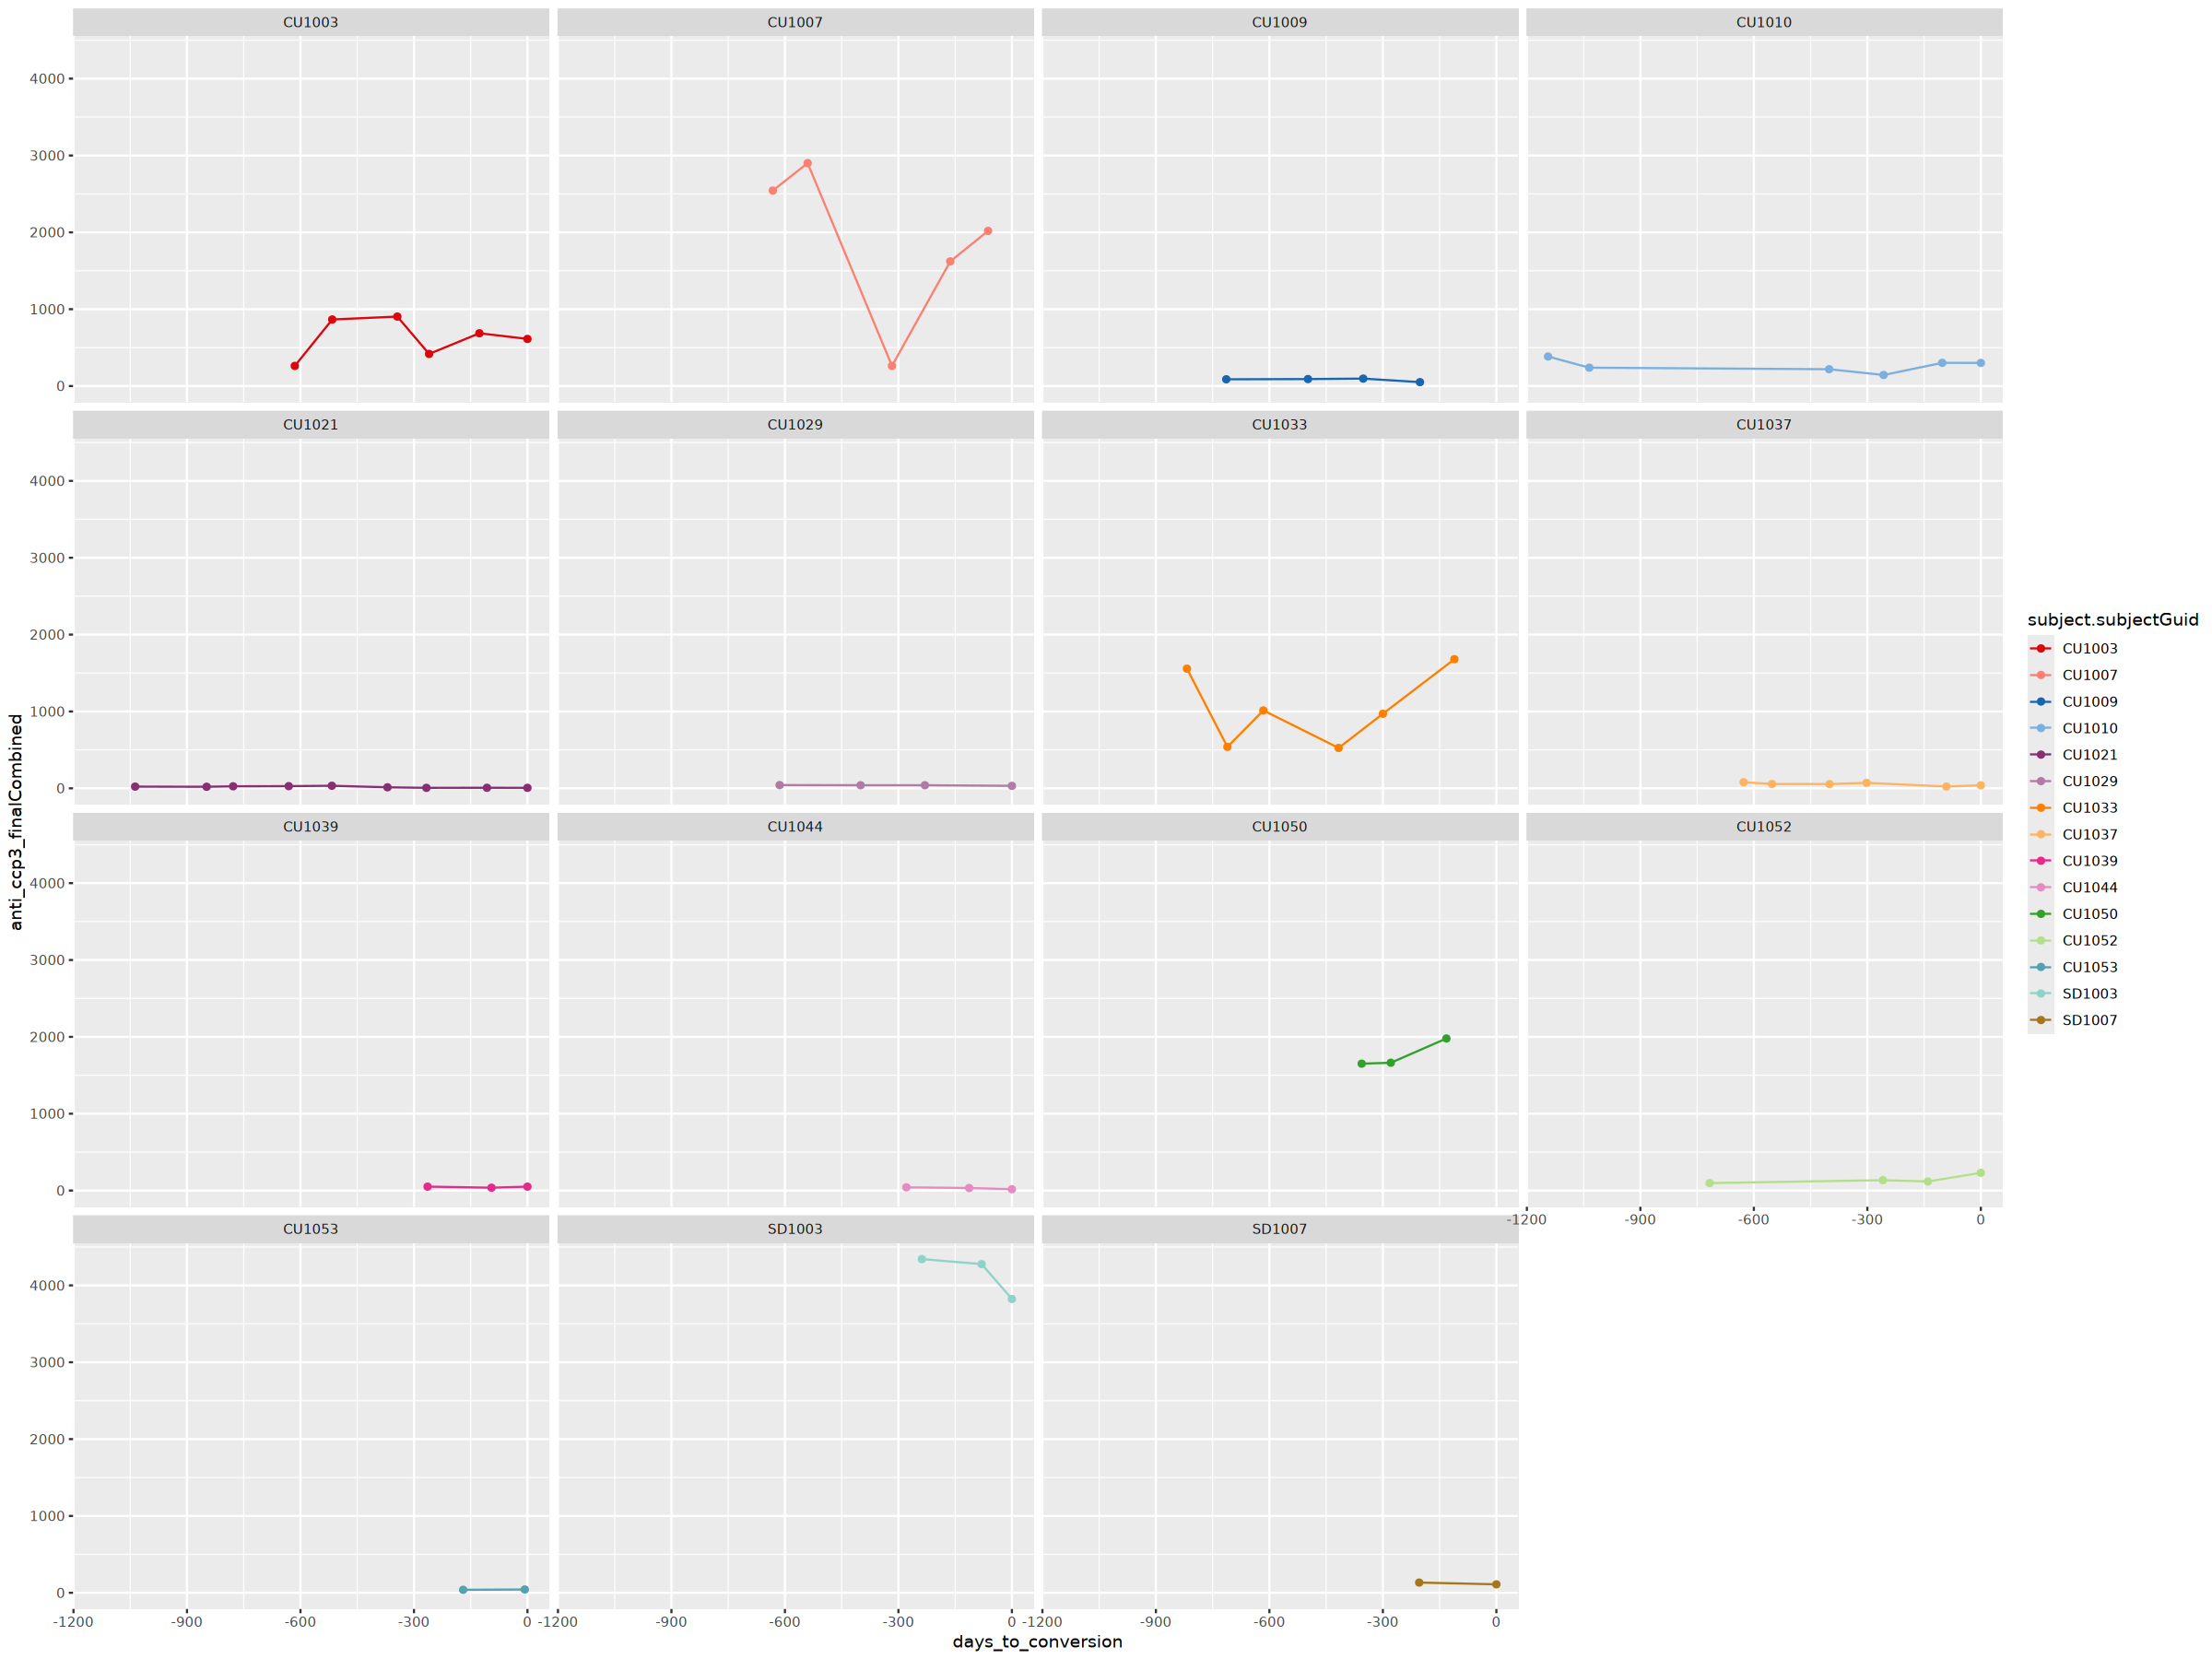

In [40]:
# plot CCP3
p1 <- aim3_lab %>% filter(!is.na(anti_ccp3_finalCombined))%>%
  ggplot( aes(x=days_to_conversion, y=anti_ccp3_finalCombined, color=subject.subjectGuid)) +
    geom_line() +  geom_point()  +  
    scale_color_manual(values = cluster_colors) + facet_wrap(vars(subject.subjectGuid))
p1
ggsave(file.path(fig_path, 'AIM3_ccp3_longitudinal.png'), width=12, height=8)

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


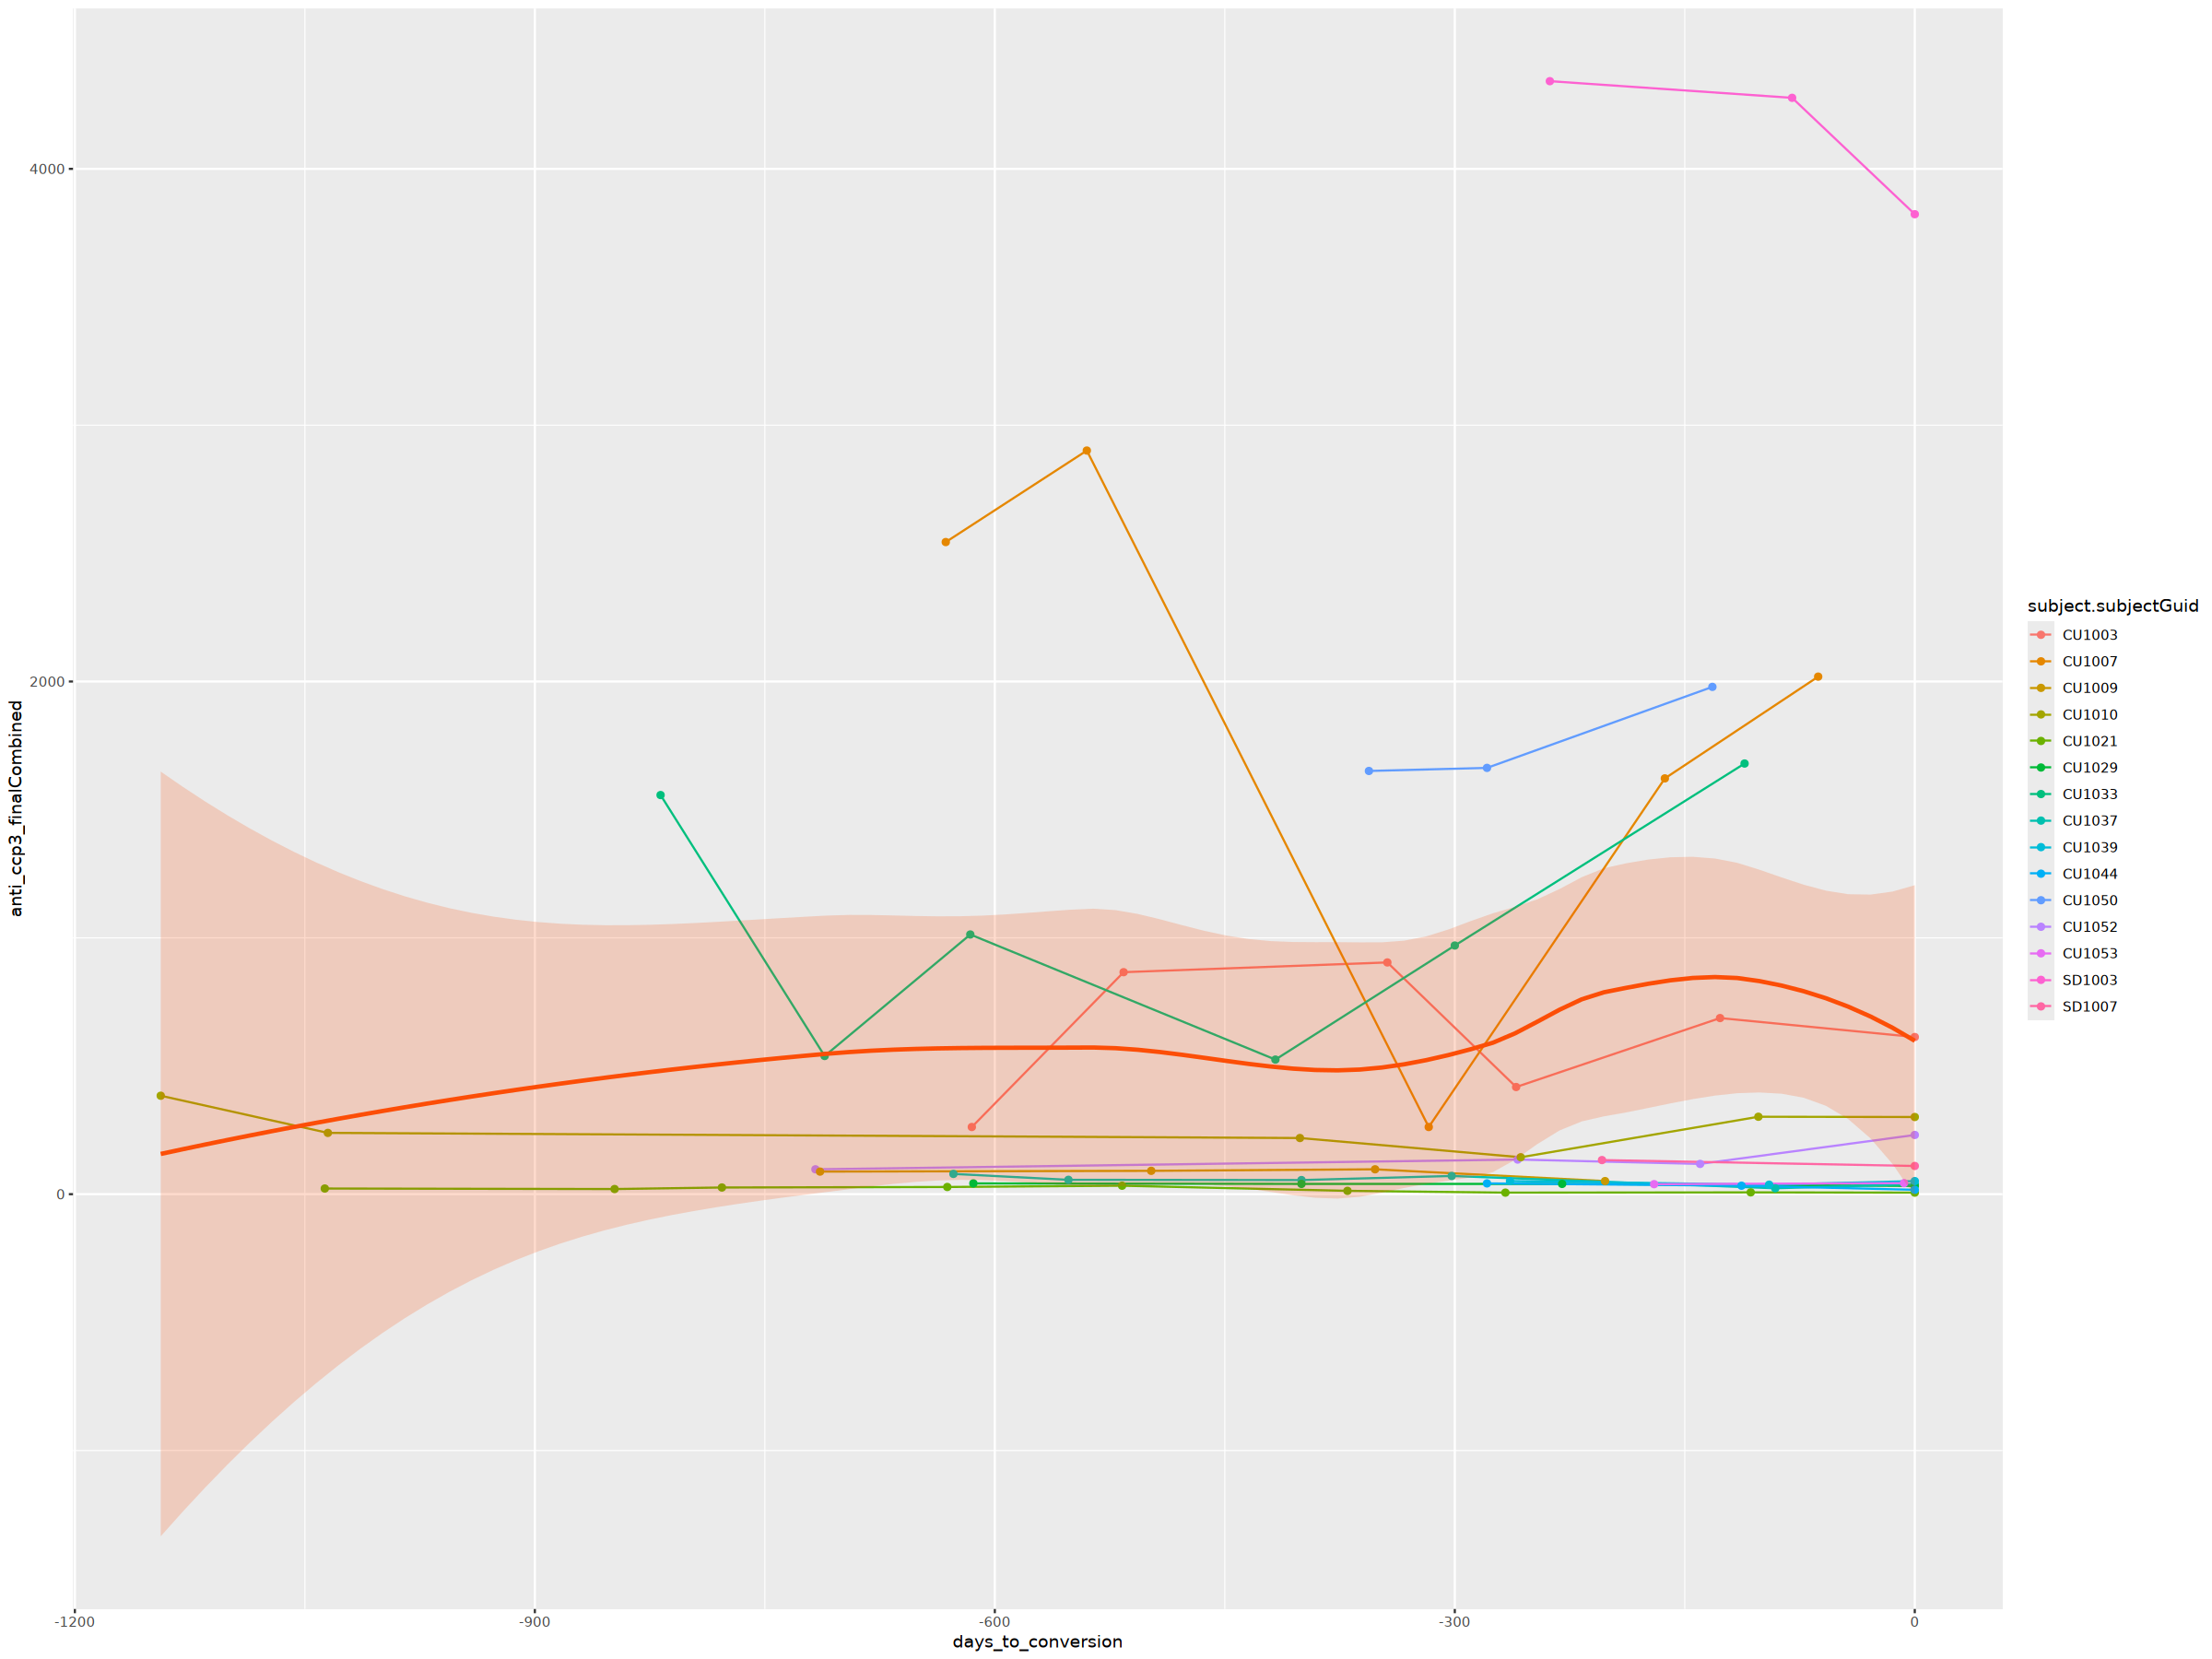

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


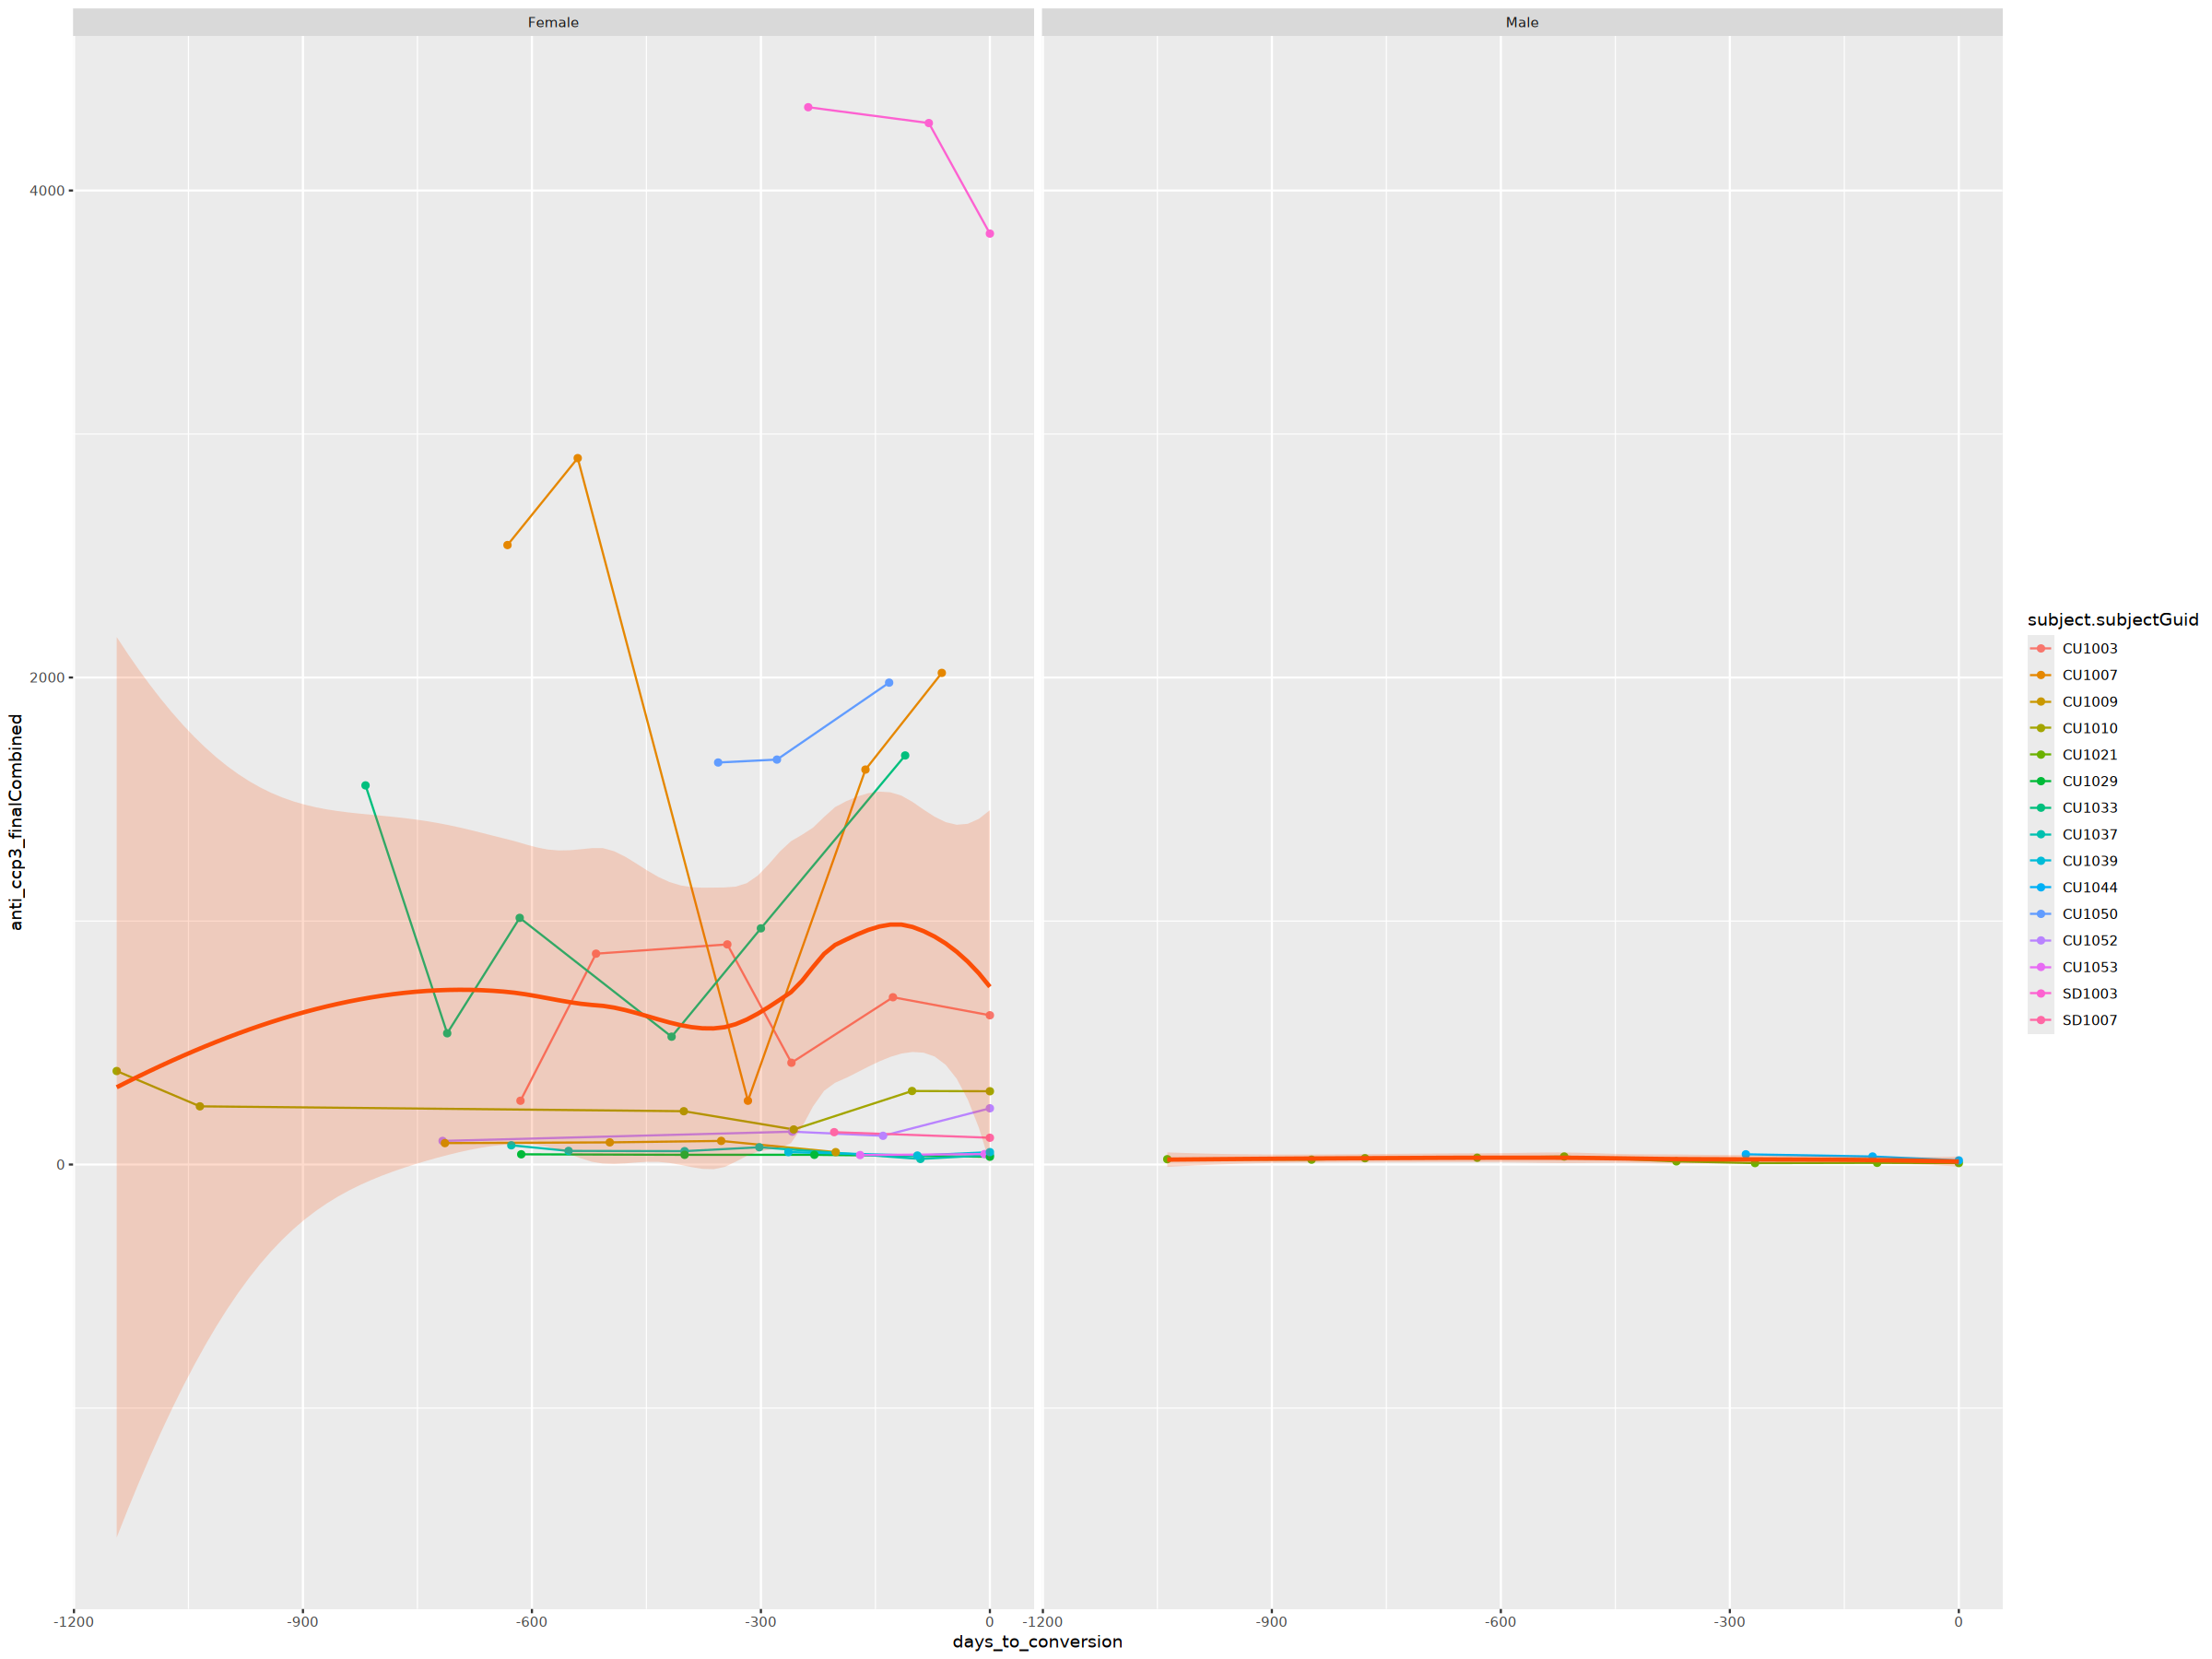

`geom_smooth()` using formula = 'y ~ x'


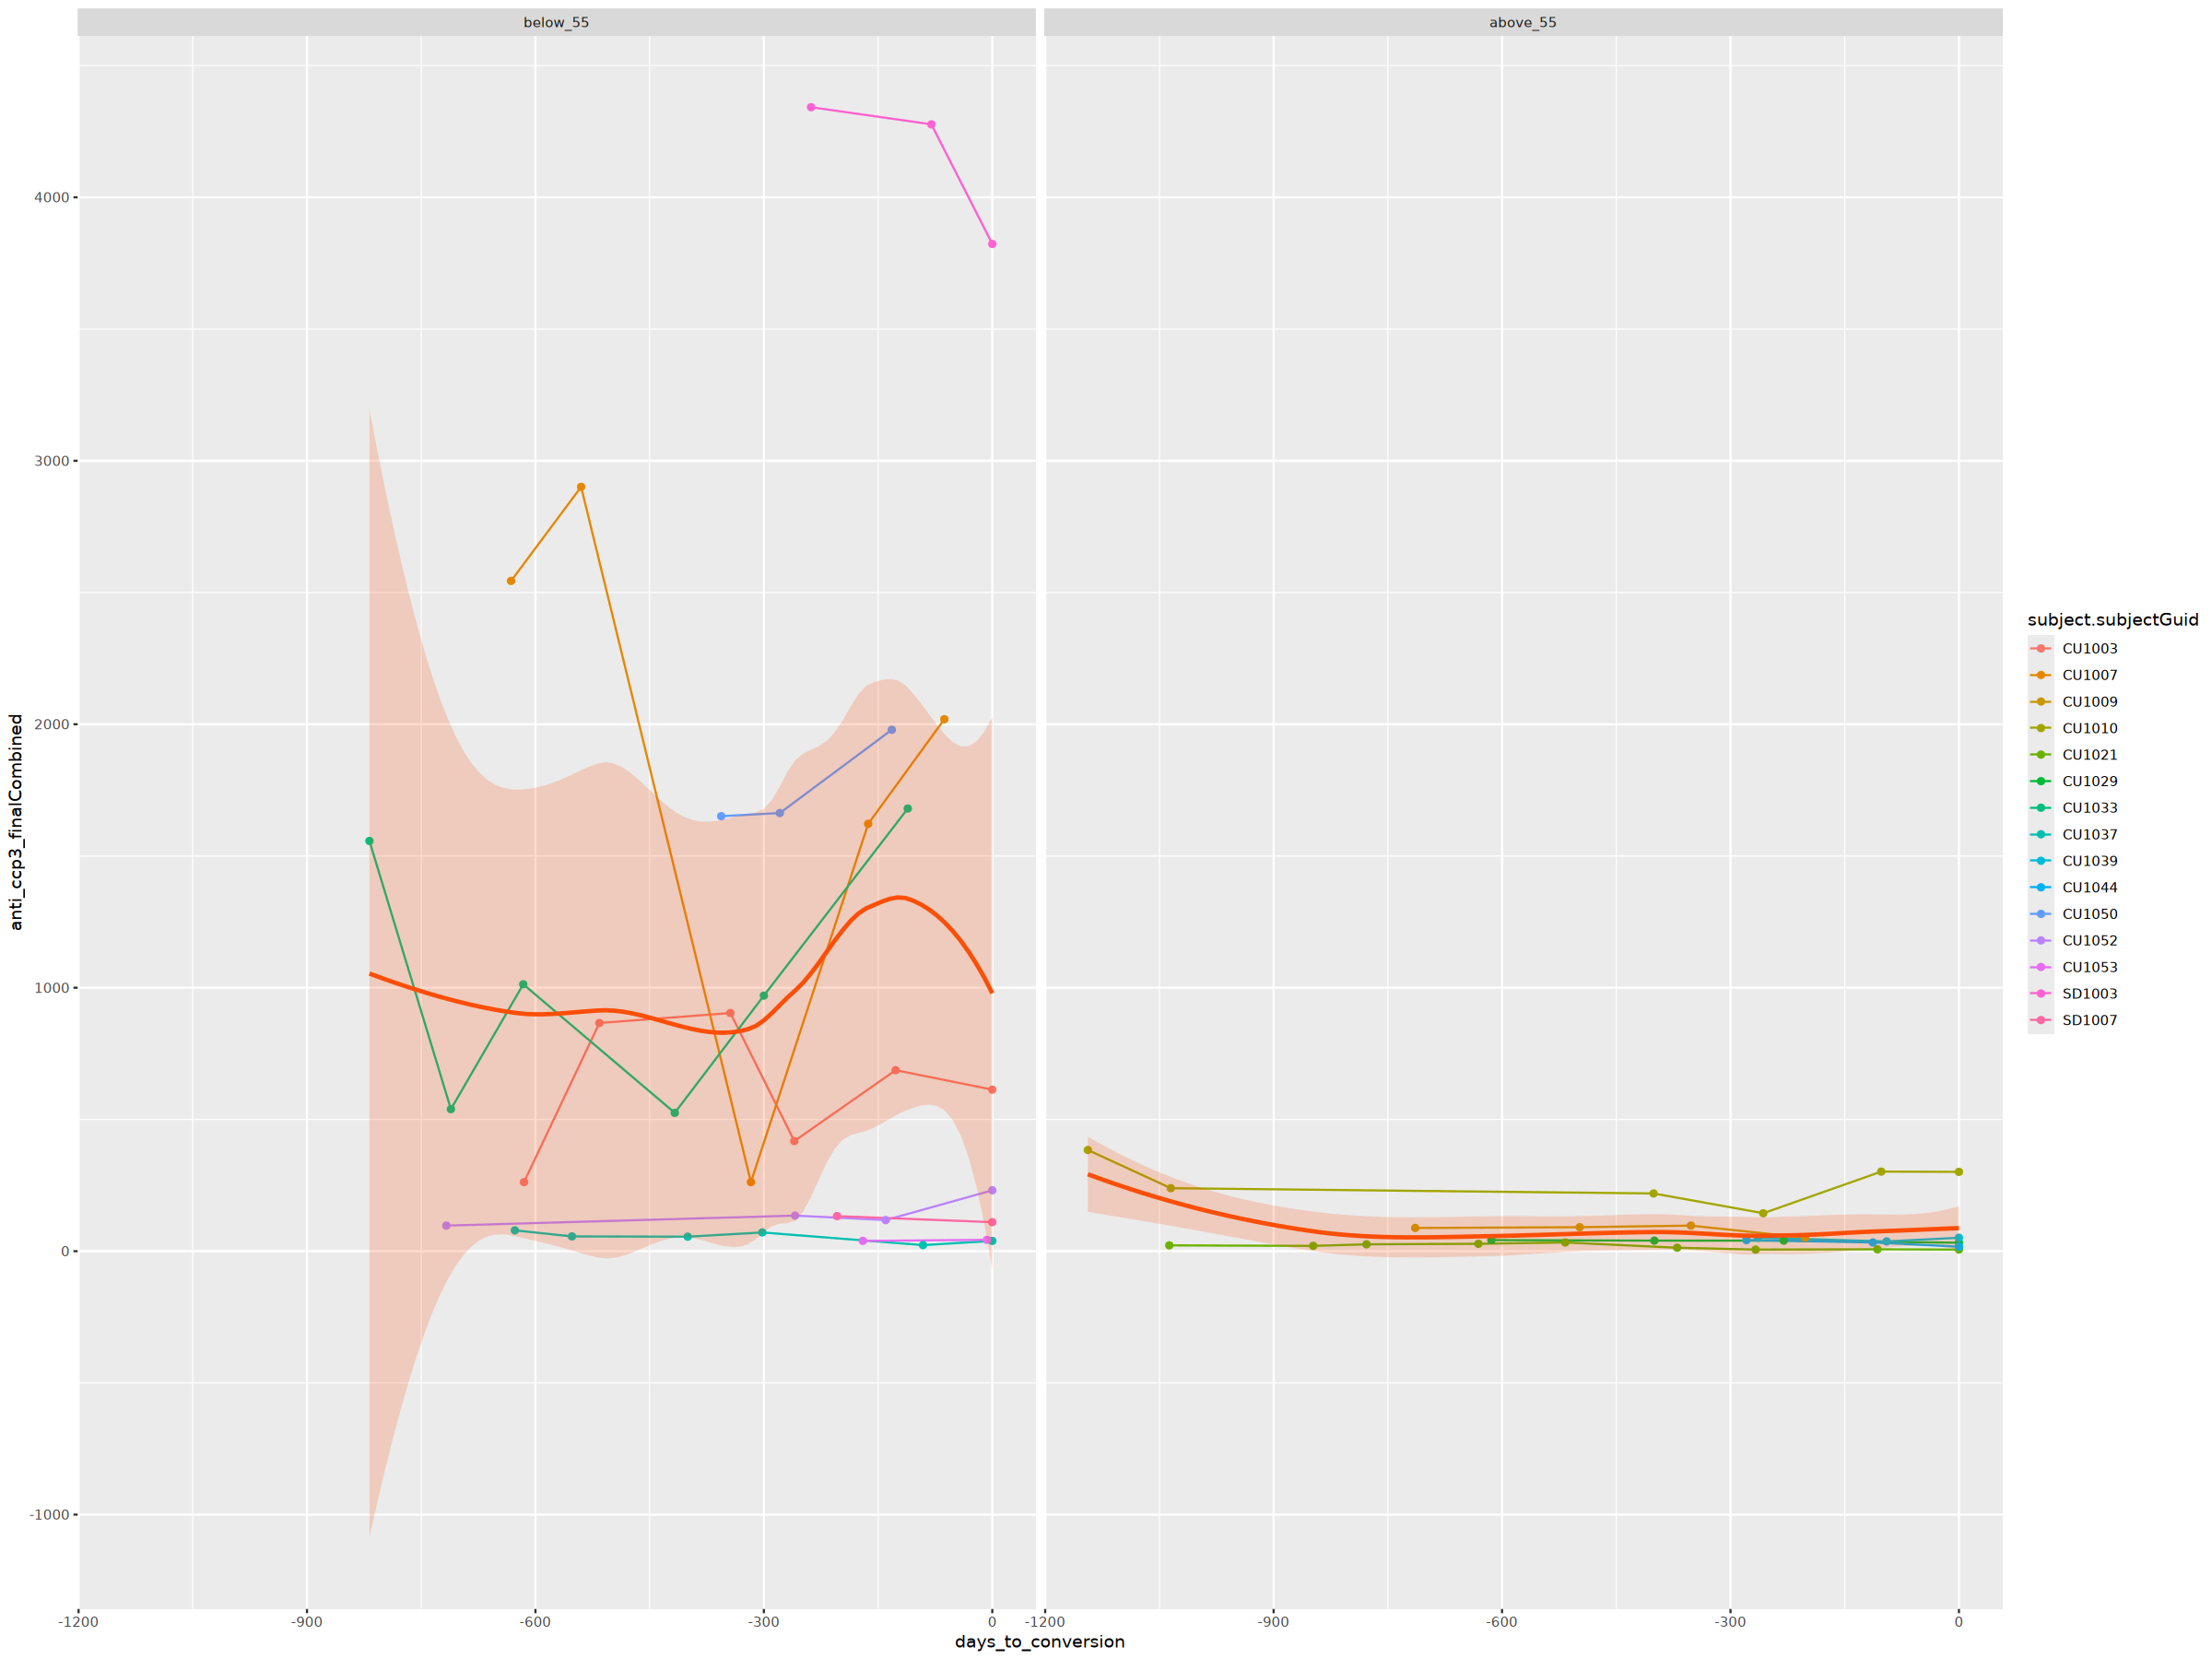

In [41]:
# plot other autoabs
p1 <- aim3_lab %>%filter(!is.na(anti_ccp3_finalCombined))%>% 
    ggplot(aes(x=days_to_conversion, anti_ccp3_finalCombined, color=subject.subjectGuid)) +
    geom_line() + geom_point()+ 
    stat_smooth(
      color = "#FC4E07", fill = "#FC4E07",
      method = "loess", alpha=0.2
      )
p1
ggsave(file.path(fig_path, 'ALTRA_RA_Aim3_ccp3_group_trend.png'), width =6, height=4)
p2 <- aim3_lab %>%filter(!is.na(anti_ccp3_finalCombined))%>% 
    ggplot(aes(x=days_to_conversion, anti_ccp3_finalCombined, color=subject.subjectGuid)) +
    geom_line() + geom_point()+ 
    stat_smooth(
      color = "#FC4E07", fill = "#FC4E07",
      method = "loess", alpha=0.2
      ) + facet_wrap(vars(subject.biologicalSex))
p2
ggsave(file.path(fig_path, 'ALTRA_RA_Aim3_ccp3_sex.png'), width =8, height=4)

p3 <- aim3_lab %>%filter(!is.na(anti_ccp3_finalCombined))%>% 
    ggplot(aes(x=days_to_conversion, anti_ccp3_finalCombined, color=subject.subjectGuid)) +
    geom_line() + geom_point()+ 
    stat_smooth(
      color = "#FC4E07", fill = "#FC4E07",
      method = "loess", alpha=0.2
      ) + facet_wrap(vars(age_bin))
p3
ggsave(file.path(fig_path, 'ALTRA_RA_Aim3_ccp3_age_bin.png'), width =8, height=4)


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


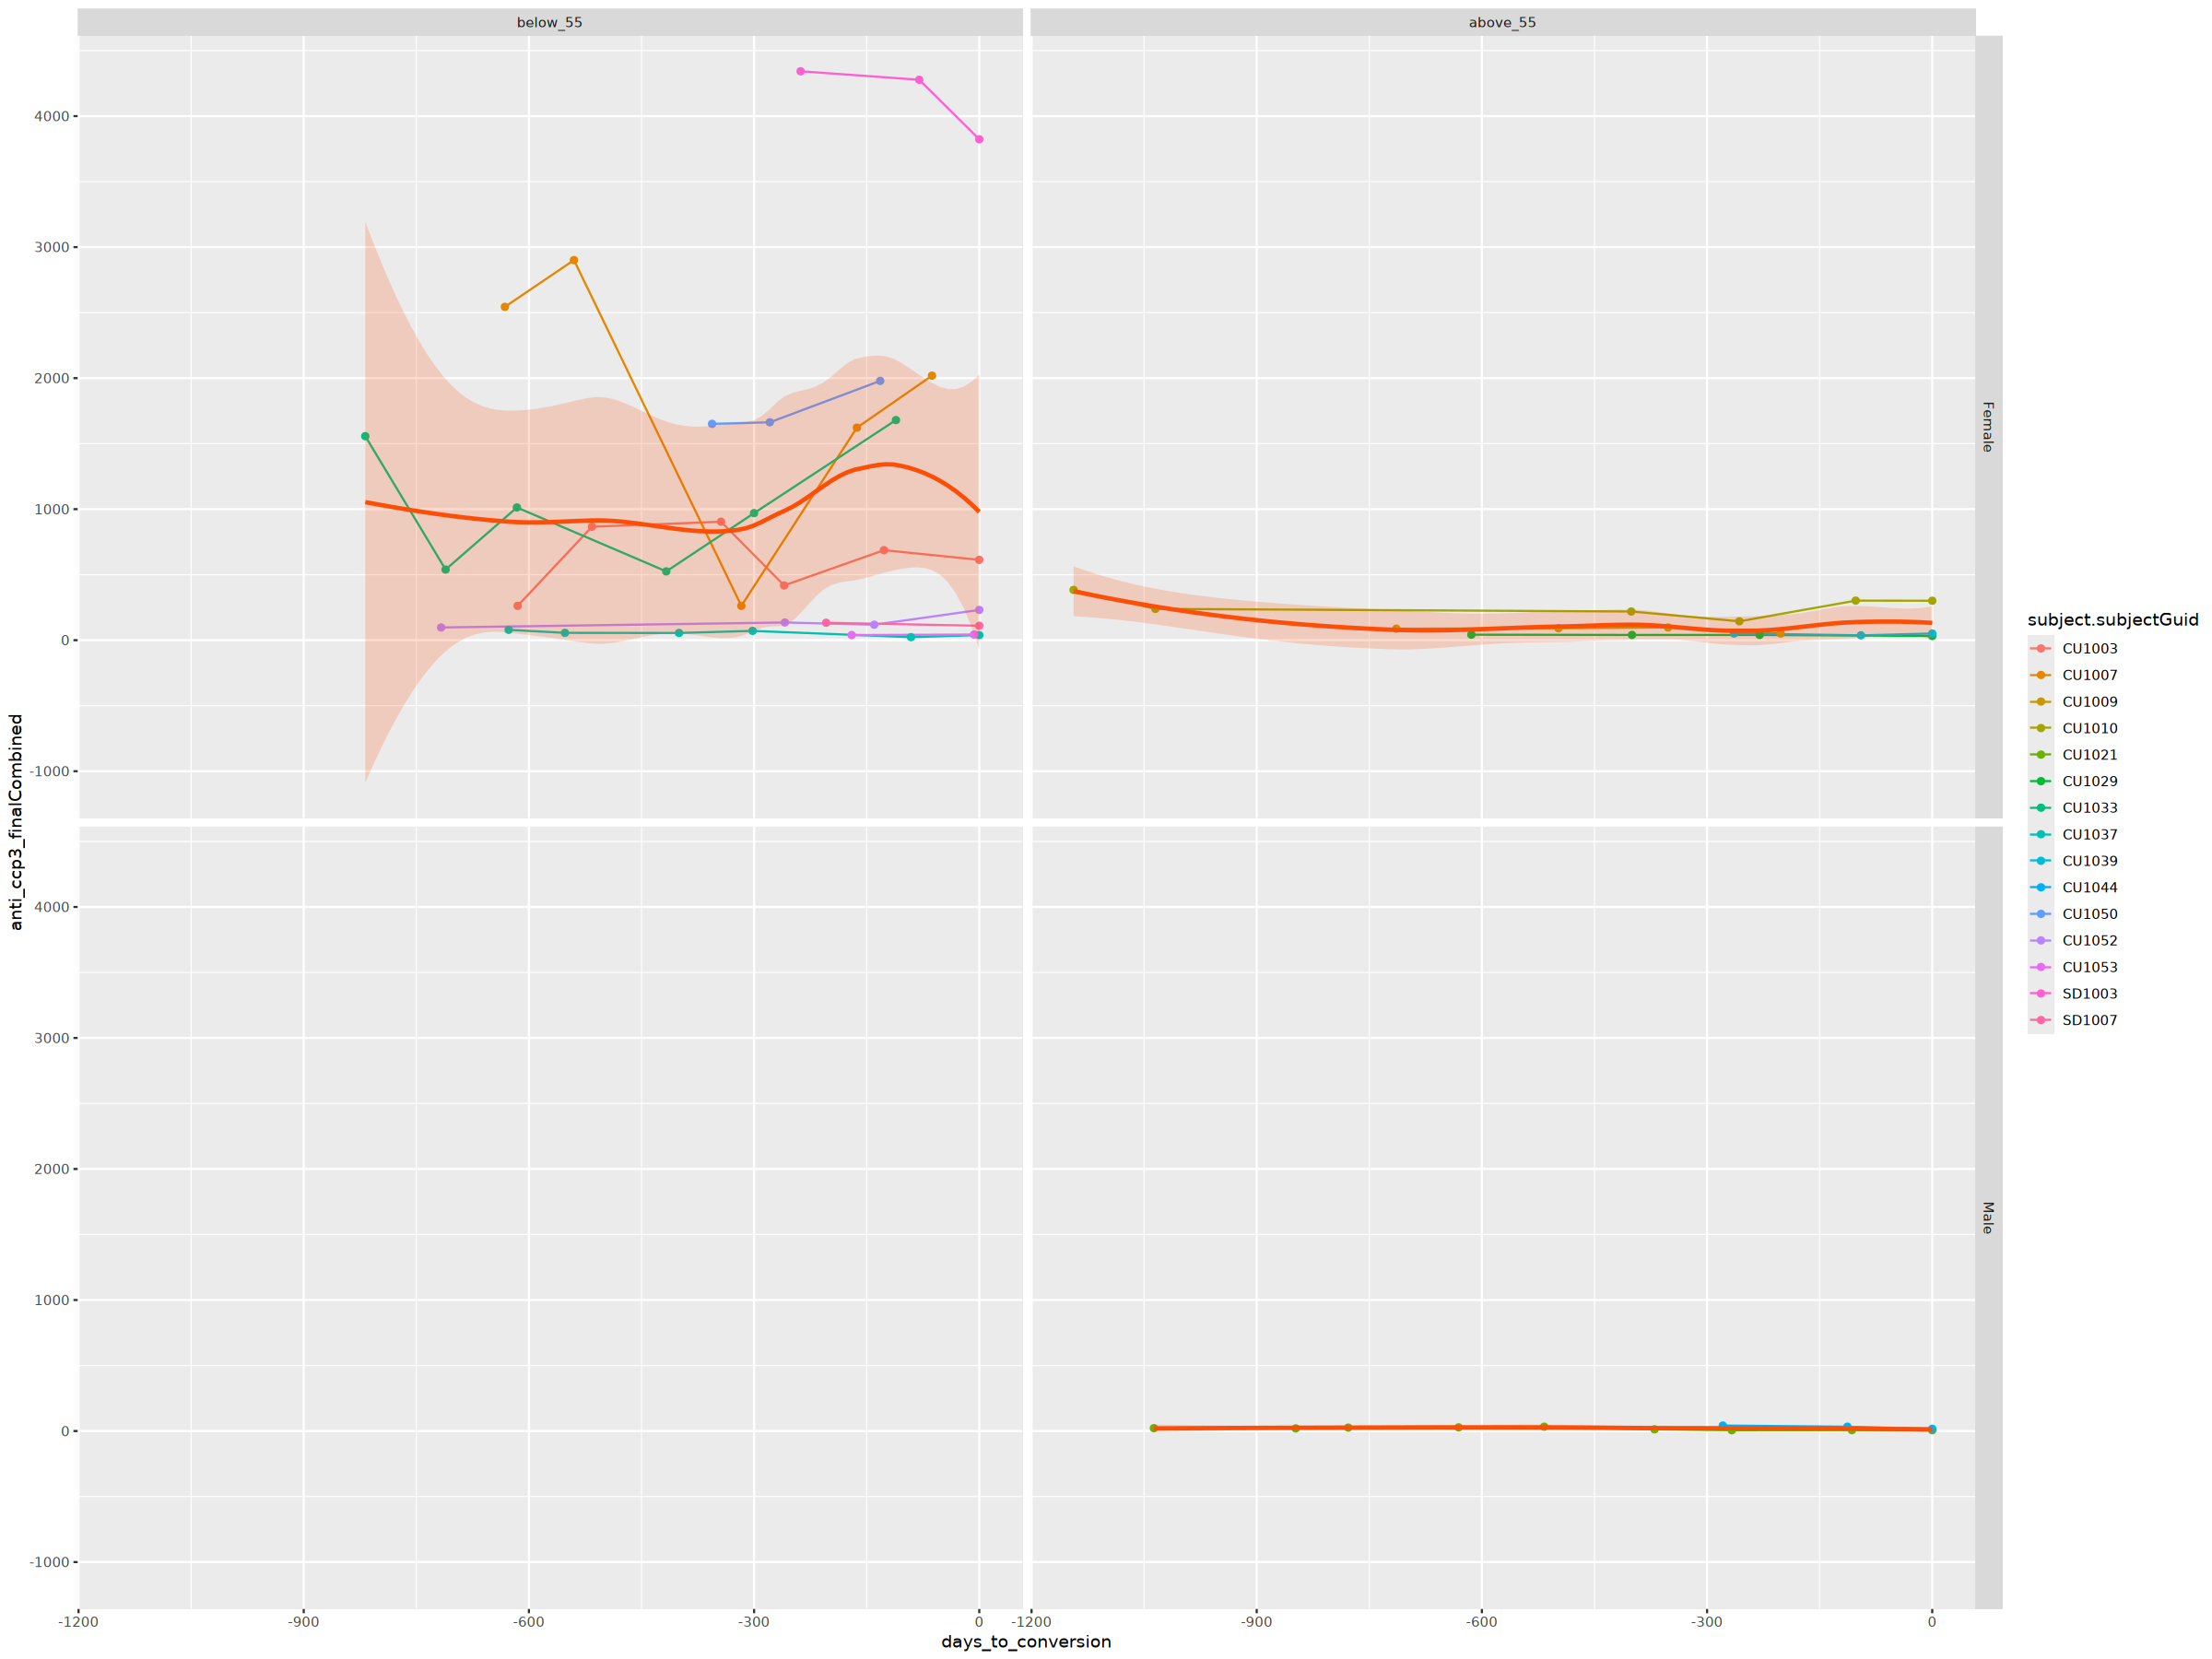

In [42]:
p2 <- aim3_lab %>%filter(!is.na(anti_ccp3_finalCombined))%>% 
    ggplot(aes(x=days_to_conversion, anti_ccp3_finalCombined, color=subject.subjectGuid)) +
    geom_line() + geom_point()+ 
    stat_smooth(
      color = "#FC4E07", fill = "#FC4E07",
      method = "loess", alpha=0.2
      ) + 
     facet_grid(rows=vars(subject.biologicalSex), cols=vars(age_bin)) 
p2
ggsave(file.path(fig_path, 'ALTRA_RA_Aim3_ccp3_age_sex.png'), width =6, height=4)


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


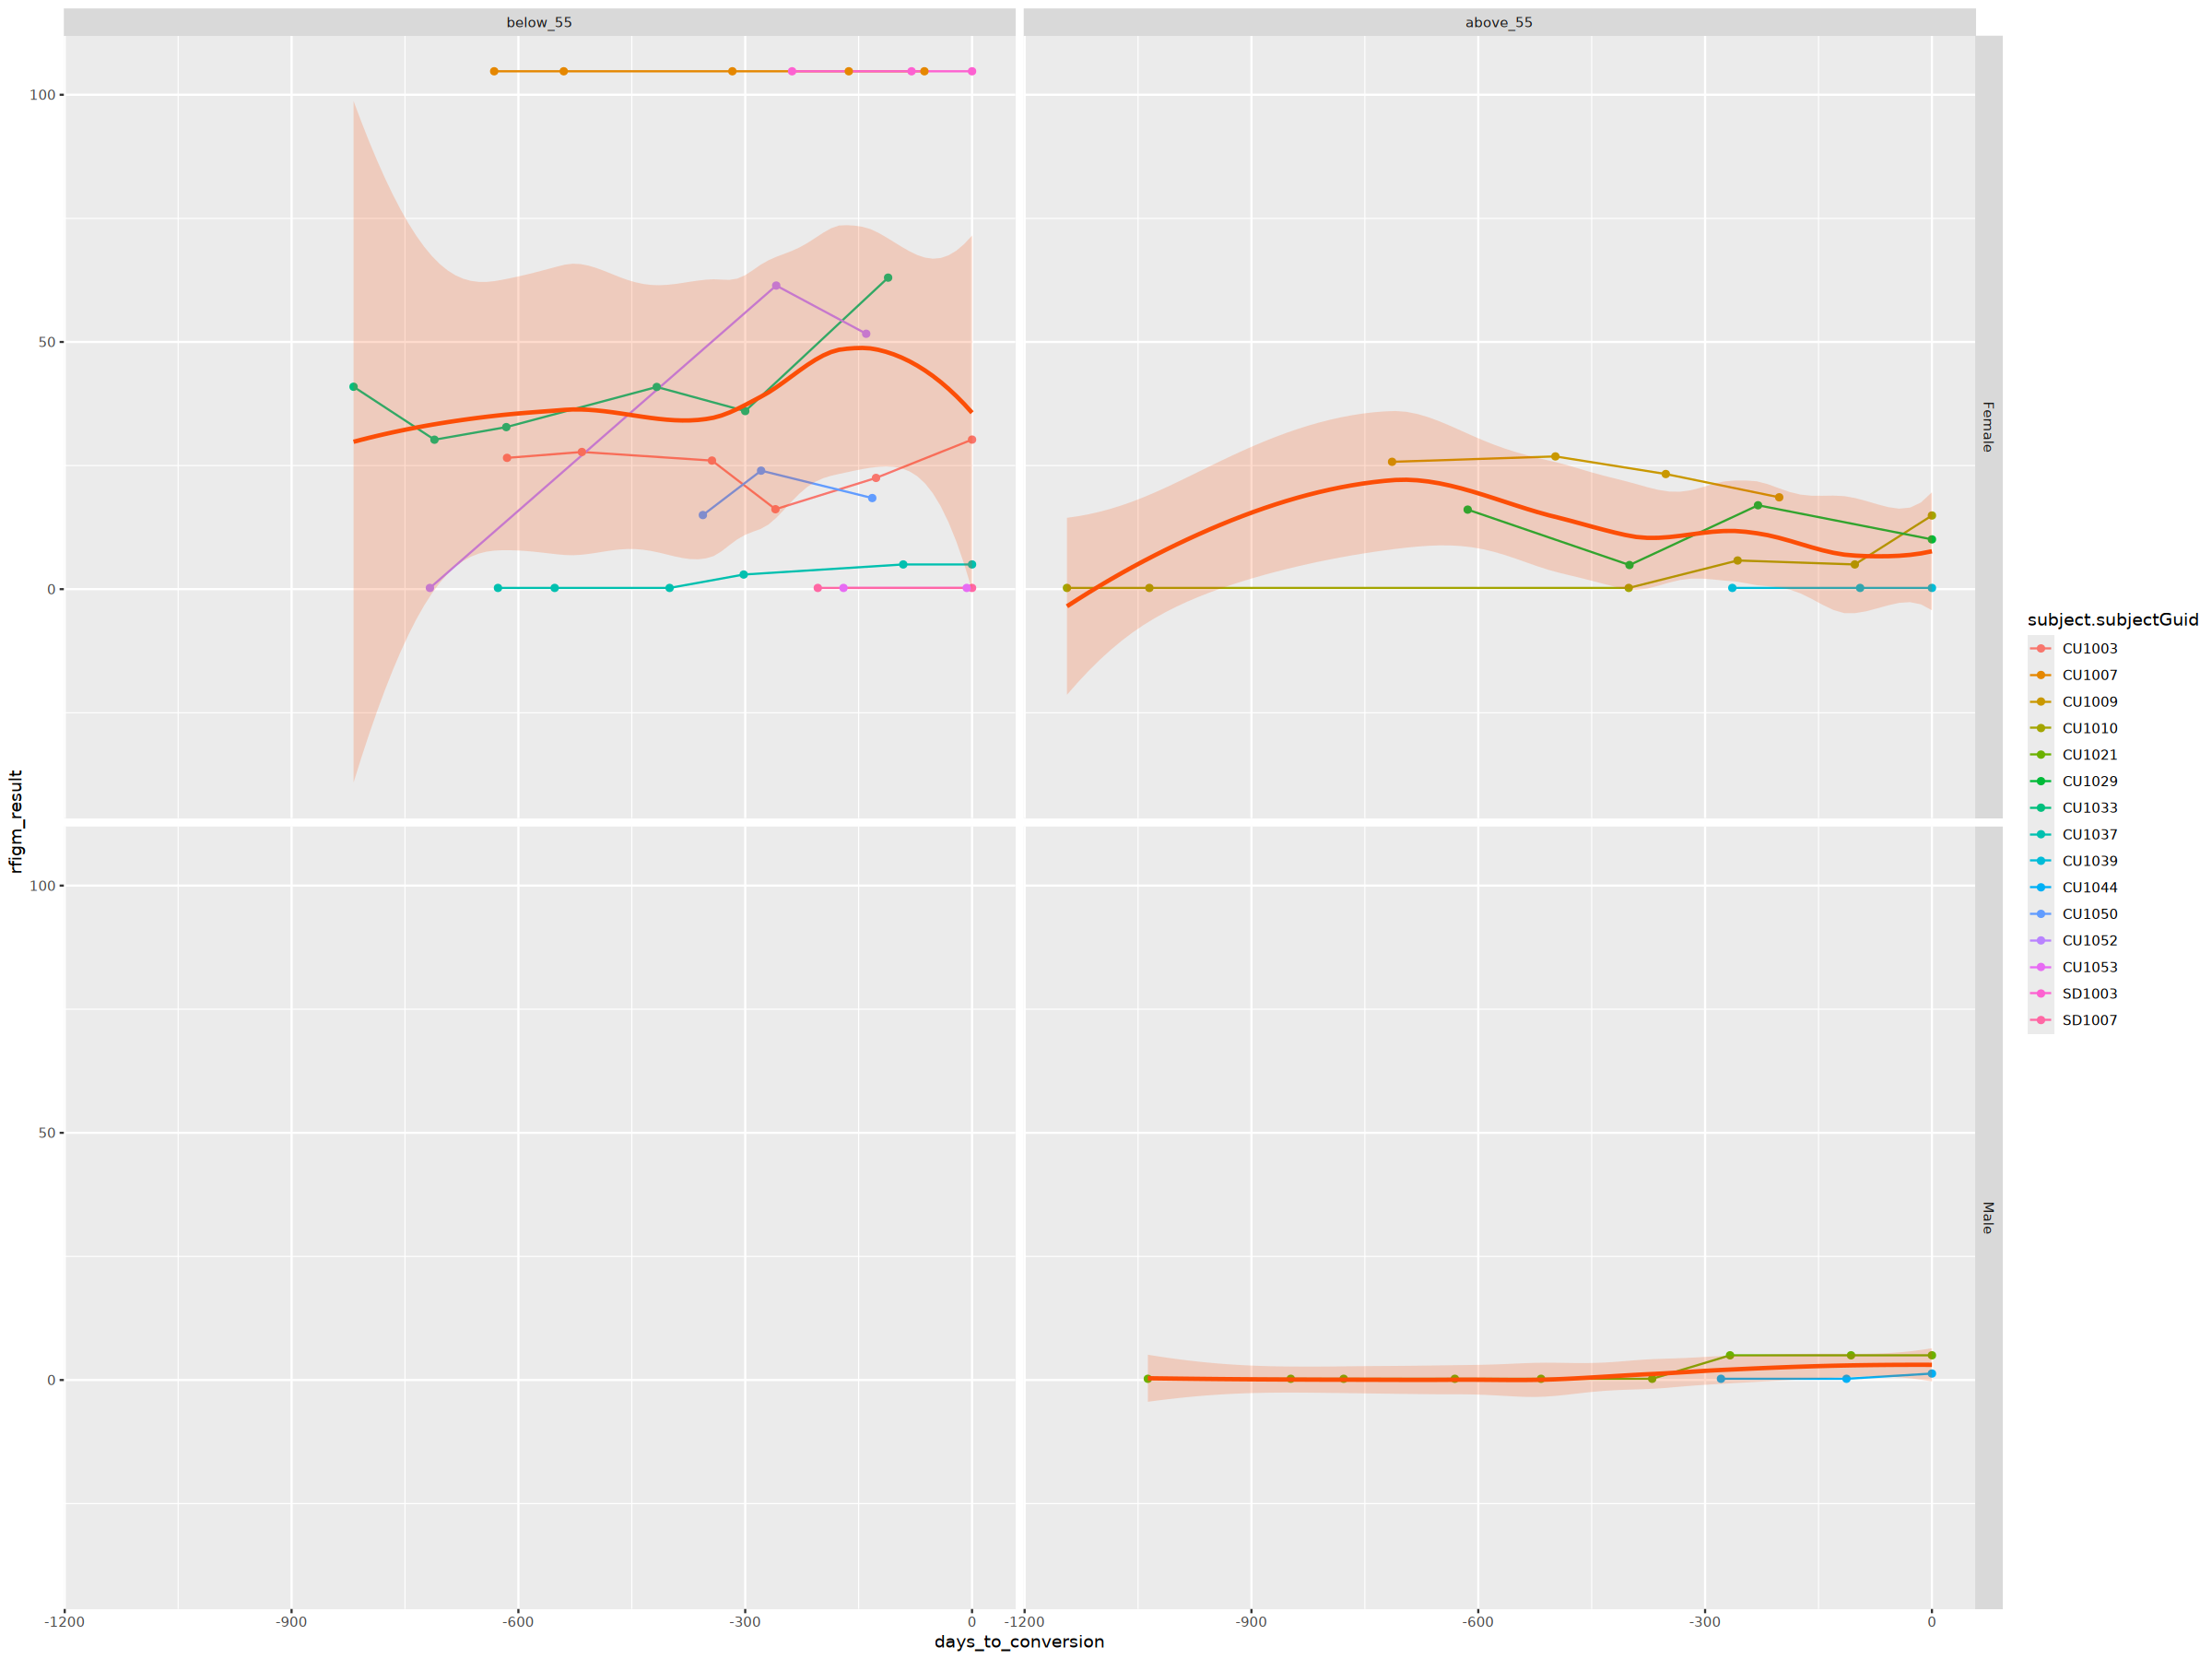

In [43]:
p1 <- aim3_lab %>%filter(!is.na(rfigm_result))%>% 
    ggplot(aes(x=days_to_conversion, rfigm_result, color=subject.subjectGuid)) +
    geom_line() + geom_point()+ 
    stat_smooth(
      color = "#FC4E07", fill = "#FC4E07",
      method = "loess", alpha=0.2
      )

p2 <- aim3_lab %>%filter(!is.na(rfigm_result))%>% 
    ggplot(aes(x=days_to_conversion, rfigm_result, color=subject.subjectGuid)) +
    geom_line() + geom_point()+ 
    stat_smooth(
      color = "#FC4E07", fill = "#FC4E07",
      method = "loess", alpha=0.2
      ) + facet_grid(rows=vars(subject.biologicalSex), cols=vars(age_bin))
p2
ggsave(file.path(fig_path, 'ALTRA_RA_Aim3_rfigm_age_sex.png'), width =6, height=4)

# p3 <- aim3_lab %>%filter(!is.na(rfigm_result))%>% 
#     ggplot(aes(x=days_to_conversion, rfigm_result, color=subject.subjectGuid)) +
#     geom_line() + geom_point()+ 
#     stat_smooth(
#       color = "#FC4E07", fill = "#FC4E07",
#       method = "loess", alpha=0.2
#       ) + facet_wrap(vars(age_bin))
# cowplot::plot_grid(p1, p2, p3, )
# ggsave(file.path(fig_path, 'ALTRA_RA_Aim3_rfigm_bin.png'), width =8, height=4)


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


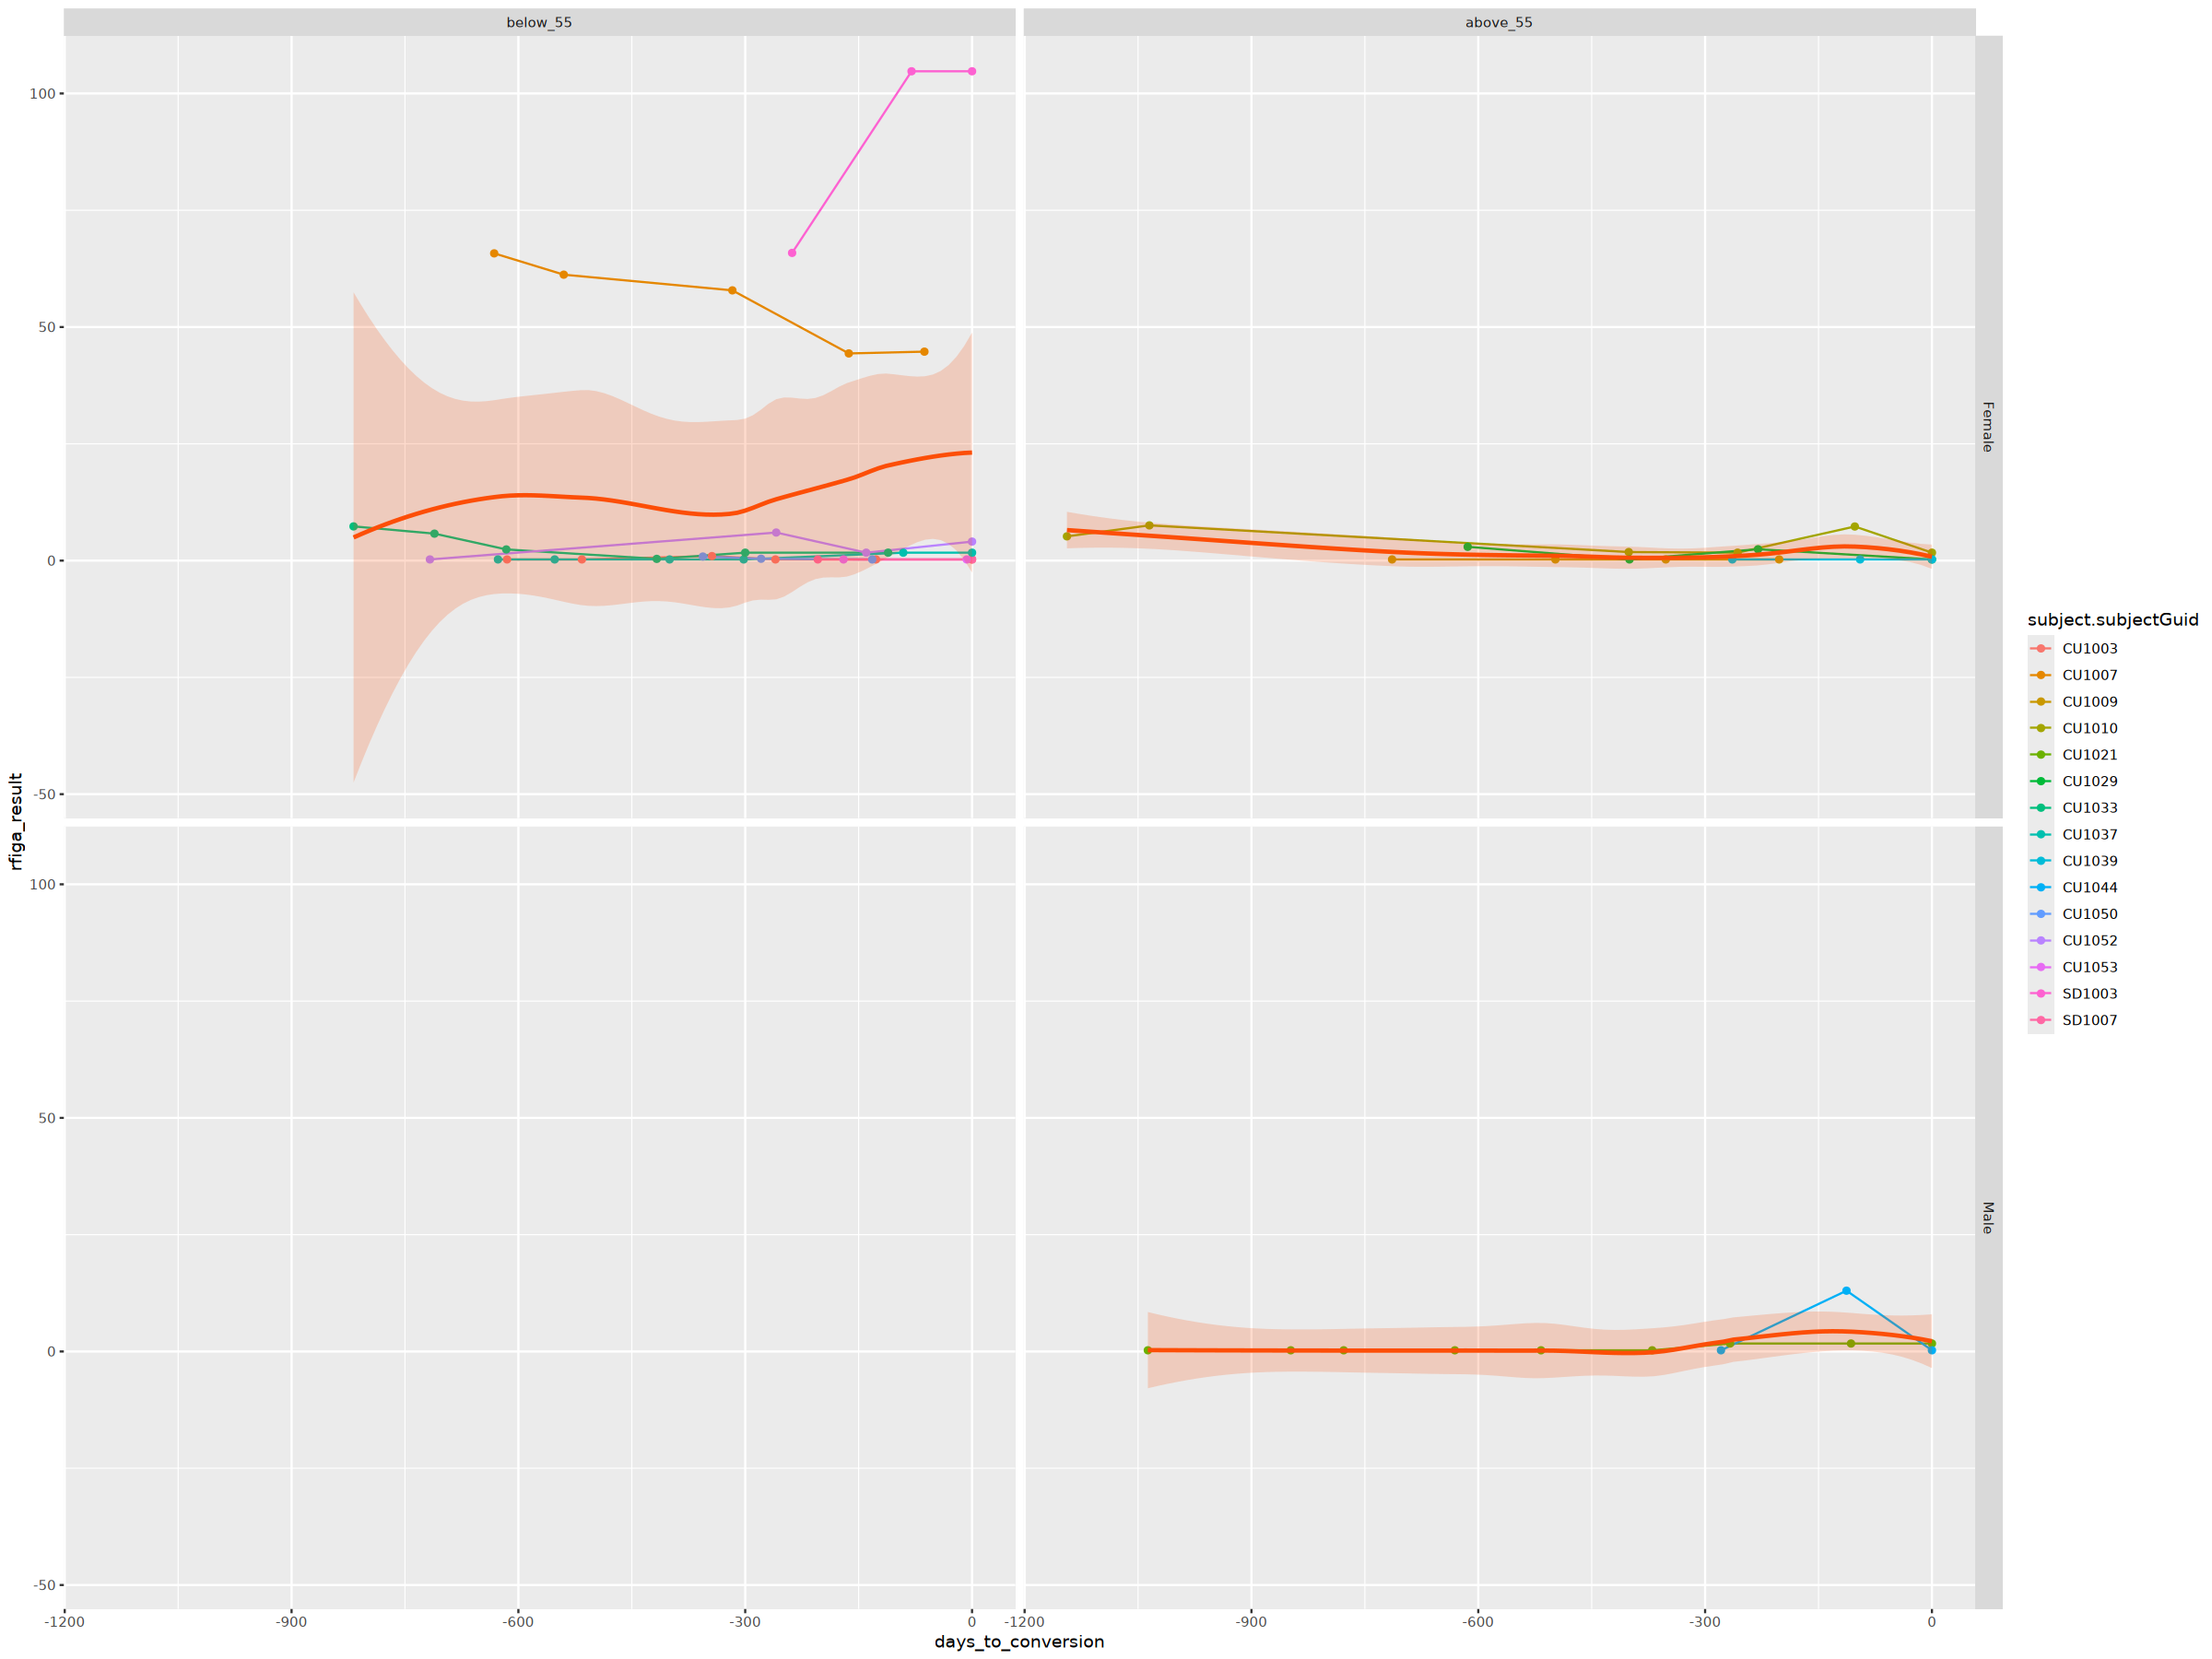

In [44]:
p2 <- aim3_lab %>%filter(!is.na(rfiga_result))%>% 
    ggplot(aes(x=days_to_conversion, rfiga_result, color=subject.subjectGuid)) +
    geom_line() + geom_point()+ 
    stat_smooth(
      color = "#FC4E07", fill = "#FC4E07",
      method = "loess", alpha=0.2
      ) + facet_grid(rows=vars(subject.biologicalSex), cols=vars(age_bin))
p2
ggsave(file.path(fig_path, 'ALTRA_RA_Aim3_rfiga_age_sex.png'), width =6, height=4)


## examine clincal labs

In [45]:
# filter the clinical labs
aim3_lab_fl<-aim3_lab%>%
    select(matches('days_to_conversion|subject.subjectGuid|subject.biologicalSex|age_bin|sample.sampleKitGuid')|
           where(is.numeric)
           )
aim3_lab_fl%>%colnames()

[1] "sample.sampleKitGuid"                                          
 [2] "subject.subjectGuid"                                           
 [3] "subject.biologicalSex"                                         
 [4] "days_to_conversion"                                            
 [5] "age_bin"                                                       
 [6] "sample.daysSinceFirstVisit"                                    
 [7] "subject.birthYear"                                             
 [8] "Age2023"                                                       
 [9] "ageAtDraw"                                                     
[10] "timeOnStudy"                                                   
[11] "percent_basophils"                                             
[12] "percent_eosinophils"                                           
[13] "percent_immature_granulocytes"                                 
[14] "percent_lymphocytes"                                           
[15] "percent_monocytes"                                             
[16] "percent_nucleated_red_blood_cells_nrbc"                        
[17] "0401_count"                                                    
[18] "0404_count"                                                    
[19] "0405_count"                                                    
[20] "0408_count"                                                    
[21] "absolute_basophil_count"                                       
[22] "absolute_eosinophil_count_aec"                                 
[23] "absolute_immature_granulocyte_count"                           
[24] "absolute_lymphocyte_count_alc"                                 
[25] "absolute_monocyte_count_amc"                                   
[26] "absolute_neutrophil_count_anc"                                 
[27] "alanine_transaminase_alt"                                      
[28] "albumin"                                                       
[29] "alkaline_phosphatase"                                          
[30] "anion_gap"                                                     
[31] "anti_ccp3"                                                     
[32] "anti_ccp31"                                                    
[33] "bilirubin_total_t_bili"                                        
[34] "c_reactive_protein_crp"                                        
[35] "calcium"                                                       
[36] "carbon_dioxide_co2"                                            
[37] "cholesterol_hdl"                                               
[38] "cholesterol_ldl"                                               
[39] "cholesterol_total"                                             
[40] "creatinine"                                                    
[41] "estimated_glomerular_filtration_rate_egfr_non_african_american"
[42] "glucose"                                                       
[43] "height"                                                        
[44] "hematocrit"                                                    
[45] "hip_size"                                                      
[46] "mean_corpuscular_hemoglobin_mch"                               
[47] "mean_corpuscular_hemoglobin_concentration_mchc"                
[48] "mean_corpuscular_volume_mcv"                                   
[49] "nucleated_red_blood_cell_nrbc_count"                           
[50] "number_of_days_to_from_initial_covid_19_vaccine"               
[51] "number_of_days_to_from_second_covid_19_vaccine"                
[52] "platelet_count"                                                
[53] "protein_total"                                                 
[54] "rfiga_result"                                                  
[55] "rfigm_result"                                                  
[56] "red_blood_cell_count"                                          
[57] "se_count"                                                      
[58] "sed_r

In [47]:
# select lab to test
lab_to_test = c('white_blood_cell_count_wbc','absolute_basophil_count', 'absolute_eosinophil_count_aec', 
                'absolute_immature_granulocyte_count','sodium','triglycerides', 
                'absolute_lymphocyte_count_alc', 'absolute_monocyte_count_amc', 'absolute_neutrophil_count_anc', 
                'red_blood_cell_count', 'sed_rate_westergren_esr', 
                'alanine_transaminase_alt', 'albumin', 'alkaline_phosphatase','anion_gap',
                'c_reactive_protein_crp', 'cholesterol_hdl','cholesterol_ldl',
                'cholesterol_total', 'platelet_count','protein_total')
aim3_lab_long<-aim3_lab_fl%>%pivot_longer(cols = all_of(lab_to_test), names_to = 'feature', values_to = 'value')

In [39]:
# run linear mixed model for time to conversion 
lab_lme <- function(lab_table, formula, feature_test){
    message(paste('running', feature_test))
    lme_res <- tidy(lmer(as.formula(formula), data=lab_table)) %>%
        mutate(lab_feature=feature_test)
    return(lme_res)
}
formula_linear1 <- as.formula("value ~ age_conv + bmi_conv + days_to_conversion + 
    (1 | subject.subjectGuid)")
lab_stats_lme<- aim3_lab_long %>% filter(days_to_conversion>= (-750) & 
    subject.biologicalSex=='Female') %>% 
    group_by(feature)%>%
    group_modify(~lab_lme(.x, formula=formula_linear1, 
                           feature_test=.y$feature))

running absolute_basophil_count

running absolute_eosinophil_count_aec

running absolute_immature_granulocyte_count

running absolute_lymphocyte_count_alc

running absolute_monocyte_count_amc

running absolute_neutrophil_count_anc

running alanine_transaminase_alt

running albumin

running alkaline_phosphatase

running anion_gap

running c_reactive_protein_crp

running cholesterol_hdl

running cholesterol_ldl

running cholesterol_total

running platelet_count

running protein_total

running red_blood_cell_count

running sed_rate_westergren_esr

running sodium

running triglycerides

running white_blood_cell_count_wbc



In [40]:
lab_stats_lme_sig <- lab_stats_lme %>% filter(term=='days_to_conversion') %>%
    ungroup() %>% rstatix::adjust_pvalue(p.col = 'p.value', method = 'BH')%>% arrange(p.value)
lab_stats_lme_sig

feature,effect,group,term,estimate,std.error,statistic,df,p.value,lab_feature,p.value.adj
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
platelet_count,fixed,NA,days_to_conversion,0.0730591056,0.0241732184,3.02231603,37.11153,0.004527883,platelet_count,0.09508555
albumin,fixed,NA,days_to_conversion,-0.0003351551,0.0001517440,-2.20868823,41.60135,0.032760516,albumin,0.34398542
absolute_eosinophil_count_aec,fixed,NA,days_to_conversion,0.1150505417,0.0648117052,1.77515067,39.44953,0.083589069,absolute_eosinophil_count_aec,0.58512348
absolute_basophil_count,fixed,NA,days_to_conversion,0.0234818954,0.0204927479,1.14586367,37.83197,0.259048163,absolute_basophil_count,0.93428735
alanine_transaminase_alt,fixed,NA,days_to_conversion,-0.0032415941,0.0031248653,-1.03735481,41.49290,0.305578315,alanine_transaminase_alt,0.93428735
white_blood_cell_count_wbc,fixed,NA,days_to_conversion,0.0007542544,0.0009022128,0.83600502,39.47374,0.408184292,white_blood_cell_count_wbc,0.93428735
protein_total,fixed,NA,days_to_conversion,0.0002180165,0.0002942961,0.74080655,43.36518,0.462803388,protein_total,0.93428735
red_blood_cell_count,fixed,NA,days_to_conversion,-0.0001309745,0.0001896805,-0.69050039,38.08597,0.494066438,red_blood_cell_count,0.93428735
absolute_neutrophil_count_anc,fixed,NA,days_to_conversion,0.5320618210,0.7856410075,0.67723275,41.40943,0.502024502,absolute_neutrophil_count_anc,0.93428735


In [65]:
lab_stats_lme_sig %>%write_csv(file.path(output_path, 'AIM3_clinical_lab_lmer_test.csv'))

# plot Fig S5C

In [45]:
#' Plot a frequency line plot with prediction
#'
#' This function takes a frequency table, a model fit, and various parameters to create a line plot with prediction.
#'
#' @param frequency_table A data frame containing the frequency data.
#' @param model_fit The model fit object.
#' @param palette A vector of colors for the line plot.
#' @param fig_path The file path to save the plot. Default is NULL.
#' @param fig_name The name of the figure Default is NULL.
#' @param x_var The variable for the x-axis. Default is "days_to_conversion".
#' @param y_var The variable for the y-axis. Default is "clr".
#' @param color_var The variable for coloring the lines. Default is "subject.subjectGuid".
#' @param shape_var The variable for shaping the points. Default is "sex".
#' @param title The title of the plot. Default is "Cluster 9".
#' @param x_label The label for the x-axis. Default is "Days to Conversion".
#' @param y_label The label for the y-axis. Default is "CLR".
#' @param annotation_text The text for the annotation. Default is "p=0.055".
#' @param annotation_x The x-coordinate for the annotation. Default is -600.
#' @param annotation_y The y-coordinate for the annotation. Default is 1.
#' @param annotation_color The color for the annotation. Default is "red".
#'
#' @return The plot object.
#'
#' @examples
#' # Example usage of PlotFreqLinePlot function
#' PlotFreqLinePlot(frequency_table, model_fit, palette, fig_path = "path/to/save", fig_name = "fig_name",
#'                  x_var = "days_to_conversion", y_var = "clr", color_var = "subject.subjectGuid",
#'                  shape_var = "sex", title = "Cluster 9", x_label = "Days to Conversion", 
#'                  y_label = "CLR", annotation_text = "p=0.055", annotation_x = -600, 
#'                  annotation_y = 1, annotation_color = "red")
#'
#' @export
PlotPredLinePlot <- function(model_fit,  fig_path = NULL, fig_name = NULL,
                             x_var = "days_to_conversion", y_var = "clr", color_var = "subject.subjectGuid",
                             shape_var = "sex", title = "Cluster 9", x_label = "Days to Conversion", 
                             y_label = "CLR") {
    require(ggplot2)
    require(ggeffects)
    
    # Extract the prediction data frame
    
    pred.mm <- ggpredict(model_fit, terms = c(x_var))  # Adjusted to use x_var
    fit_data <- model_fit@frame 
    # plot
    p1 <- fit_data %>%
        ggplot() +
        geom_line(aes(x = .data[[x_var]], y = .data[[y_var]], group=.data[[color_var]]), color = 'grey', size = 1) + 
        geom_point(aes(x = .data[[x_var]], y = .data[[y_var]]), color = 'black', fill = 'grey', shape=1) + 
        geom_line(data=pred.mm, aes(x = x, y = predicted), color="#de2d26", size = 1.2) +          
        geom_ribbon(data=pred.mm, aes(x = x, ymin = predicted - std.error, ymax = predicted + std.error), 
                    fill = "#fee0d2", alpha = 0.6, size = 1.2) + 

        labs(title = title) + xlab(x_label) +  ylab(y_label)+
        scale_color_subj() + ggpubr::theme_pubr() +
        scale_shape_manual(values = c(1, 2))  + guides(color = FALSE)
    
    # Code to save the plot if fig_path and proj_name are provided
        # Check if fig_path and proj_name are provided and not empty
    if (!missing(fig_path) && !missing(fig_name) && nzchar(fig_path) && nzchar(fig_name)) {
        # Construct the full file path with the project name and desired file extension
        file_name <- paste0(fig_path, "/", fig_name)
        # Use ggsave to save the plot
        ggsave(file_name, plot = p1, width = 4, height = 4, dpi = 300)
    }
    return(p1)
}

In [118]:
# model platelet_count
formula_linear1 <- as.formula("value ~ age_conv + bmi_conv + days_to_conversion + 
    (1 | subject.subjectGuid)")
platelet_data = aim3_lab_long %>% filter(days_to_conversion>= (-750) & 
    subject.biologicalSex=='Female' & feature=='platelet_count')
platelet_model = lmer(formula_linear1, data=platelet_data)

In [1]:
# model platelet_count
formula_linear1 <- as.formula("value ~ age_conv + bmi_conv + days_to_conversion + 
    (1 | subject.subjectGuid)")
platelet_data = aim3_lab_long %>% filter(days_to_conversion>= (-750) & 
    subject.biologicalSex=='Female' & feature=='c_reactive_protein_crp')
platelet_model = lmer(formula_linear1, data=platelet_data)

ERROR: Error in aim3_lab_long %>% filter(days_to_conversion >= (-750) & subject.biologicalSex == : could not find function "%>%"


In [119]:
platelet_model %>% summary()

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: formula_linear1
   Data: platelet_data

REML criterion at convergence: 512.1

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-2.15813 -0.65989 -0.05238  0.46814  2.64378 

Random effects:
 Groups              Name        Variance Std.Dev.
 subject.subjectGuid (Intercept) 6170     78.55   
 Residual                         940     30.66   
Number of obs: 50, groups:  subject.subjectGuid, 13

Fixed effects:
                    Estimate Std. Error        df t value Pr(>|t|)   
(Intercept)        319.81665  127.94958   9.80906   2.500  0.03189 * 
age_conv            -1.45830    1.75194   9.80517  -0.832  0.42500   
bmi_conv             2.89064    4.15991   9.77422   0.695  0.50331   
days_to_conversion   0.07306    0.02417  37.11153   3.022  0.00453 **
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Correlation of Fixed Effects:
            (Intr) ag_cnv bm_c

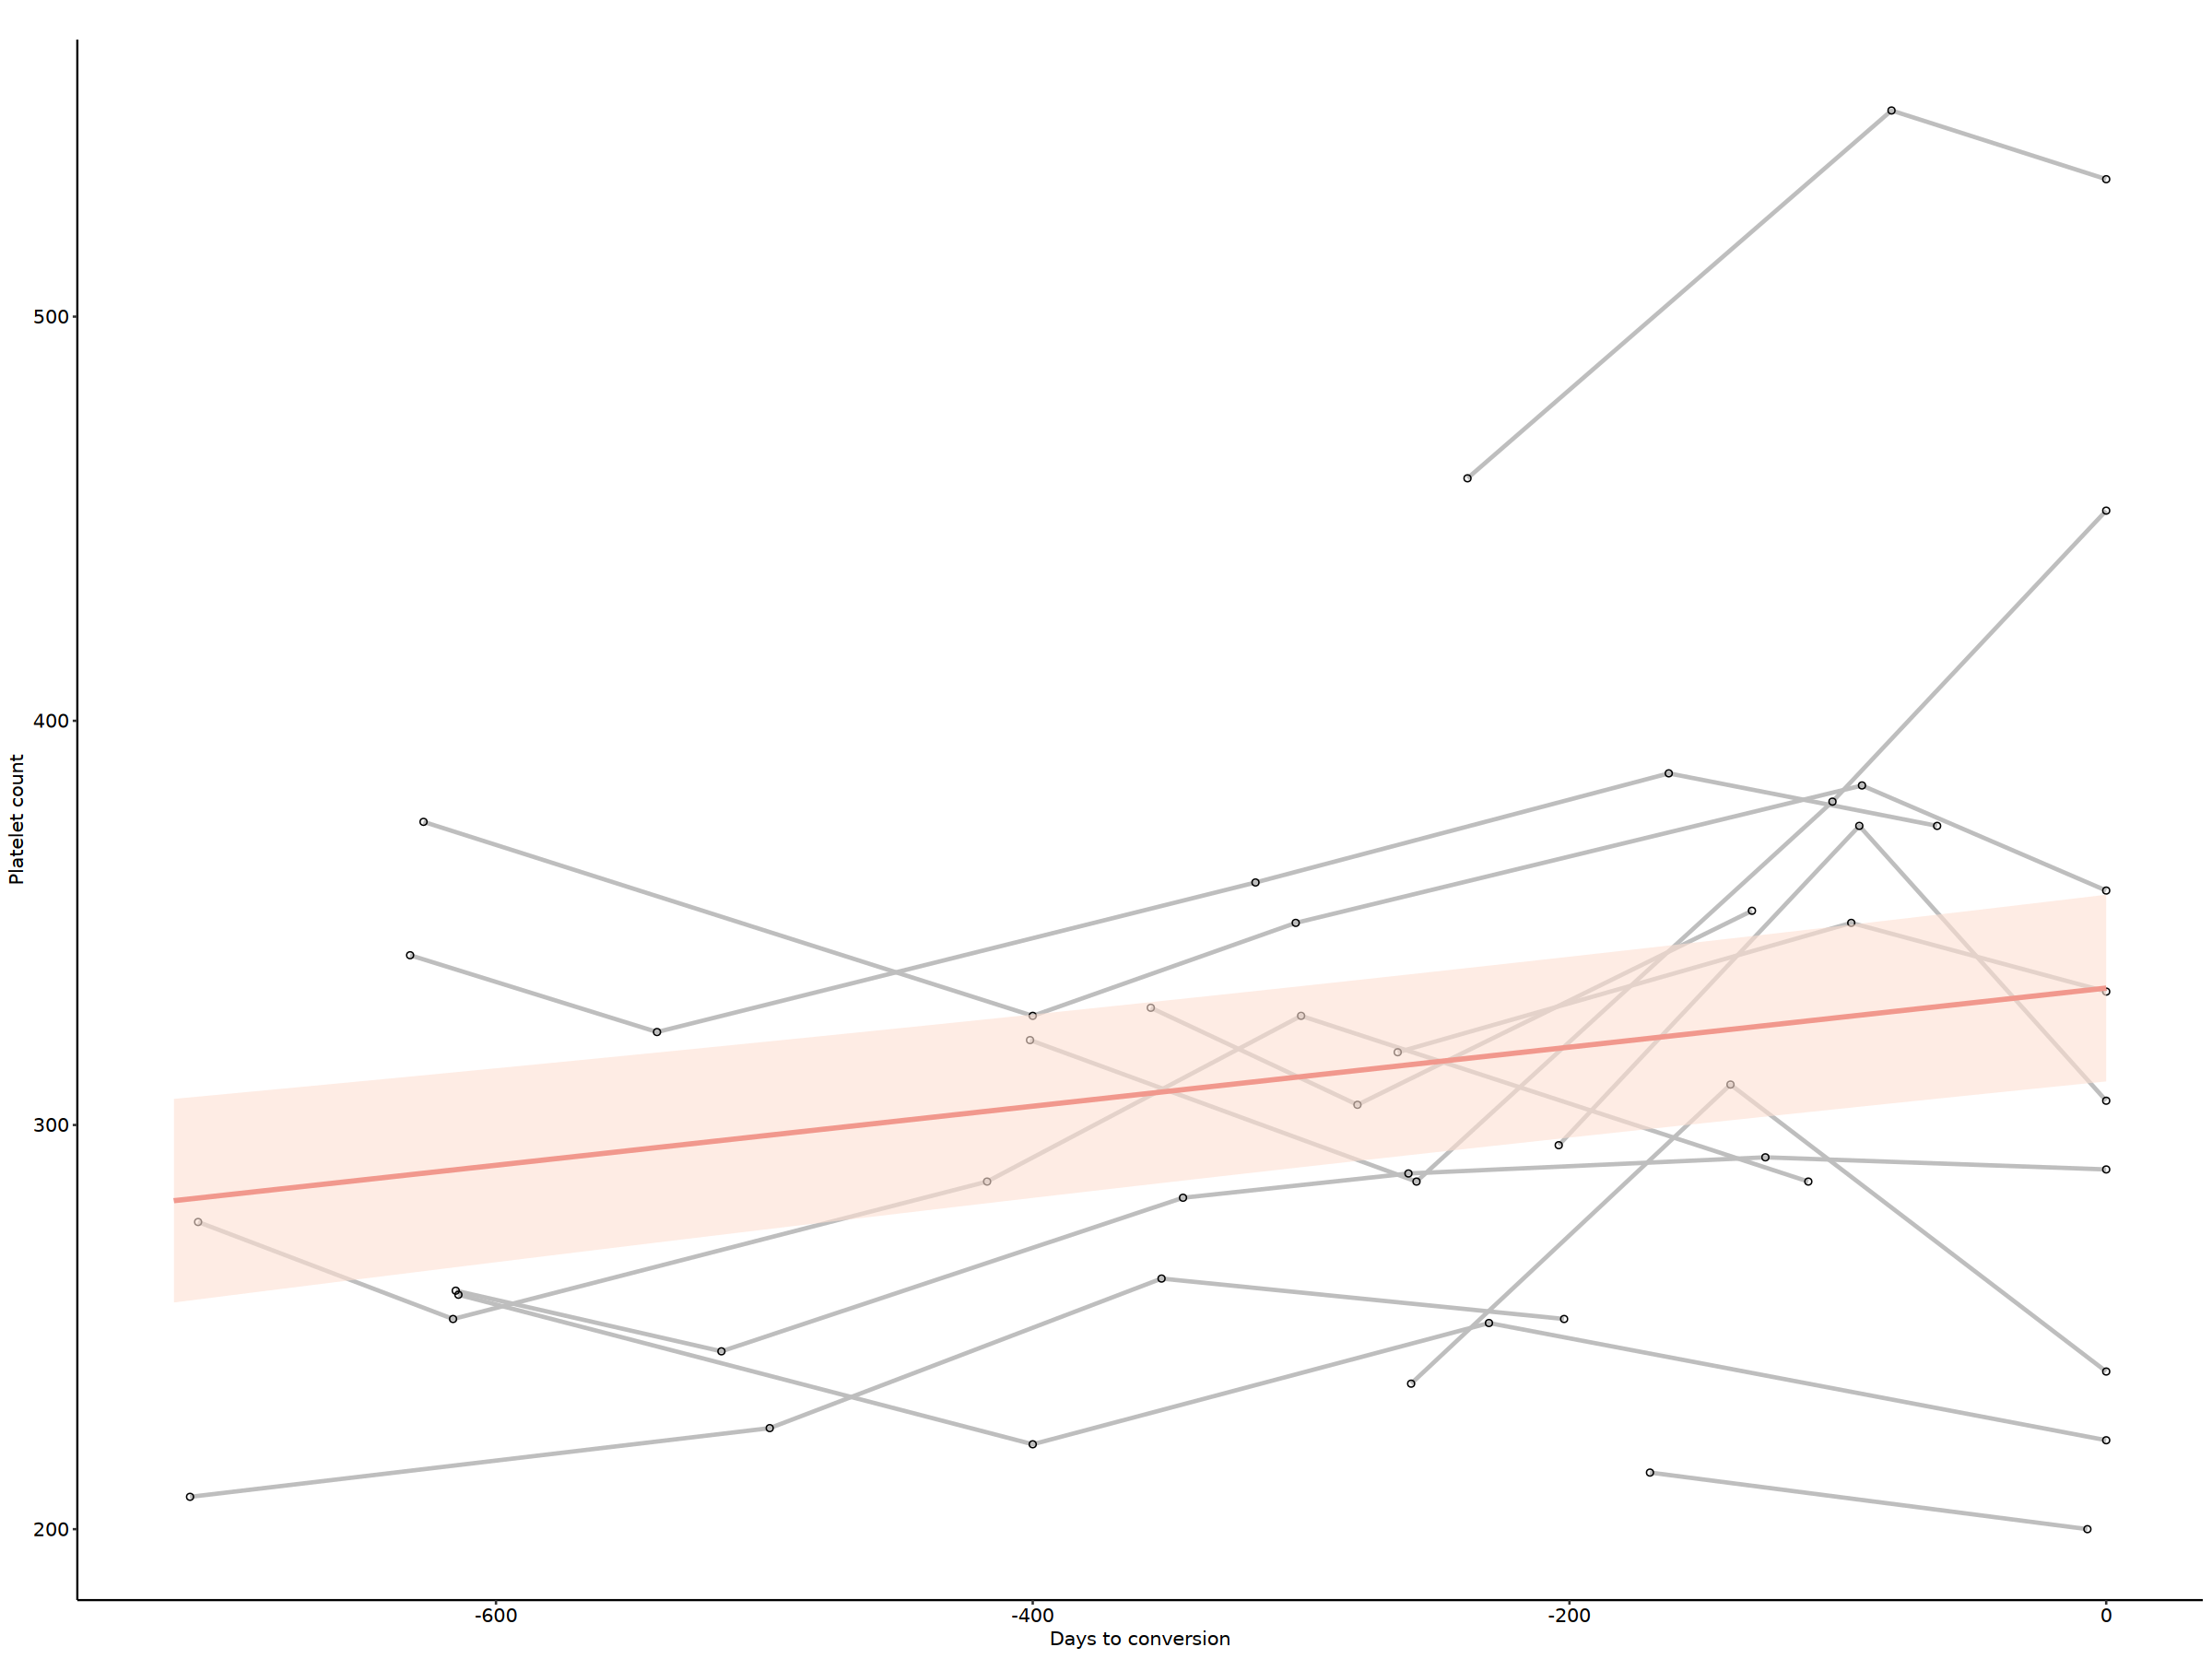

In [121]:
PlotPredLinePlot(platelet_model, x_var = 'days_to_conversion', y_var = 'value', x_label = "Days to conversion", 
                 fig_path = fig_path, fig_name='ALTRA_AIM3_Platelet_count_lineplot.pdf',
                 y_label = 'Platelet count', title = "")

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 3 rows containing non-finite outside the scale range (`stat_smooth()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_line()`).”
Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_point()`).”
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 3 rows containing non-finite outside the scale range (`stat_smooth()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_line()`).”
Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_point()`).”


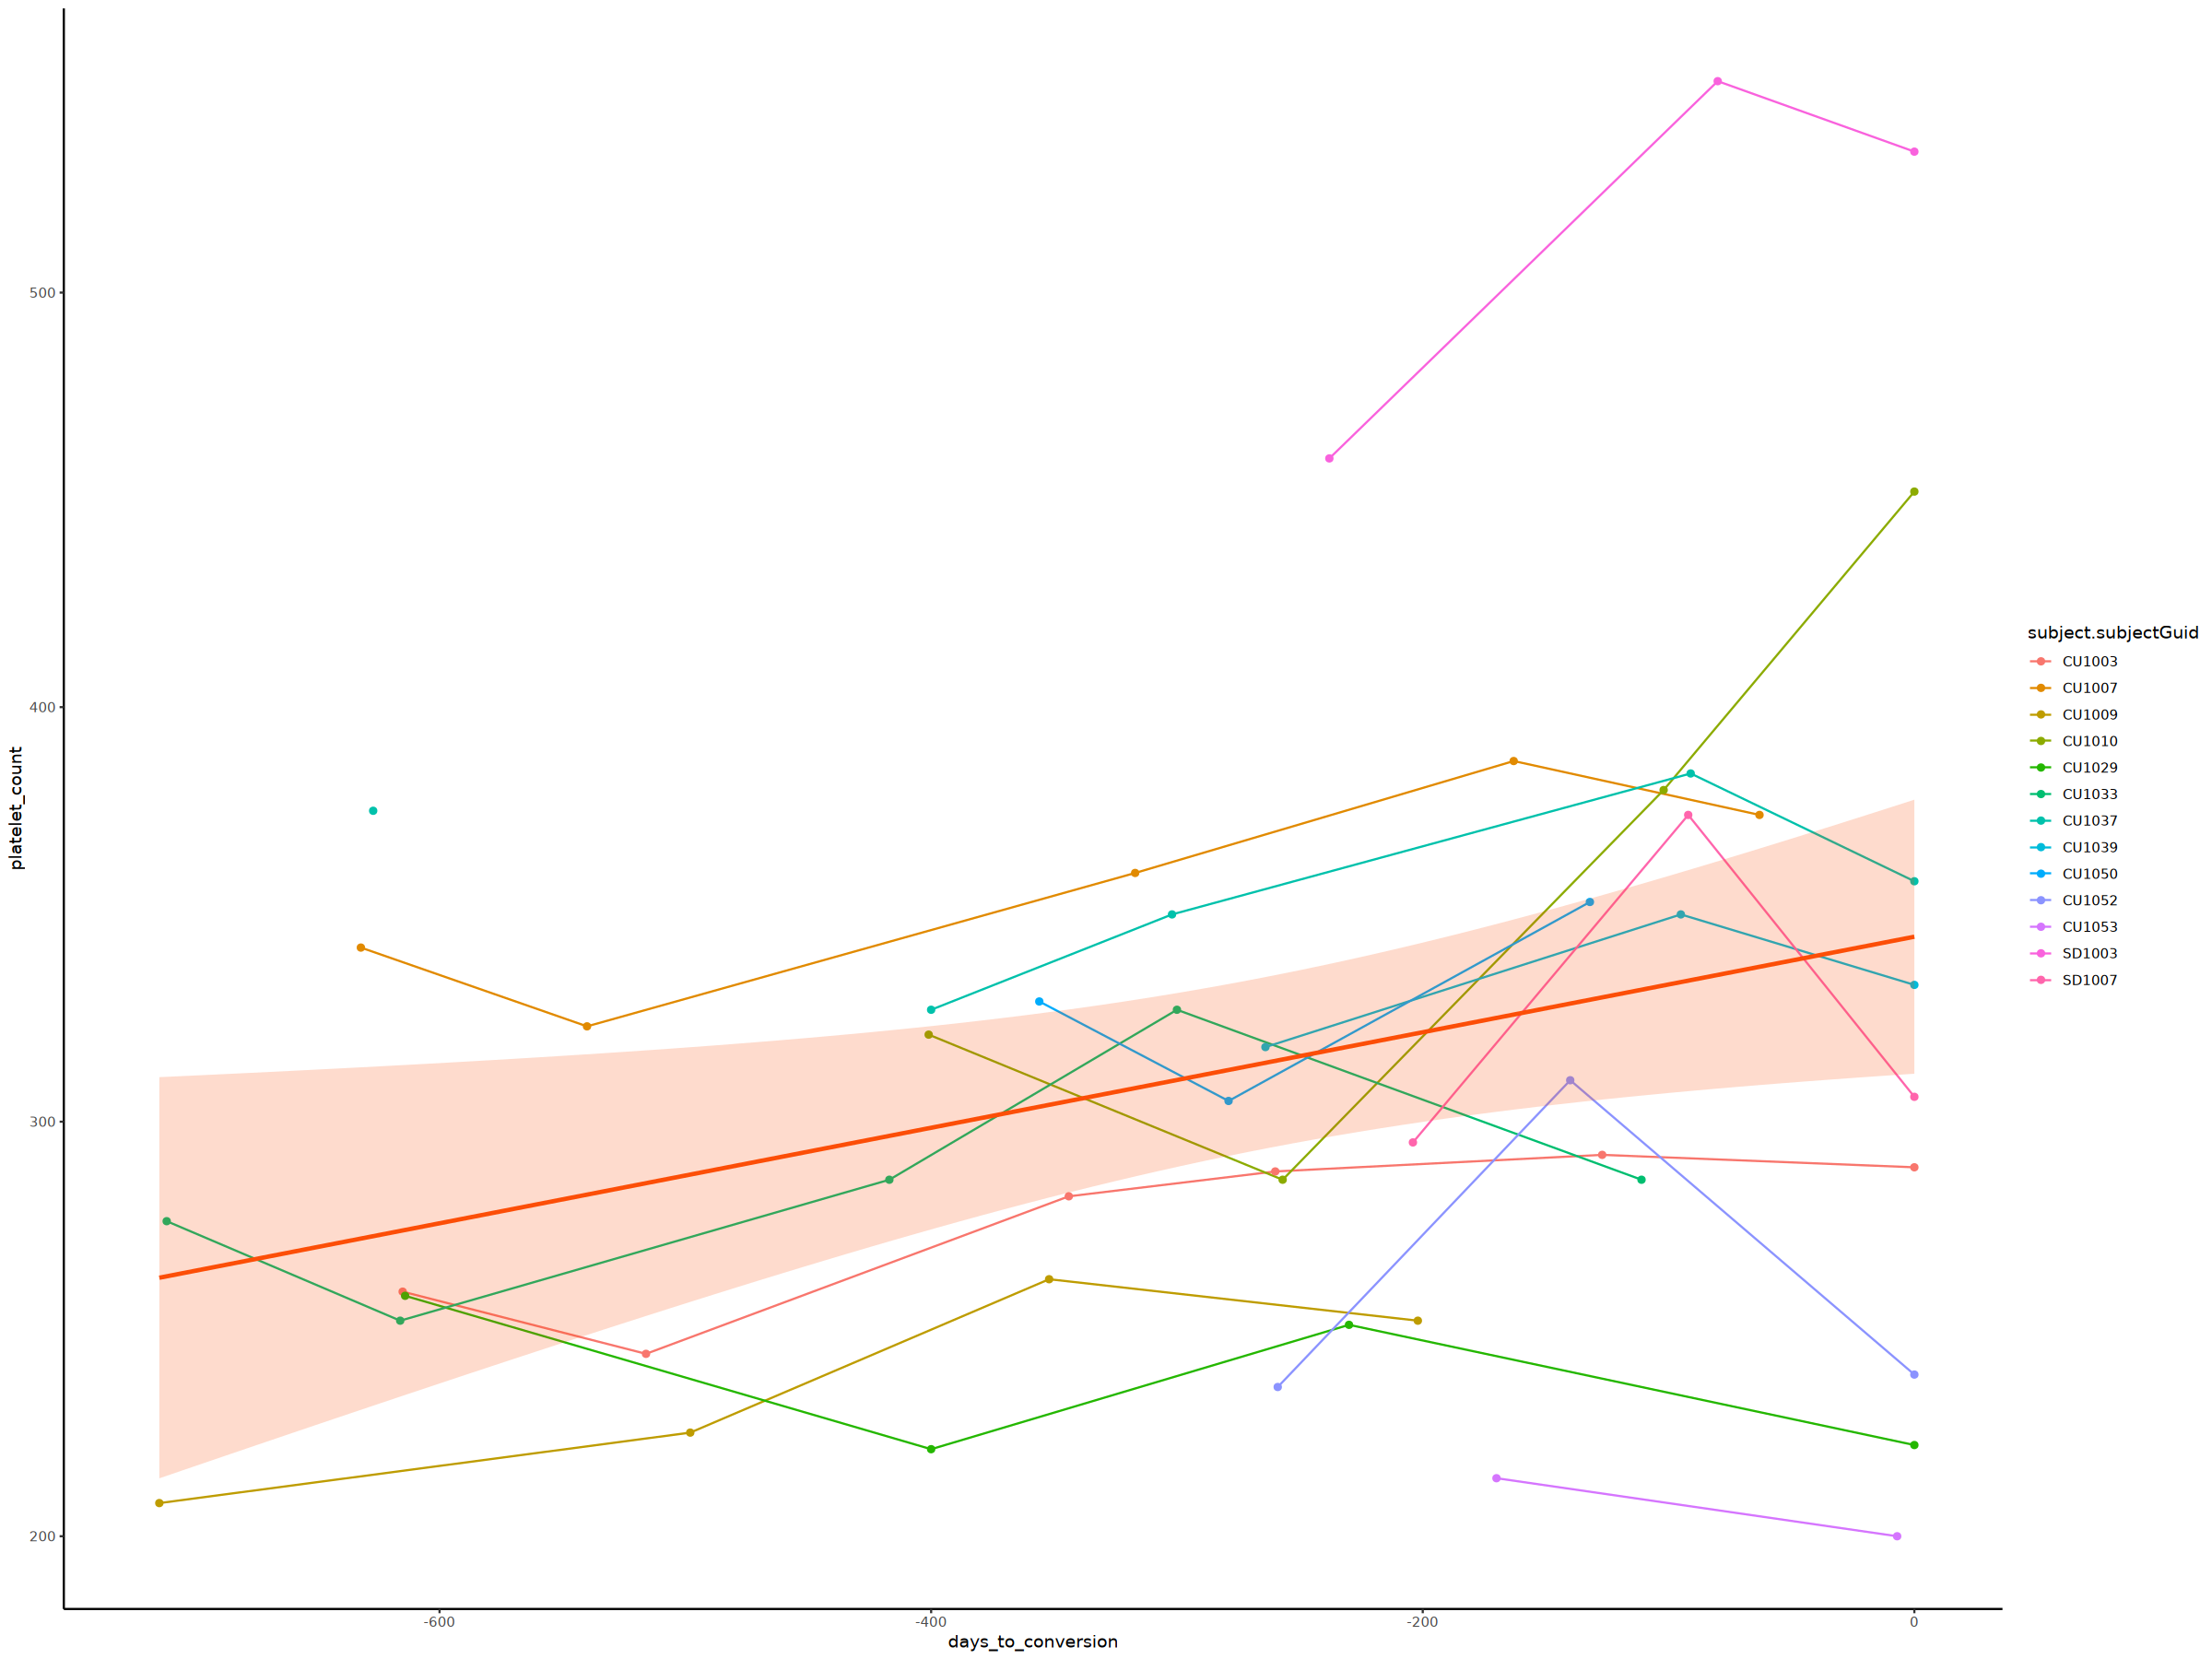

In [69]:
p1 <- aim3_lab %>% filter(days_to_conversion>= (-750) & 
                           subject.biologicalSex=='Female'
                         )%>%
    ggplot(aes(x=days_to_conversion, y=platelet_count, color=subject.subjectGuid)) +
    geom_line() + geom_point() + 
    stat_smooth(
      color = "#FC4E07", fill = "#FC4E07",
      method = "lm", alpha=0.2
      ) + theme_classic()

p1
ggsave(file.path(fig_path, 'ALTRA_RA_Aim3_platelet_count.png'), 
       width =4, height=4)


### check esr and crp

In [43]:
# model platelet_count
formula_linear1 <- as.formula("value ~ age_conv + bmi_conv + days_to_conversion + 
    (1 | subject.subjectGuid)")
lab_sub_data = aim3_lab_long %>% filter(days_to_conversion>= (-750) & 
    subject.biologicalSex=='Female' & feature=='c_reactive_protein_crp')
lm_model = lmer(formula_linear1, data=lab_sub_data)
summary(lm_model)

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: formula_linear1
   Data: lab_sub_data

REML criterion at convergence: 308

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-1.9725 -0.3135 -0.1123  0.1669  4.5686 

Random effects:
 Groups              Name        Variance Std.Dev.
 subject.subjectGuid (Intercept) 15.12    3.889   
 Residual                        13.91    3.729   
Number of obs: 51, groups:  subject.subjectGuid, 13

Fixed effects:
                     Estimate Std. Error         df t value Pr(>|t|)
(Intercept)         0.9784407  6.9157178  9.3872504   0.141    0.890
age_conv           -0.1280173  0.0948594  9.4624669  -1.350    0.209
bmi_conv            0.3424018  0.2225038  8.9736169   1.539    0.158
days_to_conversion  0.0002176  0.0026225 41.3117469   0.083    0.934

Correlation of Fixed Effects:
            (Intr) ag_cnv bm_cnv
age_conv    -0.440              
bmi_conv    -0.750 -0.231       
dys_t_cnvrs  0.0

Loading required package: ggeffects

Warning message:
“package ‘ggeffects’ was built under R version 4.3.3”
Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”
Warning message:
“The `<scale>` argument of `guides()` cannot be `FALSE`. Use "none" instead as
of ggplot2 3.3.4.”


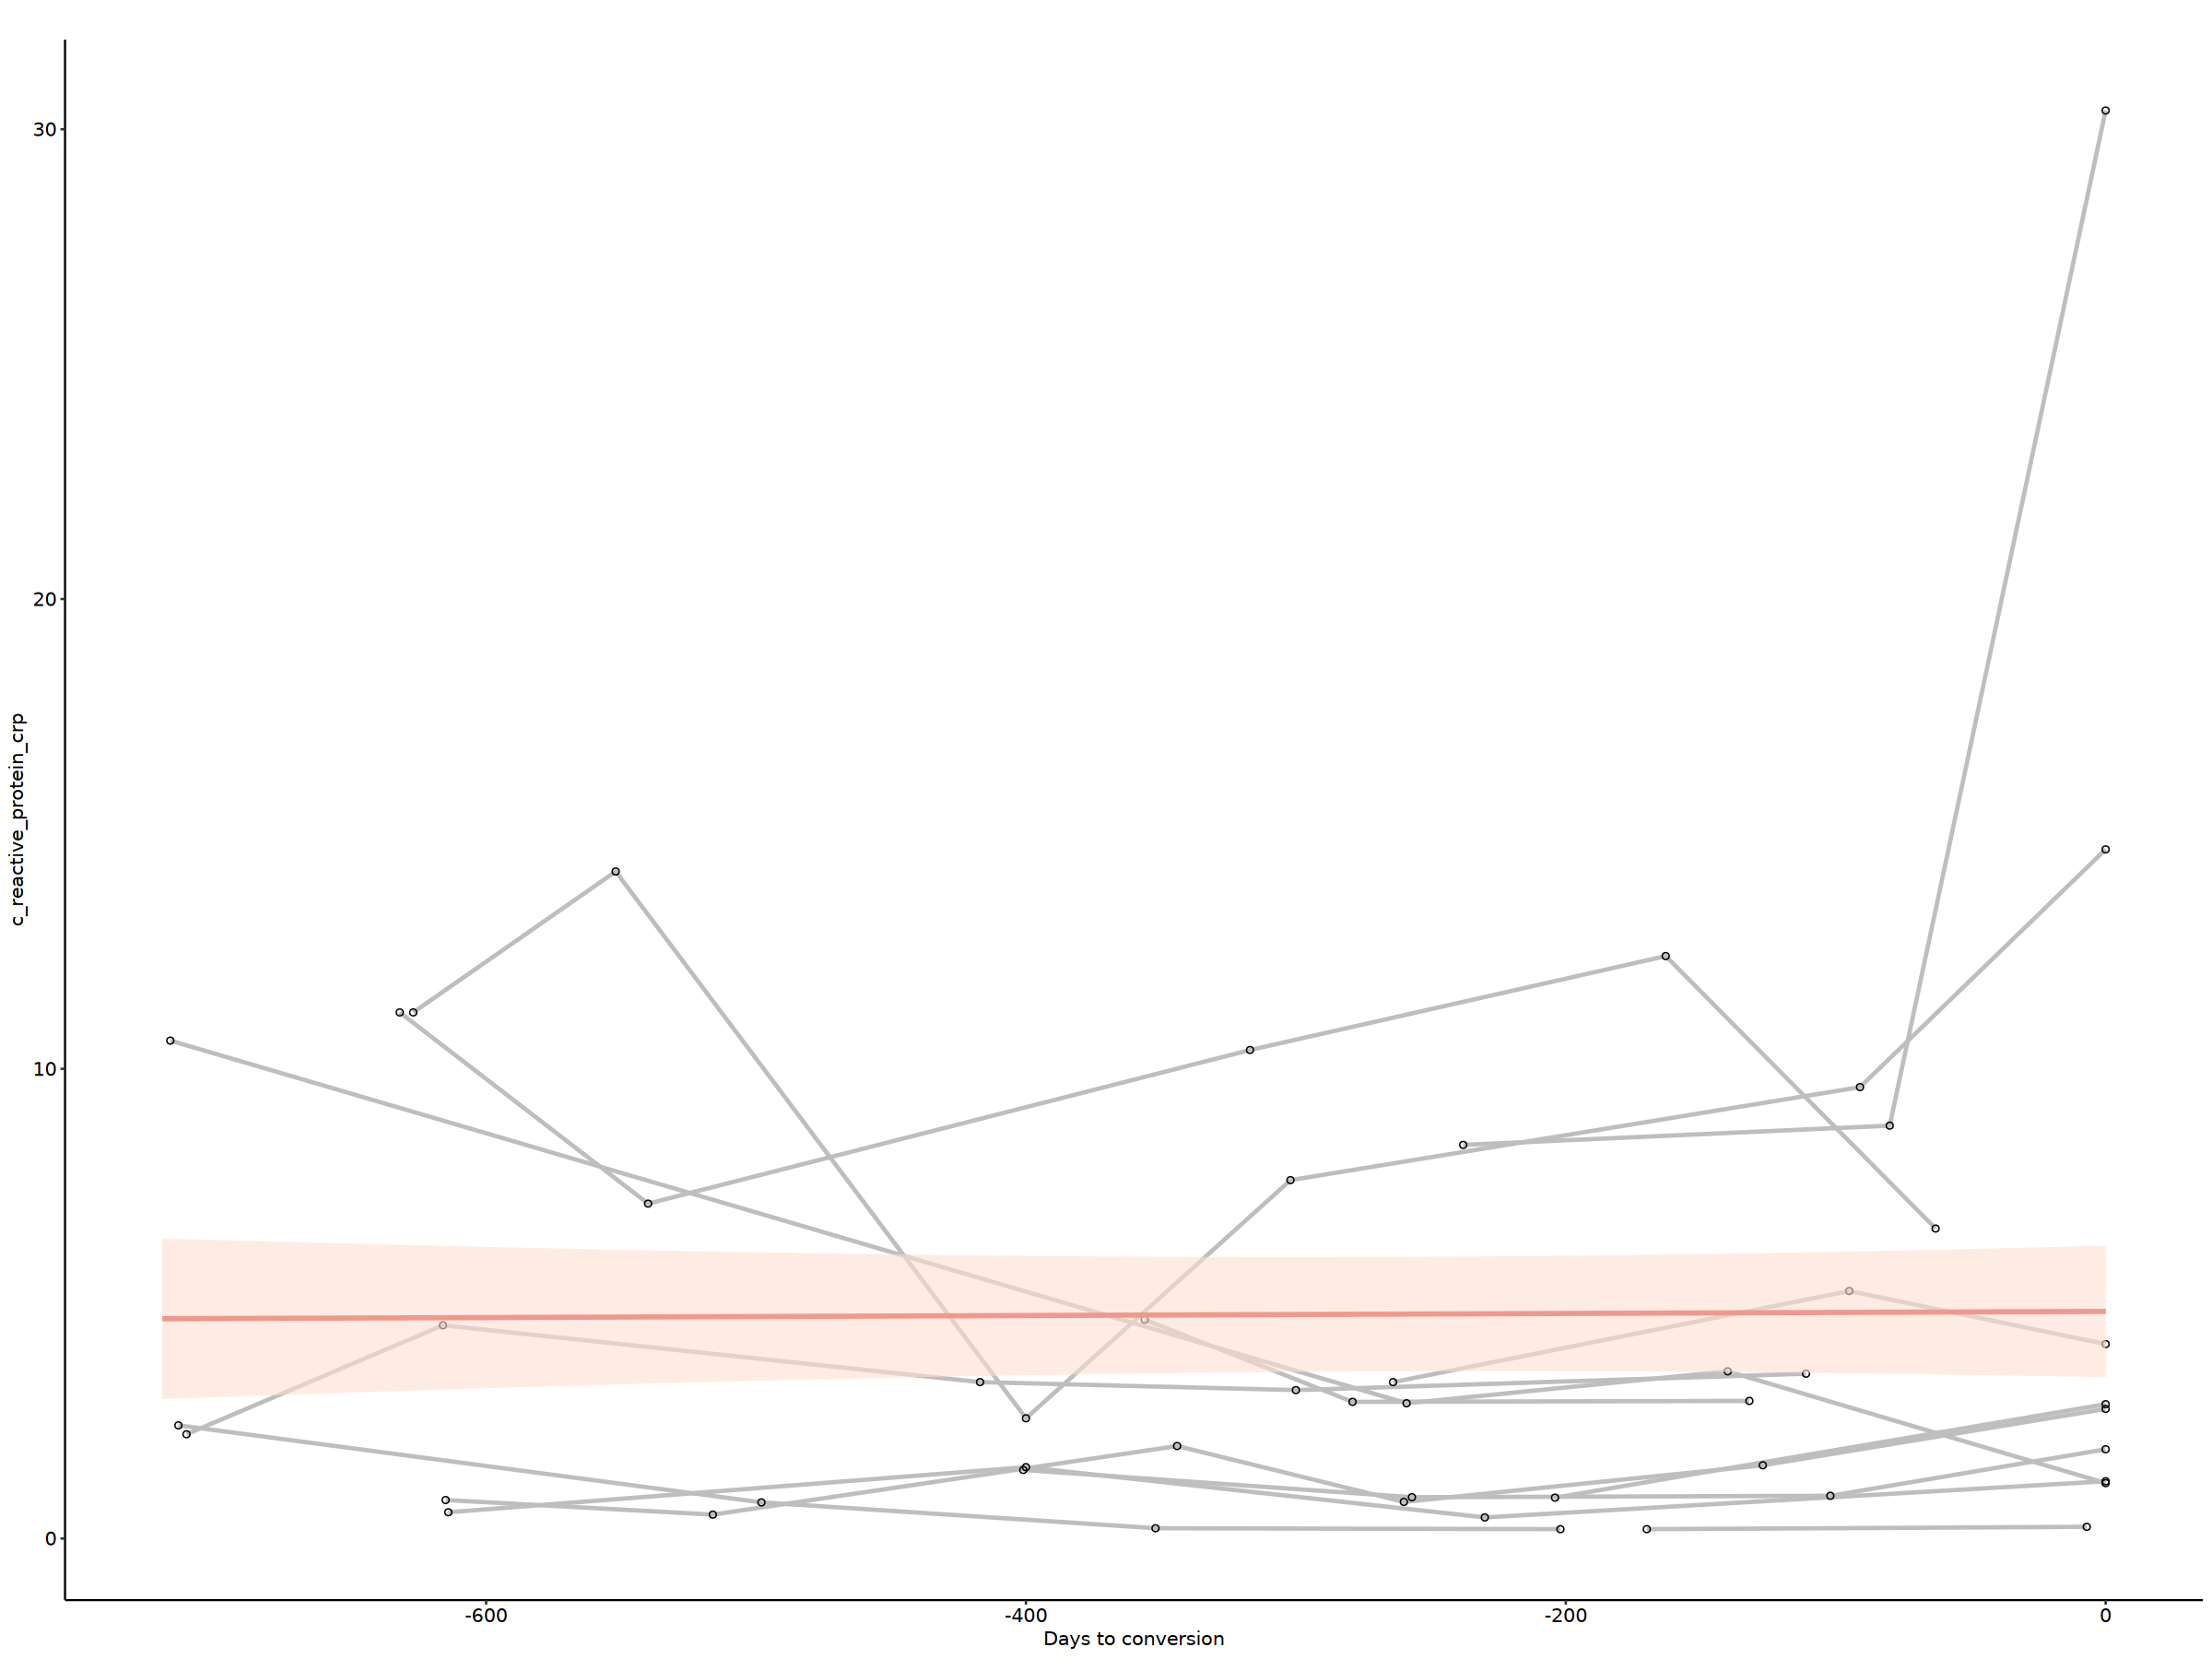

In [46]:
PlotPredLinePlot(lm_model, x_var = 'days_to_conversion', y_var = 'value', x_label = "Days to conversion", 
                 fig_path = fig_path, fig_name='ALTRA_AIM3_CRP_lineplot.pdf',
                 y_label = 'c_reactive_protein_crp', title = "")

In [47]:
# model platelet_count
formula_linear1 <- as.formula("value ~ age_conv + bmi_conv + days_to_conversion + 
    (1 | subject.subjectGuid)")
lab_sub_data = aim3_lab_long %>% filter(days_to_conversion>= (-750) & 
    subject.biologicalSex=='Female' & feature=='sed_rate_westergren_esr')
lm_model = lmer(formula_linear1, data=lab_sub_data)
summary(lm_model)

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: formula_linear1
   Data: lab_sub_data

REML criterion at convergence: 361.8

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-1.9820 -0.3228 -0.0570  0.3663  3.3667 

Random effects:
 Groups              Name        Variance Std.Dev.
 subject.subjectGuid (Intercept) 190.3    13.796  
 Residual                         37.8     6.148  
Number of obs: 50, groups:  subject.subjectGuid, 13

Fixed effects:
                     Estimate Std. Error         df t value Pr(>|t|)
(Intercept)        11.0076092 22.6044947  9.7347275   0.487    0.637
age_conv           -0.2793076  0.3095015  9.7301111  -0.902    0.389
bmi_conv            0.6562335  0.7347303  9.6897811   0.893    0.393
days_to_conversion  0.0004823  0.0048359 37.4064570   0.100    0.921

Correlation of Fixed Effects:
            (Intr) ag_cnv bm_cnv
age_conv    -0.432              
bmi_conv    -0.757 -0.236       
dys_t_cnvrs  0

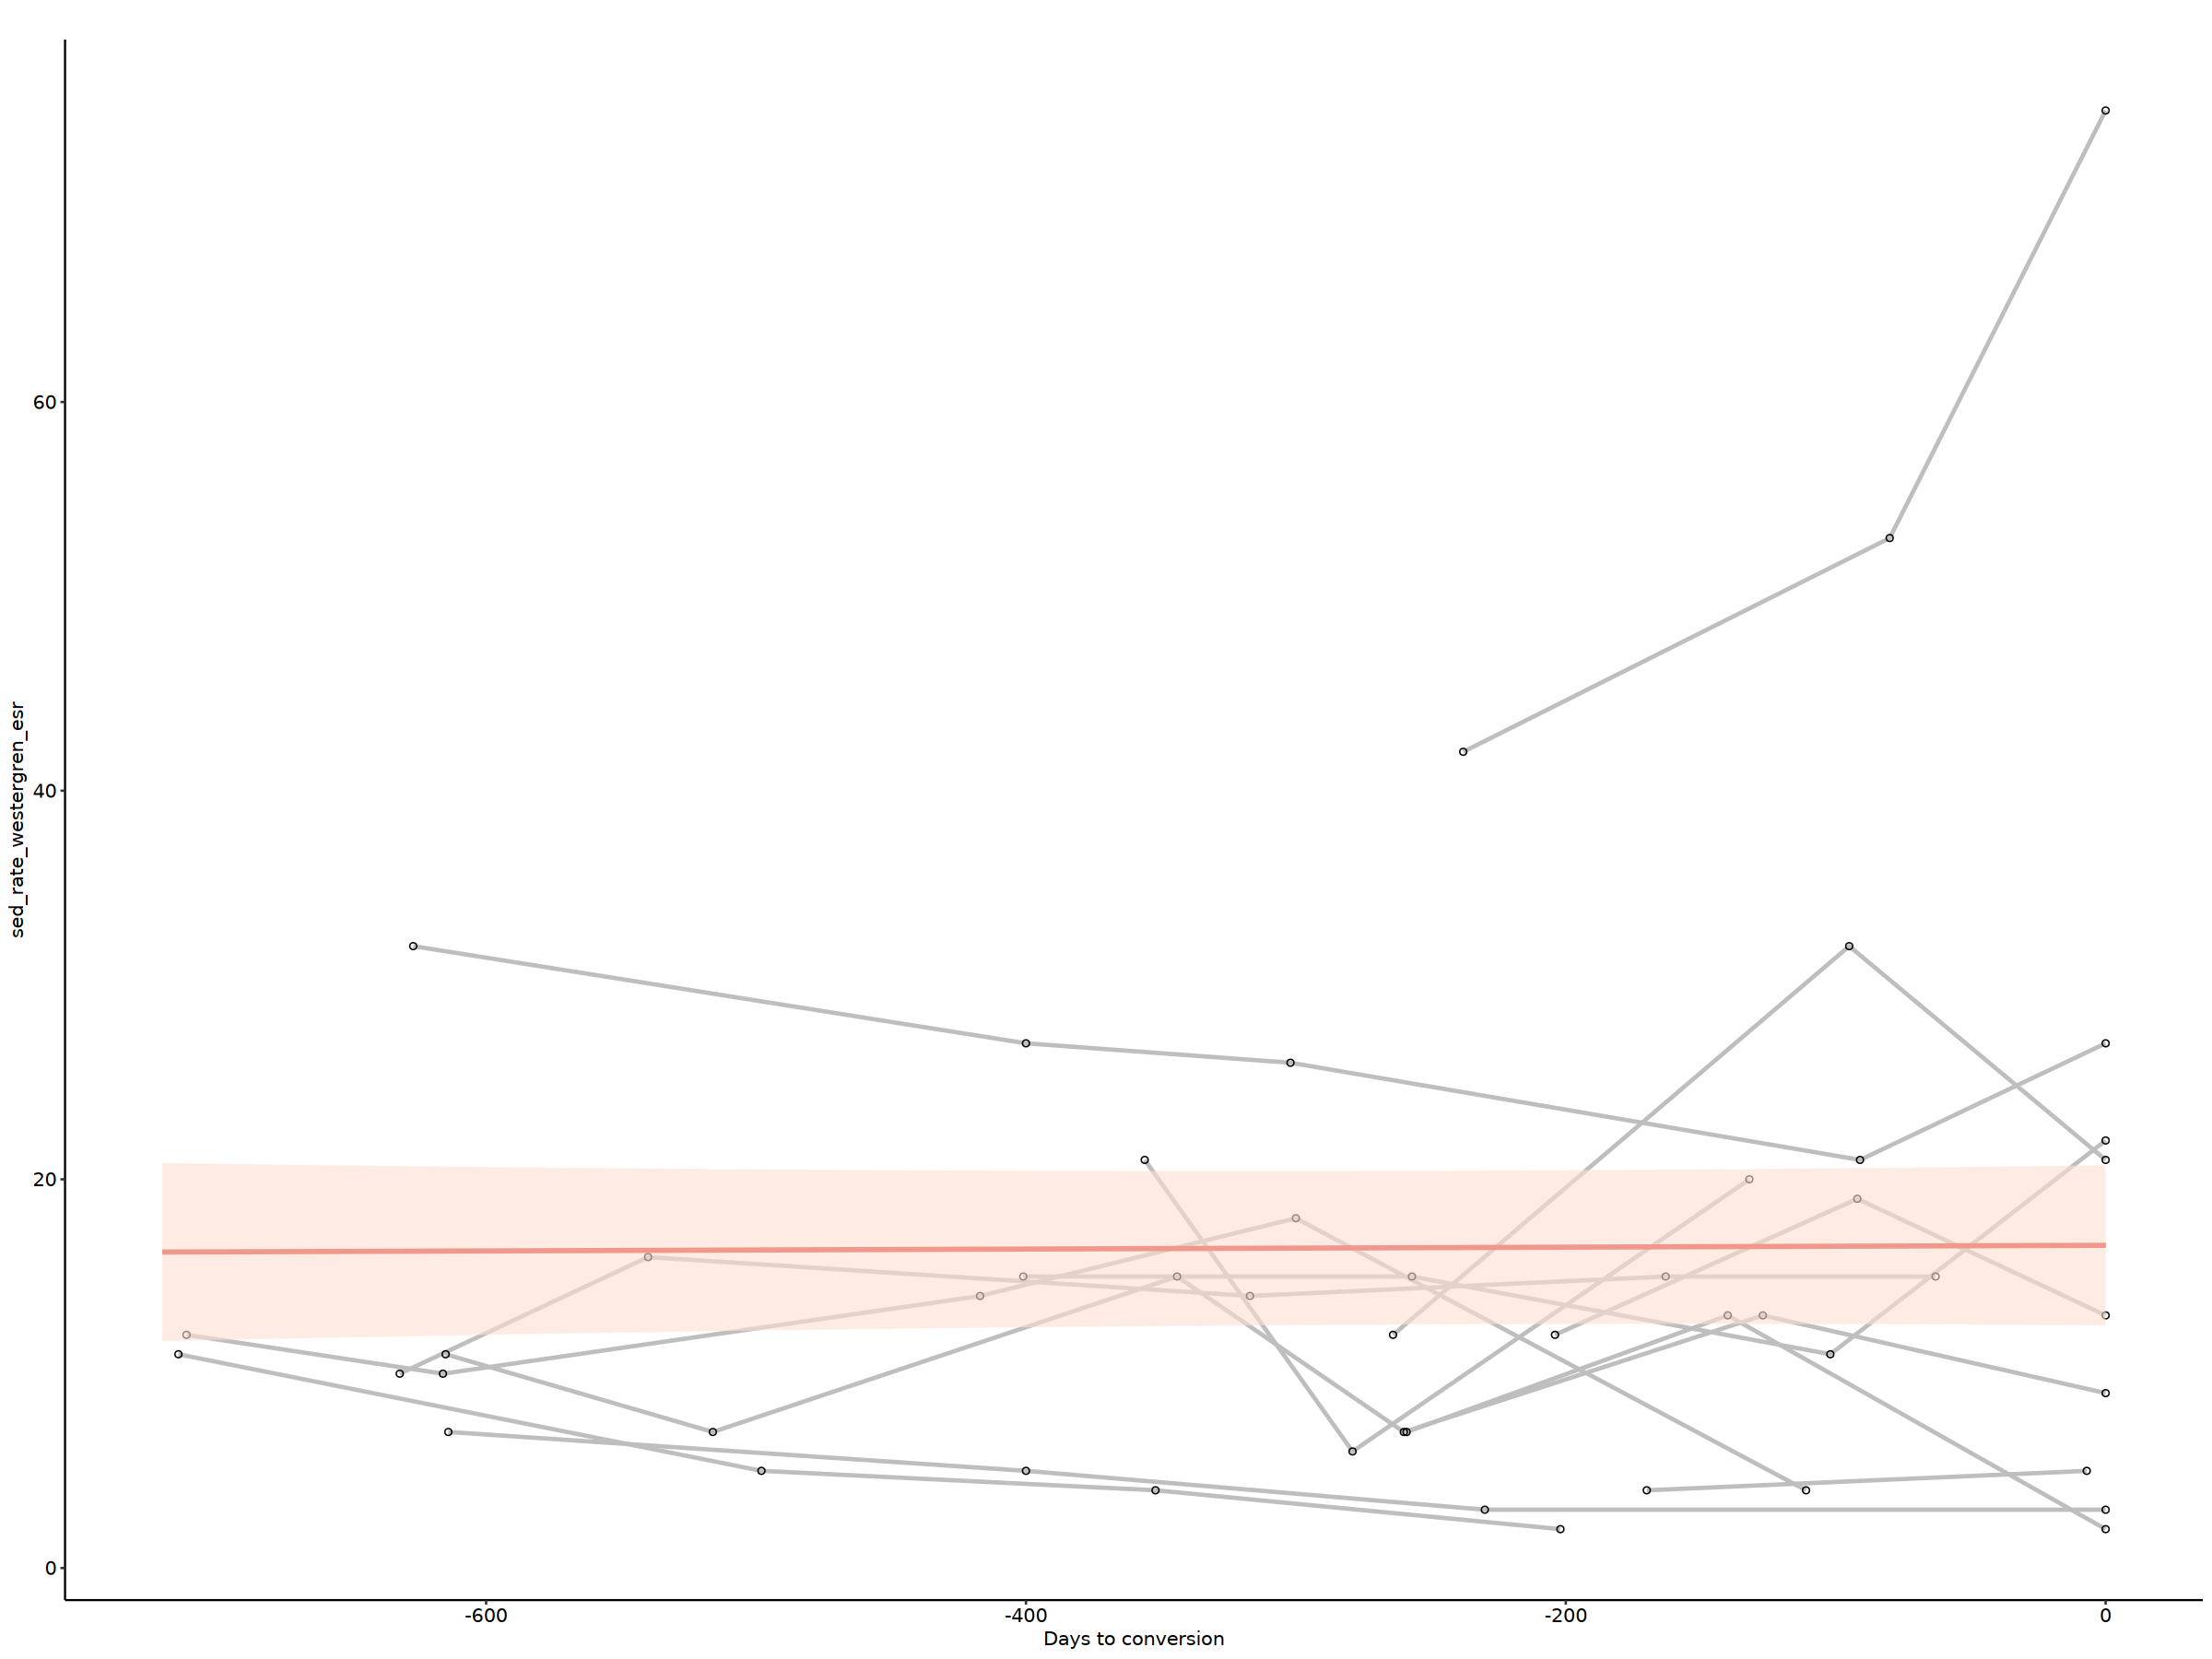

In [48]:
PlotPredLinePlot(lm_model, x_var = 'days_to_conversion', y_var = 'value', x_label = "Days to conversion", 
                 fig_path = fig_path, fig_name='ALTRA_AIM3_ESR_lineplot.pdf',
                 y_label = 'sed_rate_westergren_esr', title = "")